# Labeled Movement Data Analyses

This notebook unifies the active analyses from `Measures_and_plots_(labled_data).ipynb` and `Cycle_analysis_and_plots.ipynb`. The two source notebooks remain unchanged.

## 0. Notebook purpose and usage

Two datasets are analyzed: manually labeled free-practice segments from `free_practice_labled_frames.csv`, and positive (`prediction == 1`) repetitive-practice windows from the walk, jump, and climb prediction files. Sections cover repetitive trajectories, subject-level PCA, normalized integrated jerk (NIJ), run-based movement cycles, and an optional covariance analysis.

Run **Section 1** once after starting a kernel. Then any one analysis section can be run on its own; no analysis consumes another analysis's variables. Each section has its own parameters, load-or-build function, cache, tables, QC figures, and report figures. `FORCE_RECOMPUTE["analysis"] = True` rebuilds only that analysis. The default is cache reuse. Plot cells read saved analytical results, so plot styling can be changed without repeating PCA, NIJ, or cycle extraction.

Outputs are rooted at `paths.img_dir / "labeled_data_analysis"`. Every analysis has `cache`, `tables`, `figures/qc`, and `figures/report` directories. Versioned manifests record inputs, parameters, creation time, and a compatibility signature. Cache writes are atomic.

Scientific definitions are deliberately unchanged. The main technical corrections are documented where they occur: robust project-root validation, inclusive repetitive `end_frame`, exact `source_file` resolution, a dedicated smoothness output directory, minimal PCA caches, and compressed storage for cycle arrays.

## 1. Shared setup

In [ ]:
from __future__ import annotations

import hashlib
import json
import os
import pickle
import sys
import tempfile
import warnings
from datetime import datetime, timezone
from pathlib import Path
from types import SimpleNamespace

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.markers import MarkerStyle
from matplotlib.patches import Patch
from matplotlib.ticker import MaxNLocator
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d
from scipy.signal import find_peaks, savgol_filter
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


def find_project_root(start=None):
    """Return the nearest parent containing `.py/config_paths.py`."""
    start = Path.cwd().resolve() if start is None else Path(start).resolve()
    for candidate in (start, *start.parents):
        if (candidate / ".py" / "config_paths.py").is_file():
            return candidate
    raise FileNotFoundError("Could not locate a project root containing .py/config_paths.py")


PROJECT_ROOT = find_project_root()
MODULE_DIR = PROJECT_ROOT / ".py"
if str(MODULE_DIR) not in sys.path:
    sys.path.insert(0, str(MODULE_DIR))

# Prevent config_paths.py's module-level convenience instance from using a
# stale hostname-mapped checkout before this notebook can validate the root.
os.environ["GORILLA_TAG_PROJECT_ROOT"] = str(PROJECT_ROOT)

from config_paths import ProjectPaths, get_project_paths
from names_format import Current, Repetitive

configured_paths = get_project_paths()
if Path(configured_paths.root_dir).resolve() == PROJECT_ROOT:
    paths = configured_paths
else:
    warnings.warn(
        f"get_project_paths() returned {configured_paths.root_dir}, but this notebook is in "
        f"{PROJECT_ROOT}. Reusing config_paths.py's directory conventions under the verified root."
    )
    paths = ProjectPaths(
        root_dir=PROJECT_ROOT,
        data_dir=PROJECT_ROOT / "data",
        raw_data_dir=PROJECT_ROOT / "data" / "raw_data",
        processed_data_dir=PROJECT_ROOT / "data" / "processed_data",
        img_dir=PROJECT_ROOT / "img",
        bvh_dir=PROJECT_ROOT / "data" / "raw_bvh",
        hostname=configured_paths.hostname,
        repetitive_data_dir=PROJECT_ROOT / "repetitive_data",
        repetitive_raw_data_dir=PROJECT_ROOT / "repetitive_data" / "raw_data",
        repetitive_processed_data_dir=PROJECT_ROOT / "repetitive_data" / "processed_data",
        repetitive_bvh_dir=PROJECT_ROOT / "repetitive_data" / "raw_bvh",
    )

ANALYSIS_VERSION = "labeled_data_v2"
FREE_SUBJECTS = ["110", "111", "112", "113", "114", "115", "116"]
REPETITIVE_SUBJECTS = ["002", "004", "006", "007", "008", "009", "010", "011", "012", "013", "014", "015"]
SKILLS = ["walk", "jump", "climb"]
DAYS = [1, 3]
PARTS = ["s", "m", "e"]
HANDS = ["r_hand", "l_hand"]
DAY_PART_FOR_FINAL = {1: "s", 3: "e"}
FS_HZ = 60.0
DT = 1.0 / FS_HZ
RANDOM_SEED = 20260818

FORCE_RECOMPUTE = {
    "trajectories": False,
    "pca": False,
    "smoothness": False,
    "cycles": False,
    "covariance": False,
}
RUN_OPTIONAL_COVARIANCE = False

SKILL_LABELS = {"walk": "Walking", "jump": "Jumping", "climb": "Climbing"}
SKILL_COLORS = {"walk": "#1b9e77", "jump": "#d95f02", "climb": "#7570b3"}
HAND_COLORS = {"r_hand": "#D55E00", "l_hand": "#6A5ACD"}
HAND_LABELS = {"r_hand": "Right hand", "l_hand": "Left hand"}
DAY_LABELS = {1: "Day 1", 3: "Day 3"}
PART_LABELS = {"s": "start", "m": "middle", "e": "end"}
DAY_MARKERS = {1: "o", 3: "s"}
HAND_MARKERS = {"r_hand": "o", "l_hand": "^"}
DAY_LINESTYLES = {1: "--", 3: "-"}
GROUP_MARKERS = {"free": "o", "repetitive": "s"}
GROUP_LABELS = {"free": "Free practice", "repetitive": "Repetitive practice"}

plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 300, "font.size": 11,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25,
})

FREE_LABELS_PATH = paths.data_dir / "free_practice_labled_frames.csv"
REPETITIVE_WINDOW_FILES = {
    skill: paths.repetitive_data_dir / f"window_predictions_{skill}.csv"
    for skill in SKILLS
}
FREE_PROCESSED_DIR = paths.processed_data_dir
REPETITIVE_PROCESSED_DIR = paths.repetitive_processed_data_dir

ANALYSIS_ROOT = paths.img_dir / "labeled_data_analysis"
OUTPUT_DIRS = {}
for analysis in ["trajectories", "pca", "smoothness", "cycles", "covariance"]:
    base = ANALYSIS_ROOT / analysis
    OUTPUT_DIRS[analysis] = {
        "root": base,
        "cache": base / "cache",
        "tables": base / "tables",
        "qc": base / "figures" / "qc",
        "report": base / "figures" / "report",
    }
for mapping in OUTPUT_DIRS.values():
    for directory in mapping.values():
        directory.mkdir(parents=True, exist_ok=True)
(ANALYSIS_ROOT / "tables").mkdir(parents=True, exist_ok=True)

POSITION_POINTS = [
    "root", "head", "neck_1", "neck_2",
    "torso_1", "torso_2", "torso_3", "torso_4", "torso_5", "torso_6", "torso_7",
    "l_shoulder", "r_shoulder", "l_up_arm", "r_up_arm", "l_low_arm", "r_low_arm",
    "l_hand", "r_hand",
]
POSITION_FEATURES = [f"{point}.{axis}" for point in POSITION_POINTS for axis in "xyz"]
SMOOTHNESS_POINTS = [
    "root", "head", "l_shoulder", "r_shoulder", "l_up_arm", "r_up_arm",
    "l_low_arm", "r_low_arm", "l_hand", "r_hand",
    "torso_1", "torso_2", "torso_3", "torso_4", "torso_5", "torso_6", "torso_7",
]

print(f"Verified project root: {PROJECT_ROOT}")
print(f"Figures/tables/caches root: {ANALYSIS_ROOT}")

Detected hostname: Opher-Lab-8a
Using root directory: D:\noamgonen\GitHub\gorilla_tag_
Verified project root: D:\noamgonen\GitHub\gorilla_tag_
Figures/tables/caches root: D:\noamgonen\GitHub\gorilla_tag_\img\labeled_data_analysis


### Shared subject colors

Colors are assigned once from the full configured subject lists. The canonical key is `group:subject`, so equal numeric IDs in different groups cannot collide. Missing observations never change another subject's color. Subject color represents identity in every subject-level figure; marker, fill, or line style represents hand/day/condition.

,canonical_subject,group,subject,color,palette_index
0,free:110,free,110,#1f77b4,0
1,free:111,free,111,#aec7e8,1
2,free:112,free,112,#ff7f0e,2
3,free:113,free,113,#ffbb78,3
4,free:114,free,114,#2ca02c,4
5,free:115,free,115,#98df8a,5
6,free:116,free,116,#d62728,6
7,repetitive:002,repetitive,002,#ff9896,7
8,repetitive:004,repetitive,004,#9467bd,8
9,repetitive:006,repetitive,006,#c5b0d5,9


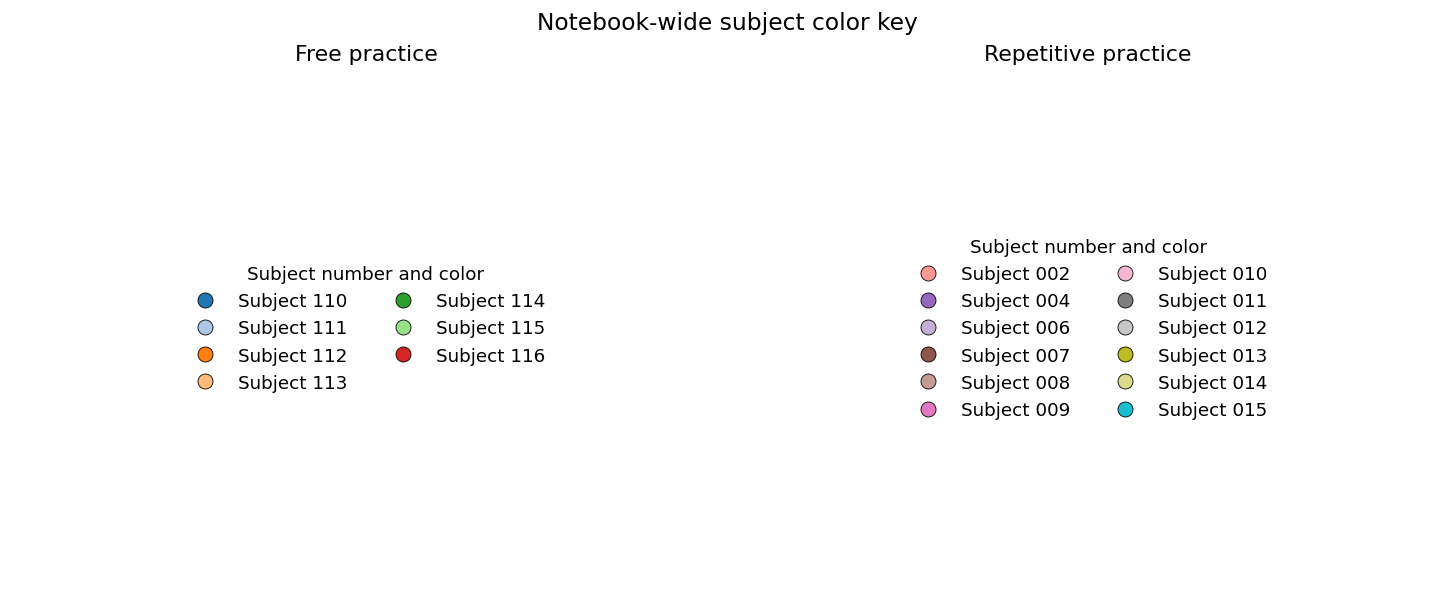

Saved: D:\noamgonen\GitHub\gorilla_tag_\img\labeled_data_analysis\tables\labeled_data_v2_subject_colors.csv


In [3]:
def build_subject_color_table():
    configured = [("free", s) for s in FREE_SUBJECTS] + [("repetitive", s) for s in REPETITIVE_SUBJECTS]
    palette = list(plt.get_cmap("tab20").colors)
    if len(configured) > len(palette):
        palette = [plt.get_cmap("turbo")(x) for x in np.linspace(0.03, 0.97, len(configured))]
    rows = []
    for index, ((group, subject), rgba) in enumerate(zip(configured, palette)):
        rows.append({
            "canonical_subject": f"{group}:{subject}", "group": group, "subject": subject,
            "color": plt.matplotlib.colors.to_hex(rgba), "palette_index": index,
        })
    return pd.DataFrame(rows)


SUBJECT_COLOR_TABLE = build_subject_color_table()
SUBJECT_COLOR_MAP = SUBJECT_COLOR_TABLE.set_index("canonical_subject")["color"].to_dict()

# These colors are reserved for aggregate summaries, conditions, QC categories,
# and reference lines. Subject colors must remain unique and disjoint from them.
RESERVED_NON_SUBJECT_COLORS = {
    plt.matplotlib.colors.to_hex(color)
    for color in [
        *SKILL_COLORS.values(), *HAND_COLORS.values(),
        "#4daf4a", "#e41a1c", "#4C78A8", "#F58518", "#E45756",
        "#B279A2", "#9D755D", "#FF9DA6", "black", "0.25", "0.6", "0.65",
    ]
}


def canonical_subject(subject, group="repetitive"):
    """Return the stable `(group, subject)` display key used by the color system."""
    subject = str(subject)
    if group == "repetitive":
        subject = f"{int(float(subject)):03d}"
    elif group == "free":
        subject = str(int(float(subject)))
    return f"{group}:{subject}"


def get_subject_color(subject, group="repetitive"):
    """Return the deterministic color for one configured subject."""
    key = canonical_subject(subject, group)
    if key not in SUBJECT_COLOR_MAP:
        raise KeyError(f"Subject is not configured: {key}")
    return SUBJECT_COLOR_MAP[key]


def plot_subject_color_legend():
    """Display the one notebook-wide subject-color key, separated by group."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), constrained_layout=True)
    for ax, group in zip(axes, ["free", "repetitive"]):
        group_colors = SUBJECT_COLOR_TABLE[SUBJECT_COLOR_TABLE["group"] == group]
        handles = [
            Line2D(
                [0], [0], marker="o", linestyle="None", markersize=9,
                markerfacecolor=row.color, markeredgecolor="black", markeredgewidth=0.5,
                label=f"Subject {row.subject}",
            )
            for row in group_colors.itertuples()
        ]
        ax.axis("off")
        ax.set_title(GROUP_LABELS[group], pad=12)
        ax.legend(handles=handles, loc="center", ncol=2, frameon=False, title="Subject number and color")
    fig.suptitle("Notebook-wide subject color key", fontsize=14)
    return fig


subject_color_path = ANALYSIS_ROOT / "tables" / f"{ANALYSIS_VERSION}_subject_colors.csv"
SUBJECT_COLOR_TABLE.to_csv(subject_color_path, index=False)
assert SUBJECT_COLOR_TABLE["canonical_subject"].is_unique
assert SUBJECT_COLOR_TABLE["color"].is_unique
assert set(SUBJECT_COLOR_TABLE["color"]).isdisjoint(RESERVED_NON_SUBJECT_COLORS)
assert SUBJECT_COLOR_TABLE.groupby(["group", "subject"])["color"].nunique().eq(1).all()
_before = SUBJECT_COLOR_MAP.copy()
_ = SUBJECT_COLOR_TABLE[SUBJECT_COLOR_TABLE["subject"] != "002"]
assert SUBJECT_COLOR_MAP == _before
for _subject in REPETITIVE_SUBJECTS[:2]:
    for _skill in SKILLS[:2]:
        for _day in DAYS:
            assert get_subject_color(_subject) == SUBJECT_COLOR_MAP[f"repetitive:{_subject}"]
display(SUBJECT_COLOR_TABLE)
subject_color_legend_fig = plot_subject_color_legend()
plt.show()
print(f"Saved: {subject_color_path}")

### Shared cache, path, validation, and data-loading helpers

In [4]:
def normalize_skill_label(label):
    return str(label).strip().lower()


def normalize_repetitive_subject(value):
    return f"{int(float(value)):03d}"


def normalize_free_subject(value):
    return str(int(float(value)))


def normalize_part_code(value):
    value = str(value).strip().lower()
    base = value.split(".", 1)[0]
    return {"start": "s", "middle": "m", "end": "e"}.get(base, base)


def parse_free_session(session):
    if pd.isna(session):
        raise ValueError("session is missing")
    value = str(session).strip()
    if "." in value:
        base, part = value.split(".", 1)
        return str(int(float(base))), (part if part and part != "0" else None)
    return str(int(float(value))), None


def free_pos_path(row):
    session, part = parse_free_session(row["session"])
    name = Current.csv_name(
        normalize_free_subject(row["subject"]), str(int(row["day"])), session,
        kind="pos", aligned=True, part=part, validate=False,
    )
    return FREE_PROCESSED_DIR / name


def repetitive_pos_path(row):
    source_file = row.get("source_file")
    if pd.isna(source_file) or not str(source_file).strip():
        raise ValueError("Missing source_file; exact repetitive file resolution is required")
    return REPETITIVE_PROCESSED_DIR / f"{str(source_file).strip()}_pos_aligned.csv"


def segment_path(group, row):
    if group == "free":
        return free_pos_path(row)
    if group == "repetitive":
        return repetitive_pos_path(row)
    raise ValueError(f"Unknown group: {group}")


def load_position_file(path, file_cache=None):
    path = Path(path)
    if file_cache is not None:
        if path not in file_cache:
            file_cache[path] = pd.read_csv(path, low_memory=False)
        return file_cache[path]
    return pd.read_csv(path, low_memory=False)


def load_segment(group, row, columns=None, file_cache=None):
    """Load one labeled segment; returns `(data, diagnostics)` with an exclusive end index."""
    path = segment_path(group, row)
    diag = {"group": group, "subject": row.get("subject_str", row.get("subject")),
            "skill": row.get("skill"), "day": row.get("day"), "file": path.name, "error": ""}
    if not path.exists():
        diag["error"] = "missing_file"
        return None, diag
    frame_df = load_position_file(path, file_cache=file_cache)
    requested_start, requested_end = int(row["start"]), int(row["end"])
    start, end = max(0, requested_start), min(len(frame_df), requested_end)
    diag.update({"requested_frames": requested_end - requested_start, "loaded_frames": max(0, end - start),
                 "truncated": bool(start != requested_start or end != requested_end)})
    if end <= start:
        diag["error"] = "invalid_or_empty_window"
        return None, diag
    segment = frame_df.iloc[start:end].copy()
    if columns is not None:
        missing = [column for column in columns if column not in segment.columns]
        if missing:
            diag["error"] = "missing_columns:" + ",".join(missing[:8])
            return None, diag
        segment = segment[list(columns)].copy()
    return segment.reset_index(drop=True), diag


def file_fingerprint(path):
    path = Path(path)
    if not path.exists():
        return {"path": str(path), "exists": False}
    stat = path.stat()
    return {"path": str(path.resolve()), "exists": True, "size": stat.st_size, "mtime_ns": stat.st_mtime_ns}


def cache_signature(analysis, parameters, inputs):
    payload = {"analysis": analysis, "version": ANALYSIS_VERSION, "parameters": parameters,
               "inputs": [file_fingerprint(path) for path in inputs]}
    encoded = json.dumps(payload, sort_keys=True, default=str).encode("utf-8")
    return hashlib.sha256(encoded).hexdigest(), payload


def atomic_pickle_dump(value, path):
    path = Path(path); path.parent.mkdir(parents=True, exist_ok=True)
    with tempfile.NamedTemporaryFile("wb", delete=False, dir=path.parent, suffix=".tmp") as handle:
        pickle.dump(value, handle, protocol=pickle.HIGHEST_PROTOCOL)
        temp_path = Path(handle.name)
    os.replace(temp_path, path)


def atomic_npz(path, **arrays):
    path = Path(path); path.parent.mkdir(parents=True, exist_ok=True)
    with tempfile.NamedTemporaryFile("wb", delete=False, dir=path.parent, suffix=".tmp") as handle:
        np.savez_compressed(handle, **arrays)
        temp_path = Path(handle.name)
    os.replace(temp_path, path)


def atomic_json(value, path):
    path = Path(path); path.parent.mkdir(parents=True, exist_ok=True)
    with tempfile.NamedTemporaryFile("w", delete=False, dir=path.parent, suffix=".tmp", encoding="utf-8") as handle:
        json.dump(value, handle, indent=2, sort_keys=True, default=str)
        temp_path = Path(handle.name)
    os.replace(temp_path, path)


def cache_is_valid(manifest_path, expected_signature):
    try:
        manifest = json.loads(Path(manifest_path).read_text(encoding="utf-8"))
        return manifest.get("signature") == expected_signature
    except (FileNotFoundError, json.JSONDecodeError, OSError):
        return False


def write_manifest(path, analysis, signature, payload, outputs):
    atomic_json({"analysis": analysis, "analysis_version": ANALYSIS_VERSION, "signature": signature,
                 "created_utc": datetime.now(timezone.utc).isoformat(), "compatibility": payload,
                 "outputs": [str(Path(item)) for item in outputs]}, path)


def save_figure(fig, directory, stem, pdf=True):
    directory = Path(directory); directory.mkdir(parents=True, exist_ok=True)
    png = directory / f"{ANALYSIS_VERSION}_{stem}.png"
    fig.savefig(png, dpi=300, bbox_inches="tight")
    outputs = [png]
    if pdf:
        pdf_path = directory / f"{ANALYSIS_VERSION}_{stem}.pdf"
        fig.savefig(pdf_path, bbox_inches="tight")
        outputs.append(pdf_path)
    return outputs


def equal_limits(*series, padding_fraction=0.08, positive=False, log_scale=False):
    """Return shared limits, optionally padding in log10 space for positive log axes."""
    values = np.concatenate([np.asarray(value, dtype=float).ravel() for value in series])
    values = values[np.isfinite(values)]
    if positive or log_scale:
        values = values[values > 0]
    if not len(values):
        return None
    if log_scale:
        log_values = np.log10(values)
        lo, hi = float(log_values.min()), float(log_values.max())
        pad = padding_fraction * (hi - lo if hi > lo else 1.0)
        return 10 ** (lo - pad), 10 ** (hi + pad)
    lo, hi = float(values.min()), float(values.max())
    pad = padding_fraction * (hi - lo if hi > lo else max(abs(hi), 1.0))
    return lo - pad, hi + pad


def referenced_position_paths(label_df, group):
    """Return unique aligned-position paths referenced by a label table."""
    return sorted({segment_path(group, row) for _, row in label_df.iterrows()}, key=str)


def bridge_boolean_mask_gaps(mask, max_gap_frames=15):
    """Fill false gaps no longer than `max_gap_frames` between true runs."""
    mask = np.asarray(mask, dtype=bool).copy()
    if max_gap_frames <= 0 or not mask.any():
        return mask
    padded = np.r_[False, mask, False]
    changes = np.flatnonzero(padded[1:] != padded[:-1])
    starts, ends = changes[::2], changes[1::2]
    for left_end, right_start in zip(ends[:-1], starts[1:]):
        if 0 < right_start - left_end <= max_gap_frames:
            mask[left_end:right_start] = True
    return mask


def mask_to_runs(mask, min_run_frames=1):
    """Convert a boolean mask to exclusive-end runs meeting a minimum length."""
    mask = np.asarray(mask, dtype=bool)
    if not mask.any():
        return []
    padded = np.r_[False, mask, False]
    changes = np.flatnonzero(padded[1:] != padded[:-1])
    return [(int(a), int(b)) for a, b in zip(changes[::2], changes[1::2]) if b - a >= min_run_frames]


def build_runs_from_positive_windows(rep_df, parameters):
    """Union overlapping positive windows by exact source file, bridge short gaps, and return run/QC tables."""
    selected = rep_df.copy()
    wanted = {(int(day), normalize_part_code(part)) for day, part in parameters["day_part_map"].items()}
    selected = selected[selected.apply(lambda row: (int(row["day"]), normalize_part_code(row["part"])) in wanted, axis=1)]
    if parameters.get("subjects"):
        selected = selected[selected["subject_str"].isin([normalize_repetitive_subject(x) for x in parameters["subjects"]])]
    selected = selected[selected["skill"].isin(parameters["skills"])]
    run_rows, qc_rows, skipped = [], [], []
    file_cache = {}
    for keys, group in selected.groupby(["subject_str", "day", "part", "skill", "source_file"], dropna=False):
        subject, day, part, skill, source_file = keys
        path = repetitive_pos_path(group.iloc[0])
        base = {"subject": subject, "day": int(day), "part": normalize_part_code(part), "skill": skill,
                "source_file": source_file, "file": path.name}
        if not path.exists():
            qc_rows.append({**base, "file_exists": False, "n_positive_windows": len(group)})
            skipped.append({**base, "error": "missing_file"})
            continue
        position_df = load_position_file(path, file_cache)
        n_frames = len(position_df)
        mask = np.zeros(n_frames, dtype=bool)
        truncated = invalid = 0
        for row in group.itertuples():
            start, end = max(0, int(row.start)), min(n_frames, int(row.end))
            truncated += int(start != int(row.start) or end != int(row.end))
            if end <= start:
                invalid += 1
            else:
                mask[start:end] = True
        raw_runs = mask_to_runs(mask)
        bridged = bridge_boolean_mask_gaps(mask, parameters["max_gap_to_bridge_frames"])
        min_frames = round(parameters["min_run_duration_sec"] * FS_HZ)
        runs = mask_to_runs(bridged, min_frames)
        for run_id, (start, end) in enumerate(runs, 1):
            run_rows.append({**base, "path": str(path), "movement_run_id": run_id, "run_start": start,
                             "run_end": end, "run_n_frames": end - start, "run_duration_sec": (end - start) / FS_HZ})
        qc_rows.append({**base, "file_exists": True, "n_file_frames": n_frames,
                        "n_positive_windows": len(group), "n_positive_frames_union": int(mask.sum()),
                        "n_raw_runs": len(raw_runs), "n_movement_runs": len(runs),
                        "n_truncated_windows": truncated, "n_invalid_windows": invalid,
                        "overlapping_positive_windows": count_overlapping_windows(group),
                        "max_gap_to_bridge_frames": parameters["max_gap_to_bridge_frames"], "min_run_frames": min_frames})
    run_columns = ["subject", "day", "part", "skill", "source_file", "file", "path", "movement_run_id",
                   "run_start", "run_end", "run_n_frames", "run_duration_sec"]
    runs_df = pd.DataFrame(run_rows, columns=run_columns)
    if len(runs_df):
        runs_df = runs_df.sort_values(["subject", "skill", "day", "part", "file", "movement_run_id"]).reset_index(drop=True)
    return runs_df, pd.DataFrame(qc_rows), pd.DataFrame(skipped)

### Load label tables and general input-data QC

In [5]:
def load_free_labeled_frames():
    df = pd.read_csv(FREE_LABELS_PATH)
    df = df.loc[:, ~df.columns.str.startswith("Unnamed")].copy()
    df["subject_str"] = df["subject"].map(normalize_free_subject)
    df["skill"] = df["label"].map(normalize_skill_label)
    df["day"] = df["day"].astype(int)
    return df[df["subject_str"].isin(FREE_SUBJECTS) & df["skill"].isin(SKILLS) & df["day"].isin(DAYS)].reset_index(drop=True)


def load_repetitive_window_predictions(window_files=None):
    """Load only positive windows; preserve leading-zero subject IDs and inclusive `end_frame`."""
    window_files = REPETITIVE_WINDOW_FILES if window_files is None else window_files
    task_to_skill = {"w": "walk", "j": "jump", "c": "climb"}
    frames = []
    required = {"subject", "day", "session_part", "window_id", "start_frame", "end_frame", "prediction", "source_file"}
    for file_skill, path in window_files.items():
        df = pd.read_csv(path)
        df = df.loc[:, ~df.columns.str.startswith("Unnamed")].copy()
        missing = sorted(required - set(df.columns))
        if missing:
            raise ValueError(f"{path.name} missing columns: {missing}")
        if df["source_file"].isna().any() or df["source_file"].astype(str).str.strip().eq("").any():
            raise ValueError(f"{path.name} contains missing source_file values")
        df["skill"] = normalize_skill_label(file_skill)
        if "task" in df:
            df["skill"] = df["task"].astype(str).str.strip().str.lower().map(task_to_skill).fillna(df["skill"])
        df = df[df["prediction"].astype(int).eq(1)].copy()
        df["subject_str"] = df["subject"].map(normalize_repetitive_subject)
        df["day"] = df["day"].astype(int)
        df["part"] = df["session_part"].map(normalize_part_code)
        df["segment"] = df["window_id"].astype(int)
        df["start"] = df["start_frame"].astype(int)
        df["end"] = df["end_frame"].astype(int) + 1
        df["length"] = df["end"] - df["start"]
        frames.append(df)
    result = pd.concat(frames, ignore_index=True)
    result = result[result["subject_str"].isin(REPETITIVE_SUBJECTS) & result["skill"].isin(SKILLS) & result["day"].isin(DAYS)].copy()
    assert result["prediction"].astype(int).eq(1).all(), "Only prediction == 1 is allowed"
    assert result["end"].eq(result["end_frame"].astype(int) + 1).all(), "end_frame must be inclusive"
    assert result["subject_str"].str.len().eq(3).all(), "Leading zeros were not preserved"
    assert all(repetitive_pos_path(row).name == f"{str(row['source_file']).strip()}_pos_aligned.csv" for _, row in result.iterrows())
    return result.reset_index(drop=True)


free_labeled_df = load_free_labeled_frames()
repetitive_labeled_df = load_repetitive_window_predictions()


def count_overlapping_windows(group):
    ordered = group.sort_values(["start", "end"])
    max_end, overlaps = -1, 0
    for row in ordered.itertuples():
        if int(row.start) < max_end:
            overlaps += 1
        max_end = max(max_end, int(row.end))
    return overlaps


def build_general_input_qc(free_df, repetitive_df):
    rows = []
    free_group_cols = ["subject_str", "skill", "day", "session"]
    for keys, group in free_df.groupby(free_group_cols, dropna=False):
        paths_here = [free_pos_path(row) for _, row in group.iterrows()]
        rows.append({"group": "free", "subject": keys[0], "skill": keys[1], "day": keys[2], "part_session": keys[3],
                     "n_positive_windows_or_segments": len(group), "total_referenced_frames": int((group["end"] - group["start"]).sum()),
                     "n_unique_source_files": len(set(paths_here)), "missing_source_files": sum(not p.exists() for p in set(paths_here)),
                     "invalid_or_empty_windows": int((group["end"] <= group["start"]).sum()), "truncated_windows": np.nan,
                     "duplicate_window_identifiers": int(group.duplicated(["segment"]).sum()), "overlapping_positive_windows": np.nan})
    rep_group_cols = ["subject_str", "skill", "day", "part"]
    for keys, group in repetitive_df.groupby(rep_group_cols, dropna=False):
        paths_here = [repetitive_pos_path(row) for _, row in group.iterrows()]
        duplicate_cols = ["source_file", "window_id"]
        overlaps = sum(count_overlapping_windows(file_group) for _, file_group in group.groupby("source_file"))
        rows.append({"group": "repetitive", "subject": keys[0], "skill": keys[1], "day": keys[2], "part_session": keys[3],
                     "n_positive_windows_or_segments": len(group), "total_referenced_frames": int(group["length"].sum()),
                     "n_unique_source_files": group["source_file"].nunique(), "missing_source_files": sum(not p.exists() for p in set(paths_here)),
                     "invalid_or_empty_windows": int((group["end"] <= group["start"]).sum()), "truncated_windows": np.nan,
                     "duplicate_window_identifiers": int(group.duplicated(duplicate_cols).sum()),
                     "overlapping_positive_windows": int(overlaps)})
    return pd.DataFrame(rows)


general_input_qc_df = build_general_input_qc(free_labeled_df, repetitive_labeled_df)
general_qc_path = ANALYSIS_ROOT / "tables" / f"{ANALYSIS_VERSION}_general_input_qc.csv"
general_input_qc_df.to_csv(general_qc_path, index=False)
display(general_input_qc_df)
print(f"Free labeled segments: {len(free_labeled_df):,}")
print(f"Positive repetitive windows: {len(repetitive_labeled_df):,}")
print("No X-based exclusion or removed-segments CSV is used.")
print(f"Saved: {general_qc_path}")

,group,subject,skill,day,part_session,n_positive_windows_or_segments,total_referenced_frames,n_unique_source_files,missing_source_files,invalid_or_empty_windows,truncated_windows,duplicate_window_identifiers,overlapping_positive_windows
0,free,110,walk,1,1.1,9,8993,1,0,0,NaN,0,NaN
1,free,110,walk,1,1.2,5,6881,1,0,0,NaN,0,NaN
2,free,110,walk,3,3.0,11,7045,1,0,1,NaN,0,NaN
3,free,111,jump,3,3.0,10,1867,1,0,0,NaN,0,NaN
4,free,111,walk,1,1.1,3,3622,1,0,0,NaN,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
234,repetitive,015,walk,1,m,76,9120,1,0,0,NaN,0,64.0
235,repetitive,015,walk,1,s,22,2640,1,0,0,NaN,0,11.0
236,repetitive,015,walk,3,e,85,10200,1,0,0,NaN,0,72.0
237,repetitive,015,walk,3,m,82,9840,1,0,0,NaN,0,66.0


Free labeled segments: 162
Positive repetitive windows: 21,293
No X-based exclusion or removed-segments CSV is used.
Saved: D:\noamgonen\GitHub\gorilla_tag_\img\labeled_data_analysis\tables\labeled_data_v2_general_input_qc.csv


## 2. Repetitive trajectory examples

### Purpose, data, and comparison

This descriptive analysis shows repetitive-practice movement coverage and spatial trajectories for a configured subject. It compares Day 1 start with Day 3 end for walking, jumping, and climbing, using all positive windows (QC) or their merged/bridged movement runs (report figures). The unit shown is a window/run rather than an independent participant. Top-down panels use X–Z; 3D panels use X–Z–Y. No statistical comparison is performed.

QC output reports loaded/missing/truncated window coverage. Report figures show selected joints with consistent panel limits where meaningful. A single-subject figure uses the configured subject color; joint/hand identity uses line style or labels.

### Parameters

In [45]:
TRAJECTORY_PARAMS = {
    "subject": "015",
    "day_part_map": {1: "s", 3: "e"},
    "skills": tuple(SKILLS),
    "joints": ("root", "head", "l_hand", "r_hand"),
    "step": 1,
    "max_gap_to_bridge_frames": 15,
    "min_run_duration_sec": 3.0,
}
TRAJECTORY_PARAMS

{'subject': '015',
 'day_part_map': {1: 's', 3: 'e'},
 'skills': ('walk', 'jump', 'climb'),
 'joints': ('root', 'head', 'l_hand', 'r_hand'),
 'step': 1,
 'max_gap_to_bridge_frames': 15,
 'min_run_duration_sec': 3.0}

### Load or compute results

In [46]:
def load_or_build_trajectories(rep_df, parameters=None):
    parameters = TRAJECTORY_PARAMS if parameters is None else parameters
    output = OUTPUT_DIRS["trajectories"]
    cache = output["cache"] / f"{ANALYSIS_VERSION}_trajectory_runs.pkl"
    manifest = output["cache"] / f"{ANALYSIS_VERSION}_manifest.json"
    selected = rep_df[rep_df.subject_str.eq(normalize_repetitive_subject(parameters["subject"]))]
    inputs = [*REPETITIVE_WINDOW_FILES.values(), *referenced_position_paths(selected, "repetitive")]
    signature, payload = cache_signature("trajectories", parameters, inputs)
    if not FORCE_RECOMPUTE["trajectories"] and cache.exists() and cache_is_valid(manifest, signature):
        print(f"Loaded trajectory cache: {cache}")
        return pd.read_pickle(cache)
    run_parameters = {**parameters, "subjects": [parameters["subject"]]}
    result = build_runs_from_positive_windows(rep_df, run_parameters)
    atomic_pickle_dump(result, cache)
    names = ["runs", "run_qc", "skipped_rows"]
    for name, frame in zip(names, result):
        frame.to_csv(output["tables"] / f"{ANALYSIS_VERSION}_{name}.csv", index=False)
    write_manifest(manifest, "trajectories", signature, payload, [cache])
    print(f"Computed trajectory cache: {cache}")
    return result


trajectory_runs_df, trajectory_qc_df, trajectory_skipped_df = load_or_build_trajectories(repetitive_labeled_df)
display(trajectory_qc_df)

Computed trajectory cache: D:\noamgonen\GitHub\gorilla_tag_\img\labeled_data_analysis\trajectories\cache\labeled_data_v2_trajectory_runs.pkl


,subject,day,part,skill,source_file,file,file_exists,n_file_frames,n_positive_windows,n_positive_frames_union,n_raw_runs,n_movement_runs,n_truncated_windows,n_invalid_windows,overlapping_positive_windows,max_gap_to_bridge_frames,min_run_frames
0,015,1,s,climb,015-1-s-c,015-1-s-c_pos_aligned.csv,True,11505,110,7320,8,7,0,0,98,15,180
1,015,1,s,jump,015-1-s-j,015-1-s-j_pos_aligned.csv,True,11281,100,6540,9,9,0,0,91,15,180
2,015,1,s,walk,015-1-s-w,015-1-s-w_pos_aligned.csv,True,10995,22,1980,11,5,0,0,11,15,180
3,015,3,e,climb,015-3-e-c,015-3-e-c_pos_aligned.csv,True,10982,103,6720,8,8,0,0,94,15,180
4,015,3,e,jump,015-3-e-j,015-3-e-j_pos_aligned.csv,True,10849,62,4620,15,15,0,0,47,15,180
5,015,3,e,walk,015-3-e-w,015-3-e-w_pos_aligned.csv,True,11135,85,5880,12,11,0,0,72,15,180


### Quality-control outputs

Each bar is the number of positive windows or merged movement runs for one skill and selected day/part. This checks coverage and makes missing files or truncated windows explicit; the observations are not treated as participant-level replicates.

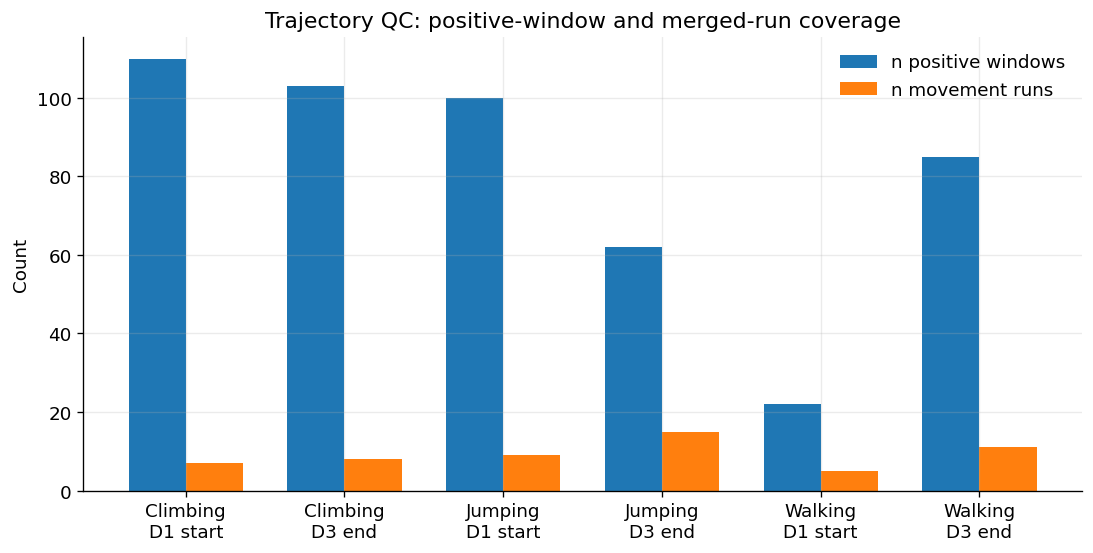

In [47]:
def plot_trajectory_coverage(qc_df):
    tidy = qc_df.melt(id_vars=["skill", "day", "part"], value_vars=["n_positive_windows", "n_movement_runs"],
                      var_name="measure", value_name="count")
    summary = tidy.groupby(["skill", "day", "part", "measure"], as_index=False)["count"].sum()
    fig, ax = plt.subplots(figsize=(9, 4.5), constrained_layout=True)
    labels = [f"{SKILL_LABELS[s]}\nD{d} {PART_LABELS[p]}" for s, d, p in summary[["skill", "day", "part"]].drop_duplicates().itertuples(index=False)]
    combinations = summary[["skill", "day", "part"]].drop_duplicates().to_records(index=False)
    x = np.arange(len(combinations)); width = 0.36
    for offset, measure in zip([-width/2, width/2], ["n_positive_windows", "n_movement_runs"]):
        values = [summary[(summary.skill == s) & (summary.day == d) & (summary.part == p) & (summary.measure == measure)]["count"].sum() for s,d,p in combinations]
        ax.bar(x + offset, values, width, label=measure.replace("_", " "))
    ax.set_xticks(x, labels); ax.set_ylabel("Count"); ax.set_title("Trajectory QC: positive-window and merged-run coverage")
    ax.legend(frameon=False)
    paths_saved = save_figure(fig, OUTPUT_DIRS["trajectories"]["qc"], "trajectory_coverage_qc", pdf=False)
    return fig, summary, paths_saved


trajectory_qc_fig, trajectory_coverage_plot_df, trajectory_qc_paths = plot_trajectory_coverage(trajectory_qc_df)
plt.show()

### Report-ready figures

Each faint path is one merged positive movement run for the configured subject. Color is the subject's stable configured color; line style identifies the joint. Panels compare Day 1 start and Day 3 end. These are descriptive, single-subject trajectories, not paired participant-level estimates.

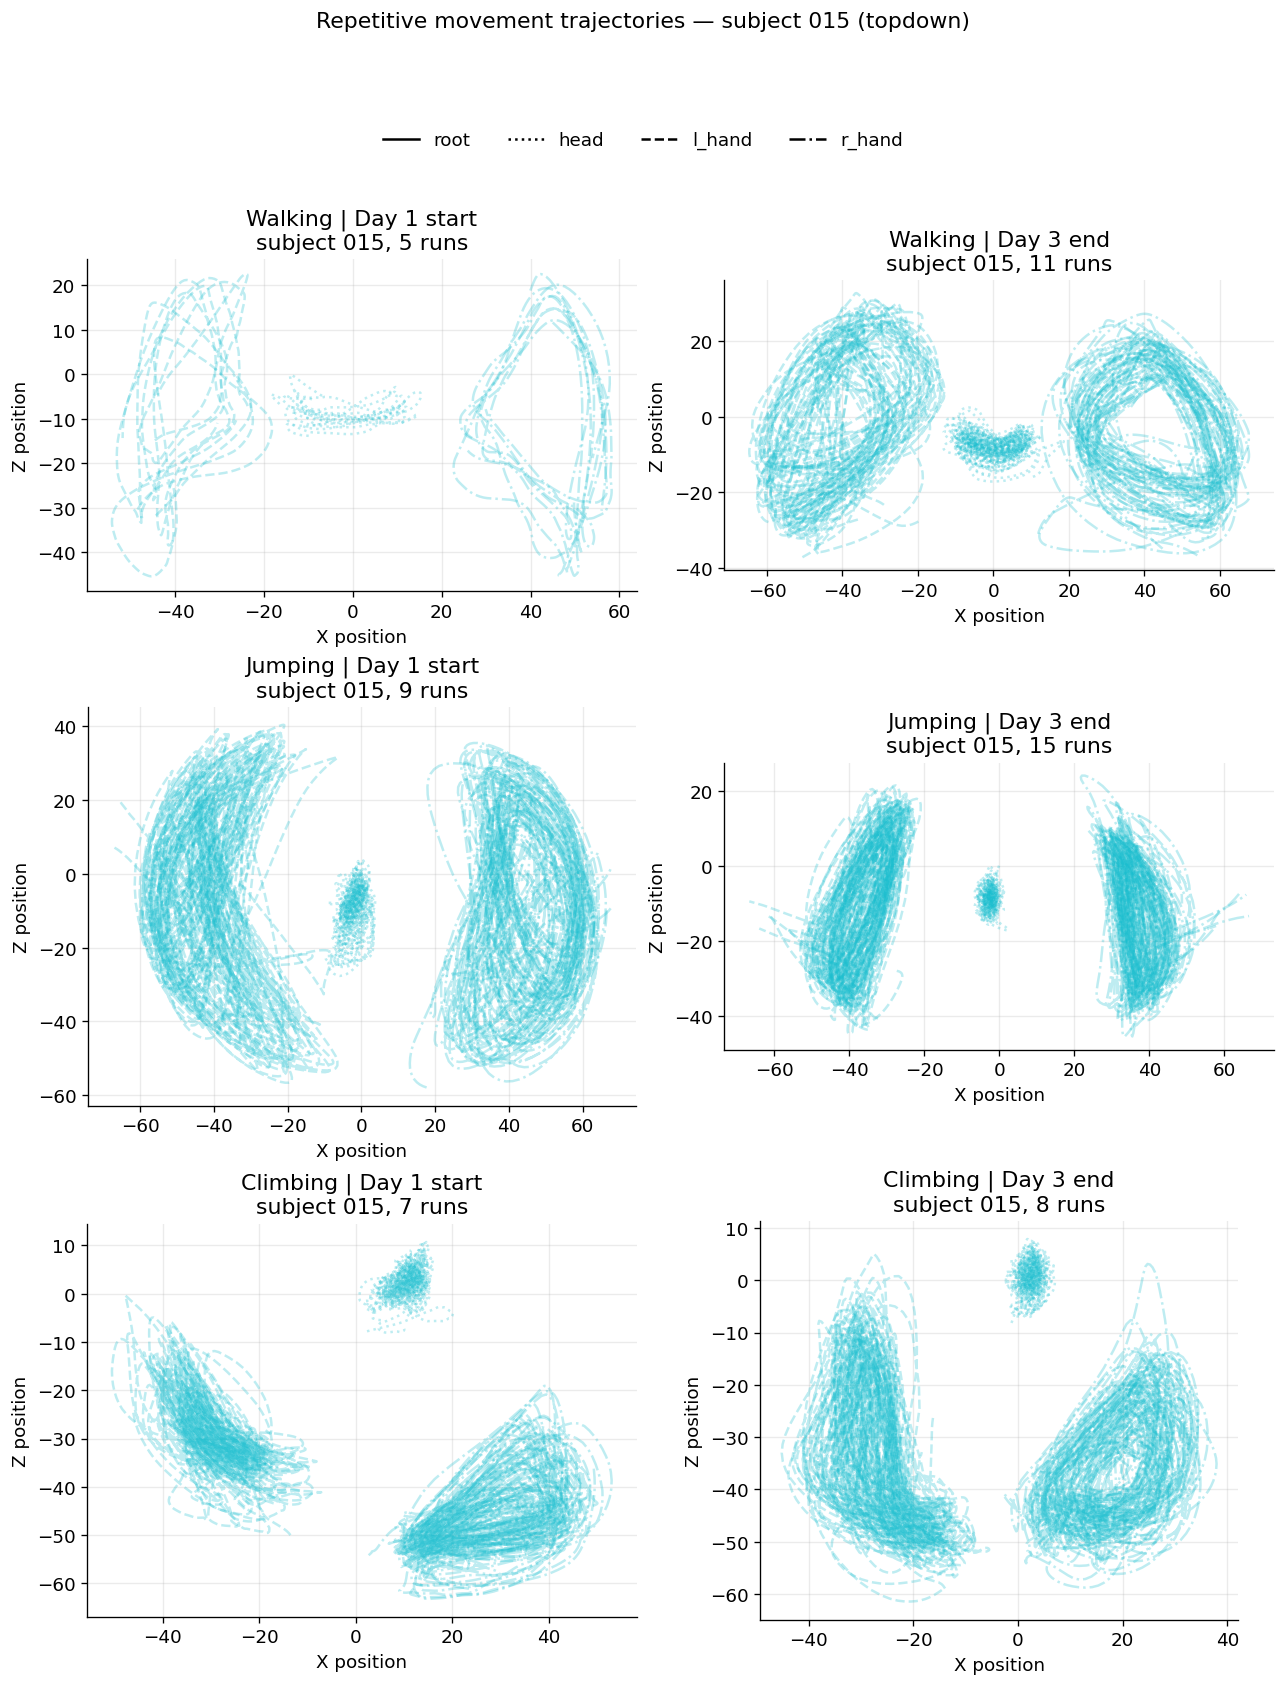

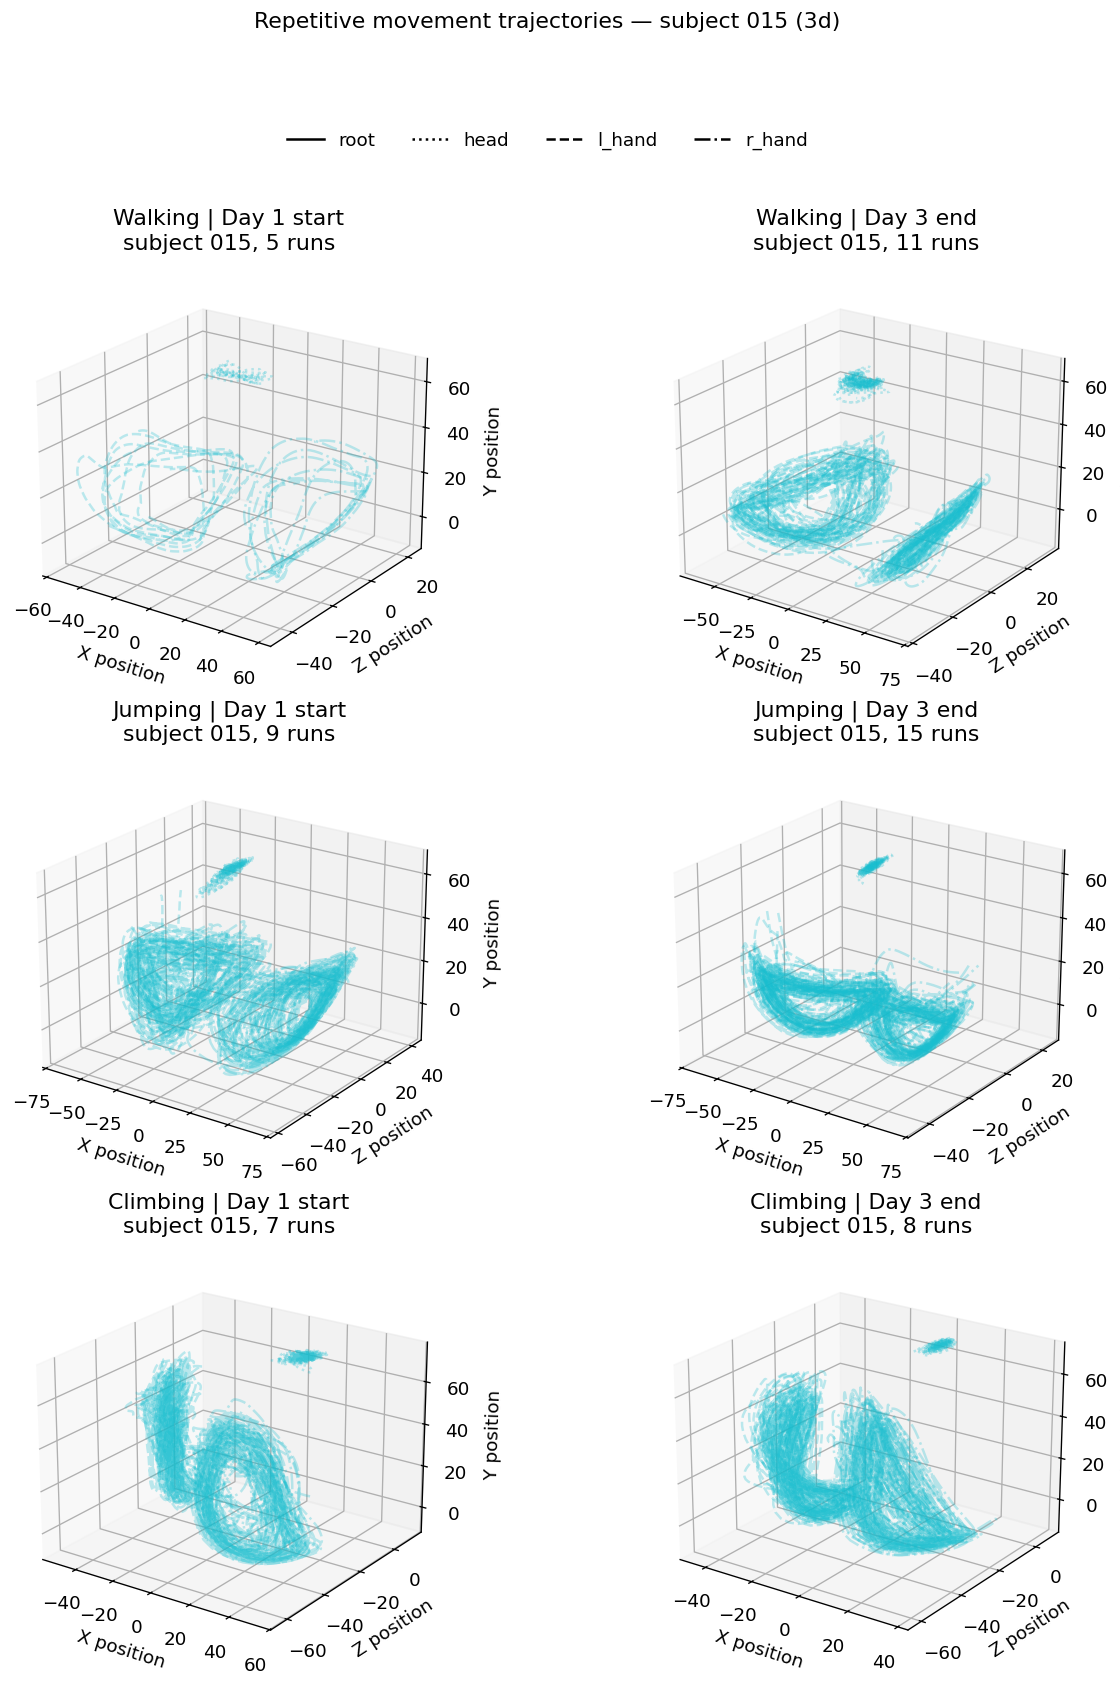

In [48]:
def plot_subject_trajectories(runs_df, parameters, view="topdown"):
    subject = normalize_repetitive_subject(parameters["subject"])
    skills, day_items = list(parameters["skills"]), list(parameters["day_part_map"].items())
    color = get_subject_color(subject)
    if view == "3d":
        fig = plt.figure(figsize=(5.3 * len(day_items), 4.1 * len(skills)), constrained_layout=True)
        axes = np.empty((len(skills), len(day_items)), dtype=object)
    else:
        fig, axes = plt.subplots(len(skills), len(day_items), figsize=(5.3 * len(day_items), 4.1 * len(skills)), squeeze=False, constrained_layout=True)
    styles = {"root": "-", "head": ":", "l_hand": "--", "r_hand": "-."}
    file_cache = {}
    plot_rows = []
    for row_index, skill in enumerate(skills):
        for column_index, (day, part) in enumerate(day_items):
            ax = fig.add_subplot(len(skills), len(day_items), row_index * len(day_items) + column_index + 1, projection="3d") if view == "3d" else axes[row_index, column_index]
            if view == "3d": axes[row_index, column_index] = ax
            condition = runs_df[(runs_df.subject.astype(str) == subject) & (runs_df.skill == skill) &
                                (runs_df.day.astype(int) == int(day)) & (runs_df.part.map(normalize_part_code) == normalize_part_code(part))]
            for run in condition.itertuples():
                frame = load_position_file(run.path, file_cache).iloc[run.run_start:run.run_end:parameters["step"]]
                for joint in parameters["joints"]:
                    columns = [f"{joint}.{axis}" for axis in "xyz"]
                    if any(column not in frame for column in columns): continue
                    if view == "topdown":
                        ax.plot(frame[columns[0]], frame[columns[2]], color=color, linestyle=styles.get(joint, "-"), alpha=0.28)
                    else:
                        ax.plot(frame[columns[0]], frame[columns[2]], frame[columns[1]], color=color, linestyle=styles.get(joint, "-"), alpha=0.28)
            ax.set_title(f"{SKILL_LABELS[skill]} | Day {day} {PART_LABELS[normalize_part_code(part)]}\nsubject {subject}, {len(condition)} runs")
            ax.set_xlabel("X position"); ax.set_ylabel("Z position")
            if view == "topdown": ax.set_aspect("equal", adjustable="box")
            else: ax.set_zlabel("Y position"); ax.view_init(elev=22, azim=-55)
            plot_rows.append({"subject": subject, "skill": skill, "day": day, "part": normalize_part_code(part), "n_runs": len(condition), "view": view})
    handles = [Line2D([0], [0], color="black", linestyle=style, label=joint) for joint, style in styles.items()]
    fig.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, 1.06), ncol=len(handles), frameon=False)
    fig.suptitle(f"Repetitive movement trajectories — subject {subject} ({view})", y=1.13)
    saved = save_figure(fig, OUTPUT_DIRS["trajectories"]["report"], f"subject_{subject}_day1start_day3end_{view}")
    return fig, pd.DataFrame(plot_rows), saved


trajectory_topdown_fig, trajectory_topdown_plot_df, trajectory_topdown_paths = plot_subject_trajectories(trajectory_runs_df, TRAJECTORY_PARAMS, "topdown")
plt.show()
trajectory_3d_fig, trajectory_3d_plot_df, trajectory_3d_paths = plot_subject_trajectories(trajectory_runs_df, TRAJECTORY_PARAMS, "3d")
plt.show()

### Saved outputs

In [49]:
print("Trajectory outputs:")
for key, value in OUTPUT_DIRS["trajectories"].items(): print(f"  {key}: {value}")

Trajectory outputs:
  root: D:\noamgonen\GitHub\gorilla_tag_\img\labeled_data_analysis\trajectories
  cache: D:\noamgonen\GitHub\gorilla_tag_\img\labeled_data_analysis\trajectories\cache
  tables: D:\noamgonen\GitHub\gorilla_tag_\img\labeled_data_analysis\trajectories\tables
  qc: D:\noamgonen\GitHub\gorilla_tag_\img\labeled_data_analysis\trajectories\figures\qc
  report: D:\noamgonen\GitHub\gorilla_tag_\img\labeled_data_analysis\trajectories\figures\report


## 3. PCA

### Purpose, data, and comparison

PCA quantifies how many standardized aligned-position components explain each subject's frame-level variance. A separate `StandardScaler` and PCA are fit for every existing **group × subject × day × skill** combination. Frames are concatenated only across that subject's labeled segments/windows; subjects are never pooled. Cumulative explained variance is

$$C_k = \sum_{i=1}^{k} r_i,$$

where $r_i$ is the explained-variance ratio of PC $i$; the reported threshold is the smallest $k$ with $C_k \ge 0.85$.

The threshold result is the smallest $k$ with $C_k \ge 0.85$. Day comparison is paired within subject and skill, and the reported change is

$$\Delta PC_{85}=PC_{85,\,Day\ 3}-PC_{85,\,Day\ 1}.$$

A positive value means more PCs were required on Day 3; a negative value means fewer were required. Only complete Day 1/Day 3 subject pairs enter comparison figures. Empty or very small combinations are recorded rather than aborting the section. Existing segment/window definitions are preserved, including all positive repetitive windows. The cache excludes raw stacked frames, fitted scalers, PCA models, and score matrices.

### Parameters

In [11]:
PCA_VERSION = f"{ANALYSIS_VERSION}_subject_level_pca_v1"
PCA_PARAMS = {
    "pca_version": PCA_VERSION,
    "groups": ("free", "repetitive"), "days": tuple(DAYS), "skills": tuple(SKILLS),
    "subjects_by_group": {"free": tuple(FREE_SUBJECTS), "repetitive": tuple(REPETITIVE_SUBJECTS)},
    "features": tuple(POSITION_FEATURES), "variance_threshold": 0.85, "max_plot_pcs": 20,
    "standardize_within_subject_condition": True,
    "unit_of_pca": "subject x day x skill",
    "day_change_definition": "day3_n_components_85 - day1_n_components_85",
}
PCA_PARAMS

{'pca_version': 'labeled_data_v2_subject_level_pca_v1',
 'groups': ('free', 'repetitive'),
 'days': (1, 3),
 'skills': ('walk', 'jump', 'climb'),
 'subjects_by_group': {'free': ('110',
   '111',
   '112',
   '113',
   '114',
   '115',
   '116'),
  'repetitive': ('002',
   '004',
   '006',
   '007',
   '008',
   '009',
   '010',
   '011',
   '012',
   '013',
   '014',
   '015')},
 'features': ('root.x',
  'root.y',
  'root.z',
  'head.x',
  'head.y',
  'head.z',
  'neck_1.x',
  'neck_1.y',
  'neck_1.z',
  'neck_2.x',
  'neck_2.y',
  'neck_2.z',
  'torso_1.x',
  'torso_1.y',
  'torso_1.z',
  'torso_2.x',
  'torso_2.y',
  'torso_2.z',
  'torso_3.x',
  'torso_3.y',
  'torso_3.z',
  'torso_4.x',
  'torso_4.y',
  'torso_4.z',
  'torso_5.x',
  'torso_5.y',
  'torso_5.z',
  'torso_6.x',
  'torso_6.y',
  'torso_6.z',
  'torso_7.x',
  'torso_7.y',
  'torso_7.z',
  'l_shoulder.x',
  'l_shoulder.y',
  'l_shoulder.z',
  'r_shoulder.x',
  'r_shoulder.y',
  'r_shoulder.z',
  'l_up_arm.x',
  'l_up_arm

### Load or compute results

In [12]:
def collect_subject_pca_matrix(label_df, group, subject, skill, day, features):
    """Collect aligned frames for exactly one subject x day x skill PCA."""
    selected = label_df[(label_df["subject_str"].astype(str) == str(subject)) &
                        (label_df["skill"] == skill) &
                        (label_df["day"].astype(int) == int(day))].copy()
    pieces, contributions, skipped = [], [], []
    file_cache = {}
    for _, row in selected.iterrows():
        segment, diagnostic = load_segment(group, row, columns=features, file_cache=file_cache)
        if segment is None:
            skipped.append(diagnostic); continue
        numeric = segment.apply(pd.to_numeric, errors="coerce")
        finite = np.isfinite(numeric.to_numpy(dtype=float)).all(axis=1)
        contributions.append({"group": group, "subject": str(subject), "day": int(day), "skill": skill,
                              "file": diagnostic["file"], "segment": int(row["segment"]), "frames_loaded": len(numeric),
                              "non_finite_rows_removed": int((~finite).sum()), "valid_frames": int(finite.sum())})
        if finite.any(): pieces.append(numeric.loc[finite, features])
    return (pd.concat(pieces, ignore_index=True) if pieces else None,
            pd.DataFrame(contributions), pd.DataFrame(skipped))


def compute_pca_results(free_df, repetitive_df, parameters):
    labels = {"free": free_df, "repetitive": repetitive_df}
    results, summaries, contribution_frames, skipped_frames = {}, [], [], []
    for group in parameters["groups"]:
        for subject in parameters["subjects_by_group"][group]:
            for day in parameters["days"]:
                for skill in parameters["skills"]:
                    matrix, contribution, skipped = collect_subject_pca_matrix(
                        labels[group], group, subject, skill, day, list(parameters["features"])
                    )
                    contribution_frames.append(contribution); skipped_frames.append(skipped)
                    key = f"{group}__subject{subject}__day{day}__{skill}"
                    n_segments = len(contribution)
                    n_non_finite = int(contribution["non_finite_rows_removed"].sum()) if len(contribution) else 0
                    if matrix is None or len(matrix) < 2:
                        summaries.append({"group": group, "subject": str(subject), "day": int(day), "skill": skill,
                                          "status": "missing_or_too_small", "n_valid_frames": 0 if matrix is None else len(matrix),
                                          "n_segments_loaded": n_segments, "non_finite_rows_removed": n_non_finite,
                                          "n_features": len(parameters["features"]), "n_components_85": np.nan,
                                          "pc1_variance": np.nan, "pc2_variance": np.nan, "pca_version": PCA_VERSION})
                        continue
                    X = StandardScaler().fit_transform(matrix.to_numpy(dtype=float))
                    model = PCA().fit(X)
                    explained = model.explained_variance_ratio_; cumulative = np.cumsum(explained)
                    results[key] = {"explained": explained, "cumulative": cumulative}
                    n_components = int(np.searchsorted(cumulative, parameters["variance_threshold"]) + 1)
                    summaries.append({"group": group, "subject": str(subject), "day": int(day), "skill": skill,
                                      "status": "ok", "n_valid_frames": len(matrix), "n_segments_loaded": n_segments,
                                      "non_finite_rows_removed": n_non_finite, "n_features": matrix.shape[1],
                                      "n_components_85": n_components, "pc1_variance": explained[0],
                                      "pc2_variance": explained[1] if len(explained) > 1 else np.nan, "pca_version": PCA_VERSION})
    contributions = pd.concat(contribution_frames, ignore_index=True) if contribution_frames else pd.DataFrame()
    if len(contributions):
        totals = contributions.groupby(["group", "subject", "day", "skill"])["valid_frames"].transform("sum")
        contributions["percent_frames_in_subject_pca"] = np.where(totals > 0, 100 * contributions.valid_frames / totals, np.nan)
    return results, pd.DataFrame(summaries), contributions, pd.concat(skipped_frames, ignore_index=True) if skipped_frames else pd.DataFrame()


def build_pca_day_comparison(summary):
    """Return complete and incomplete Day 1/Day 3 PC85 pairs by subject and skill."""
    valid = summary[summary["status"].eq("ok")].copy()
    observed = valid.pivot_table(index=["group", "subject", "skill"], columns="day",
                                 values="n_components_85", aggfunc="first").reset_index()
    expected = pd.DataFrame([{"group": group, "subject": str(subject), "skill": skill}
                             for group in PCA_PARAMS["groups"]
                             for subject in PCA_PARAMS["subjects_by_group"][group]
                             for skill in PCA_PARAMS["skills"]])
    wide = expected.merge(observed, on=["group", "subject", "skill"], how="left")
    for day in DAYS:
        if day not in wide.columns: wide[day] = np.nan
    wide = wide.rename(columns={1: "day1_n_components_85", 3: "day3_n_components_85"})
    required = ["day1_n_components_85", "day3_n_components_85"]
    incomplete = wide[wide[required].isna().any(axis=1)].copy()
    paired = wide.dropna(subset=required).copy()
    paired["delta_n_components_85_day3_minus_day1"] = (
        paired["day3_n_components_85"] - paired["day1_n_components_85"]
    )
    paired["pca_version"] = PCA_VERSION; incomplete["pca_version"] = PCA_VERSION
    return paired.sort_values(["group", "skill", "subject"]), incomplete.sort_values(["group", "skill", "subject"])


def load_or_build_pca(free_df, repetitive_df, parameters=None):
    parameters = PCA_PARAMS if parameters is None else parameters
    out = OUTPUT_DIRS["pca"]; cache = out["cache"] / f"{PCA_VERSION}_explained_variance.npz"
    bundle = out["cache"] / f"{PCA_VERSION}_tables.pkl"; manifest = out["cache"] / f"{PCA_VERSION}_manifest.json"
    inputs = [FREE_LABELS_PATH, *REPETITIVE_WINDOW_FILES.values(),
              *referenced_position_paths(free_df, "free"), *referenced_position_paths(repetitive_df, "repetitive")]
    signature, payload = cache_signature("pca", parameters, inputs)
    if not FORCE_RECOMPUTE["pca"] and cache.exists() and bundle.exists() and cache_is_valid(manifest, signature):
        arrays = np.load(cache); results = {}
        for key in {name.rsplit("__", 1)[0] for name in arrays.files}:
            results[key] = {"explained": arrays[f"{key}__explained"], "cumulative": arrays[f"{key}__cumulative"]}
        summary, contributions, skipped, paired, incomplete = pd.read_pickle(bundle)
        print(f"Loaded PCA cache: {cache}")
        return results, summary, contributions, skipped, paired, incomplete
    results, summary, contributions, skipped = compute_pca_results(free_df, repetitive_df, parameters)
    paired, incomplete = build_pca_day_comparison(summary)
    arrays = {f"{key}__{kind}": value for key, result in results.items() for kind, value in result.items()}
    atomic_npz(cache, **arrays); atomic_pickle_dump((summary, contributions, skipped, paired, incomplete), bundle)
    summary.to_csv(out["tables"] / f"{PCA_VERSION}_subject_pca_summary.csv", index=False)
    contributions.to_csv(out["tables"] / f"{PCA_VERSION}_segment_frame_qc.csv", index=False)
    skipped.to_csv(out["tables"] / f"{PCA_VERSION}_skipped_rows.csv", index=False)
    paired.to_csv(out["tables"] / f"{PCA_VERSION}_paired_day1_day3_pc85_delta.csv", index=False)
    incomplete.to_csv(out["tables"] / f"{PCA_VERSION}_incomplete_day_pairs.csv", index=False)
    write_manifest(manifest, "pca", signature, payload, [cache, bundle])
    print(f"Computed PCA cache: {cache}")
    return results, summary, contributions, skipped, paired, incomplete


pca_results, pca_summary_df, pca_contributions_df, pca_skipped_df, pca_paired_df, pca_incomplete_pairs_df = load_or_build_pca(free_labeled_df, repetitive_labeled_df)
display(pca_summary_df)
display(pca_paired_df)

Loaded PCA cache: D:\noamgonen\GitHub\gorilla_tag_\img\labeled_data_analysis\pca\cache\labeled_data_v2_subject_level_pca_v1_explained_variance.npz


,group,subject,day,skill,status,n_valid_frames,n_segments_loaded,non_finite_rows_removed,n_features,n_components_85,pc1_variance,pc2_variance,pca_version
0,free,110,1,walk,ok,15874,14,0,57,6.0,0.327529,0.288461,labeled_data_v2_subject_level_pca_v1
1,free,110,1,jump,missing_or_too_small,0,0,0,57,NaN,NaN,NaN,labeled_data_v2_subject_level_pca_v1
2,free,110,1,climb,missing_or_too_small,0,0,0,57,NaN,NaN,NaN,labeled_data_v2_subject_level_pca_v1
3,free,110,3,walk,ok,7077,10,0,57,6.0,0.377636,0.258057,labeled_data_v2_subject_level_pca_v1
4,free,110,3,jump,missing_or_too_small,0,0,0,57,NaN,NaN,NaN,labeled_data_v2_subject_level_pca_v1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
109,repetitive,015,1,jump,ok,30840,257,0,57,5.0,0.434312,0.186874,labeled_data_v2_subject_level_pca_v1
110,repetitive,015,1,climb,ok,37080,309,0,57,4.0,0.387702,0.289018,labeled_data_v2_subject_level_pca_v1
111,repetitive,015,3,walk,ok,29400,245,0,57,5.0,0.365979,0.233928,labeled_data_v2_subject_level_pca_v1
112,repetitive,015,3,jump,ok,23400,195,0,57,5.0,0.441652,0.178879,labeled_data_v2_subject_level_pca_v1


,group,subject,skill,day1_n_components_85,day3_n_components_85,delta_n_components_85_day3_minus_day1,pca_version
14,free,114,climb,4.0,4.0,0.0,labeled_data_v2_subject_level_pca_v1
0,free,110,walk,6.0,6.0,0.0,labeled_data_v2_subject_level_pca_v1
3,free,111,walk,5.0,4.0,-1.0,labeled_data_v2_subject_level_pca_v1
6,free,112,walk,4.0,6.0,2.0,labeled_data_v2_subject_level_pca_v1
9,free,113,walk,5.0,5.0,0.0,labeled_data_v2_subject_level_pca_v1
12,free,114,walk,5.0,6.0,1.0,labeled_data_v2_subject_level_pca_v1
23,repetitive,002,climb,5.0,4.0,-1.0,labeled_data_v2_subject_level_pca_v1
26,repetitive,004,climb,4.0,5.0,1.0,labeled_data_v2_subject_level_pca_v1
29,repetitive,006,climb,4.0,3.0,-1.0,labeled_data_v2_subject_level_pca_v1
32,repetitive,007,climb,4.0,5.0,1.0,labeled_data_v2_subject_level_pca_v1


### Quality-control outputs

Bars show the valid frame count used by each independent subject × day × skill PCA. Subject identity is color; solid bars are Day 1 and hatched bars are Day 3. A missing bar indicates a missing or too-small subject condition, which remains recorded in the summary and incomplete-pair tables. Segment-level QC records loaded frames and non-finite removals.

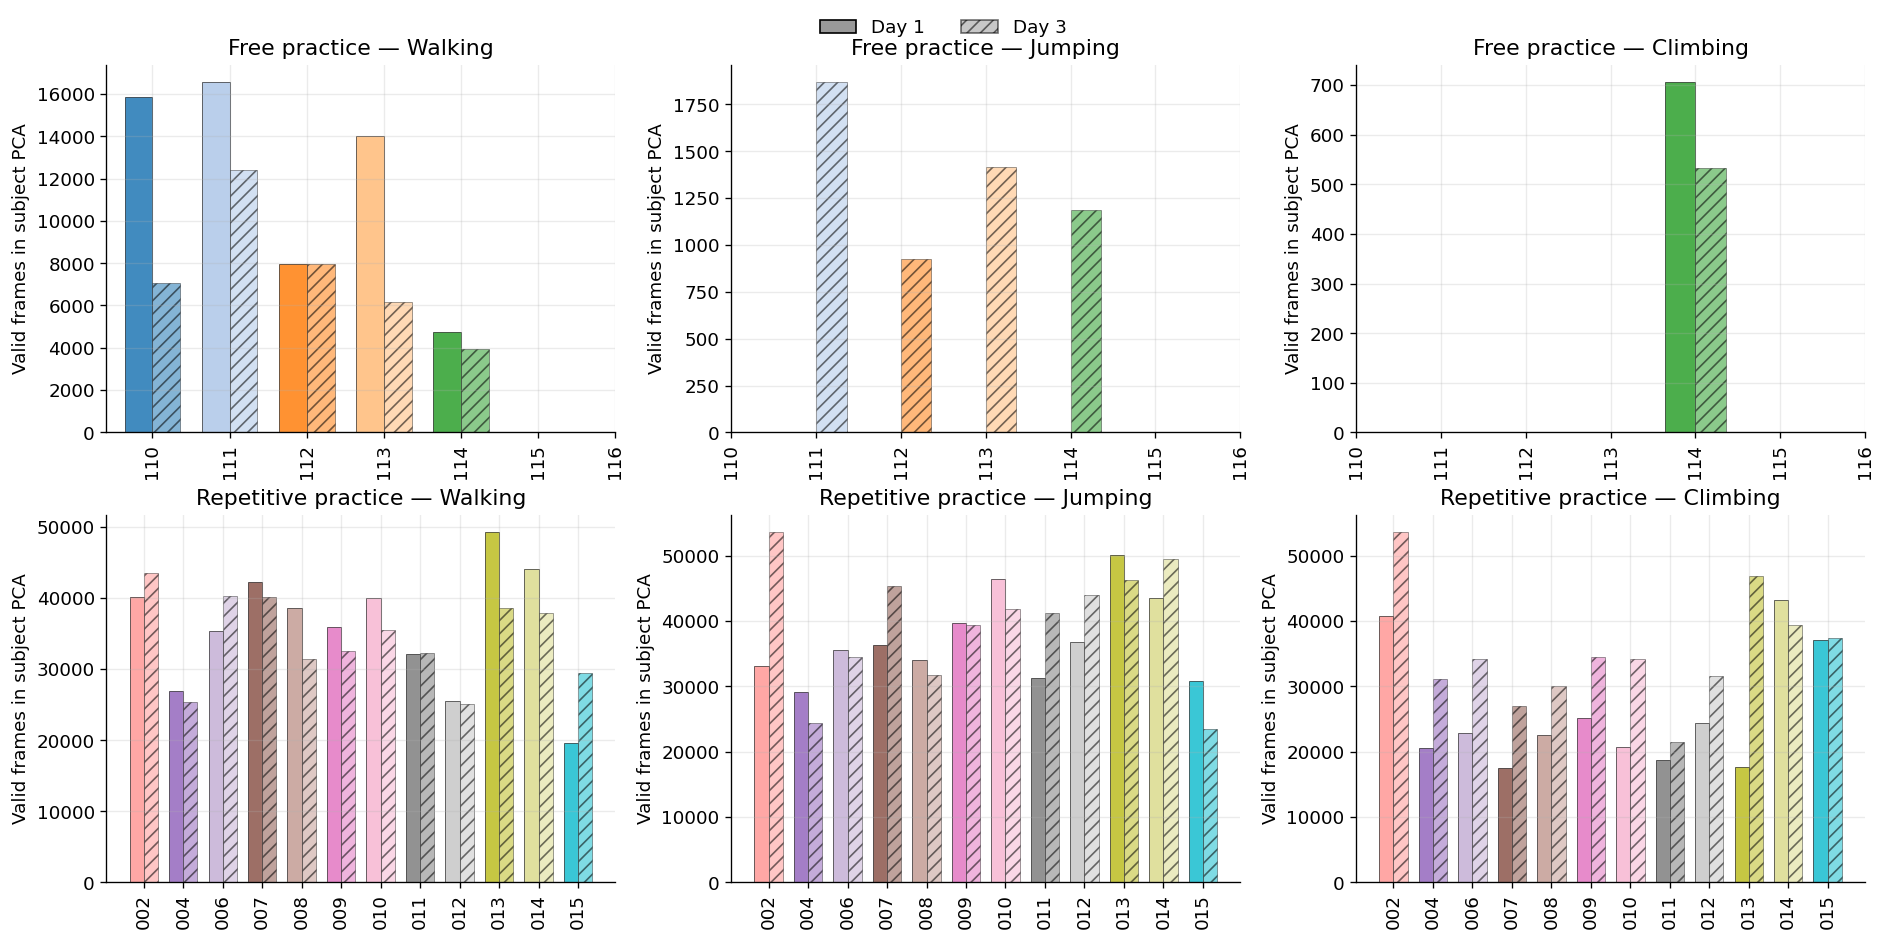

In [13]:
def plot_subject_pca_frame_counts(summary):
    plot_df = summary.copy()
    fig, axes = plt.subplots(2, len(SKILLS), figsize=(5.2 * len(SKILLS), 7.5), constrained_layout=True, squeeze=False)
    for row_index, group in enumerate(["free", "repetitive"]):
        for column_index, skill in enumerate(SKILLS):
            ax = axes[row_index, column_index]
            condition = plot_df[(plot_df.group == group) & (plot_df.skill == skill)].copy()
            subjects = list(PCA_PARAMS["subjects_by_group"][group]); x = np.arange(len(subjects)); width = 0.36
            for offset, day, hatch in [(-width/2, 1, None), (width/2, 3, "///")]:
                indexed = condition[condition.day.eq(day)].set_index("subject")
                values = [indexed.loc[subject, "n_valid_frames"] if subject in indexed.index and indexed.loc[subject, "status"] == "ok" else np.nan for subject in subjects]
                colors = [get_subject_color(subject, group) for subject in subjects]
                ax.bar(x + offset, values, width, color=colors, hatch=hatch, alpha=0.85 if day == 1 else 0.55,
                       edgecolor="black", linewidth=0.4, label=f"Day {day}")
            ax.set_xticks(x, subjects, rotation=90); ax.set_ylabel("Valid frames in subject PCA")
            ax.set_title(f"{GROUP_LABELS[group]} — {SKILL_LABELS[skill]}")
    handles = [plt.Rectangle((0,0),1,1,facecolor="0.6",edgecolor="black",label="Day 1"),
               plt.Rectangle((0,0),1,1,facecolor="0.6",edgecolor="black",hatch="///",alpha=0.55,label="Day 3")]
    fig.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, 1.035), ncol=2, frameon=False)
    saved = save_figure(fig, OUTPUT_DIRS["pca"]["qc"], "subject_level_pca_v1_subject_pca_frame_counts_qc", pdf=False)
    return fig, plot_df, saved


pca_qc_fig, pca_frame_count_plot_df, pca_qc_paths = plot_subject_pca_frame_counts(pca_summary_df)
plt.show()

### Report-ready figures

Each PCA is subject-specific. In the paired-count figure, each colored line is one subject and connects that subject's $PC_{85}$ on Day 1 and Day 3. In the primary change figure, each bar is $\Delta PC_{85}=Day\ 3-Day\ 1$ for one complete subject pair; the horizontal zero line means no change. Positive bars indicate that more PCs were required on Day 3. The cumulative-variance QC/report figure also keeps subject as color and day as line style; its horizontal line marks 85%.

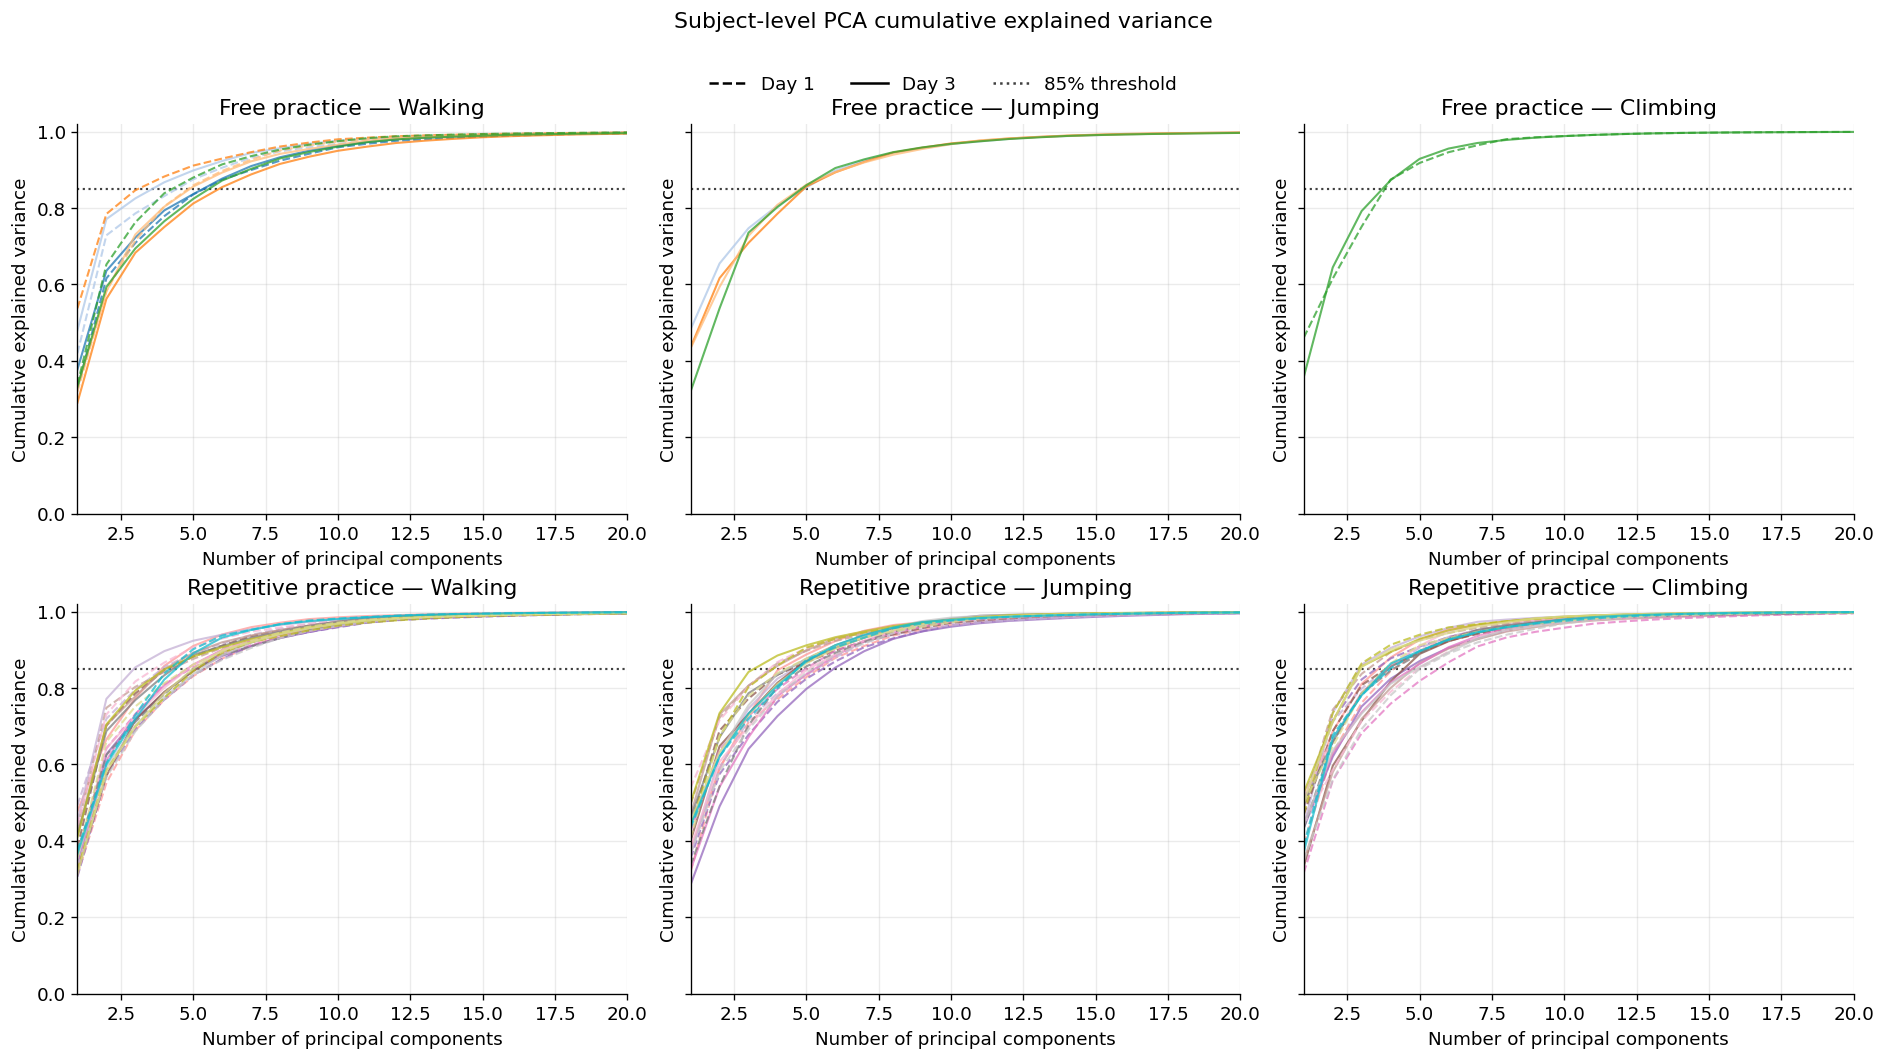

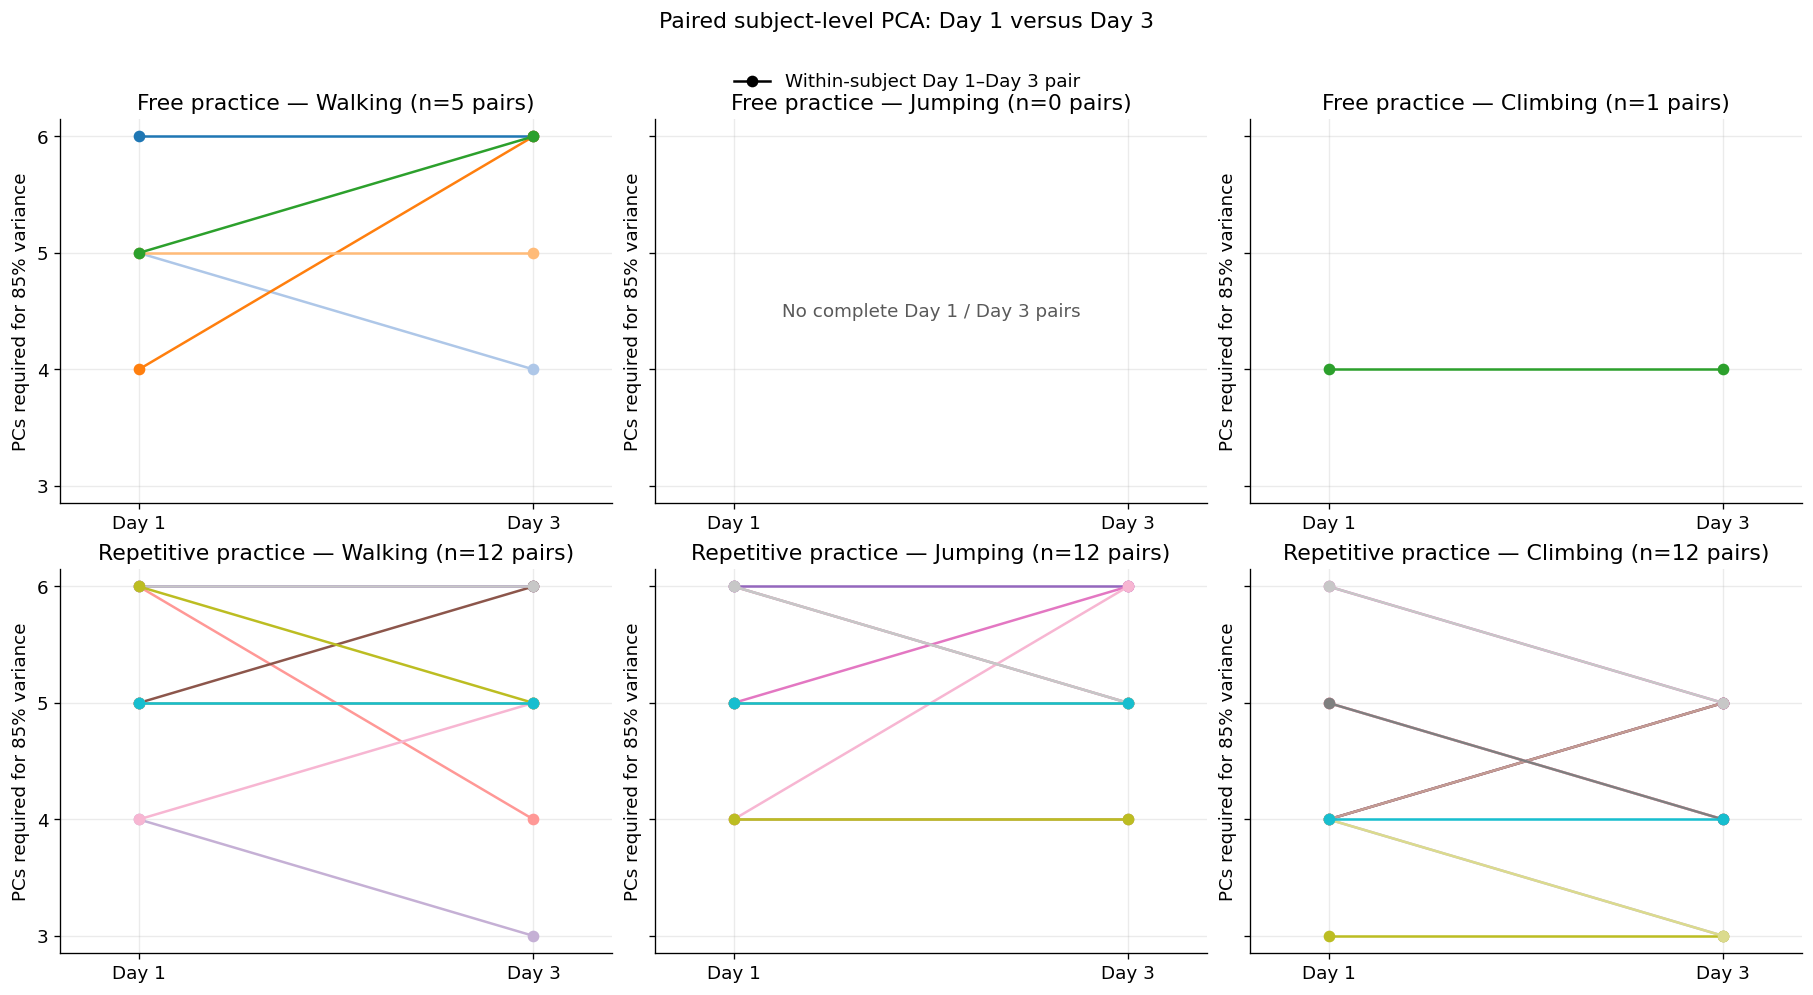

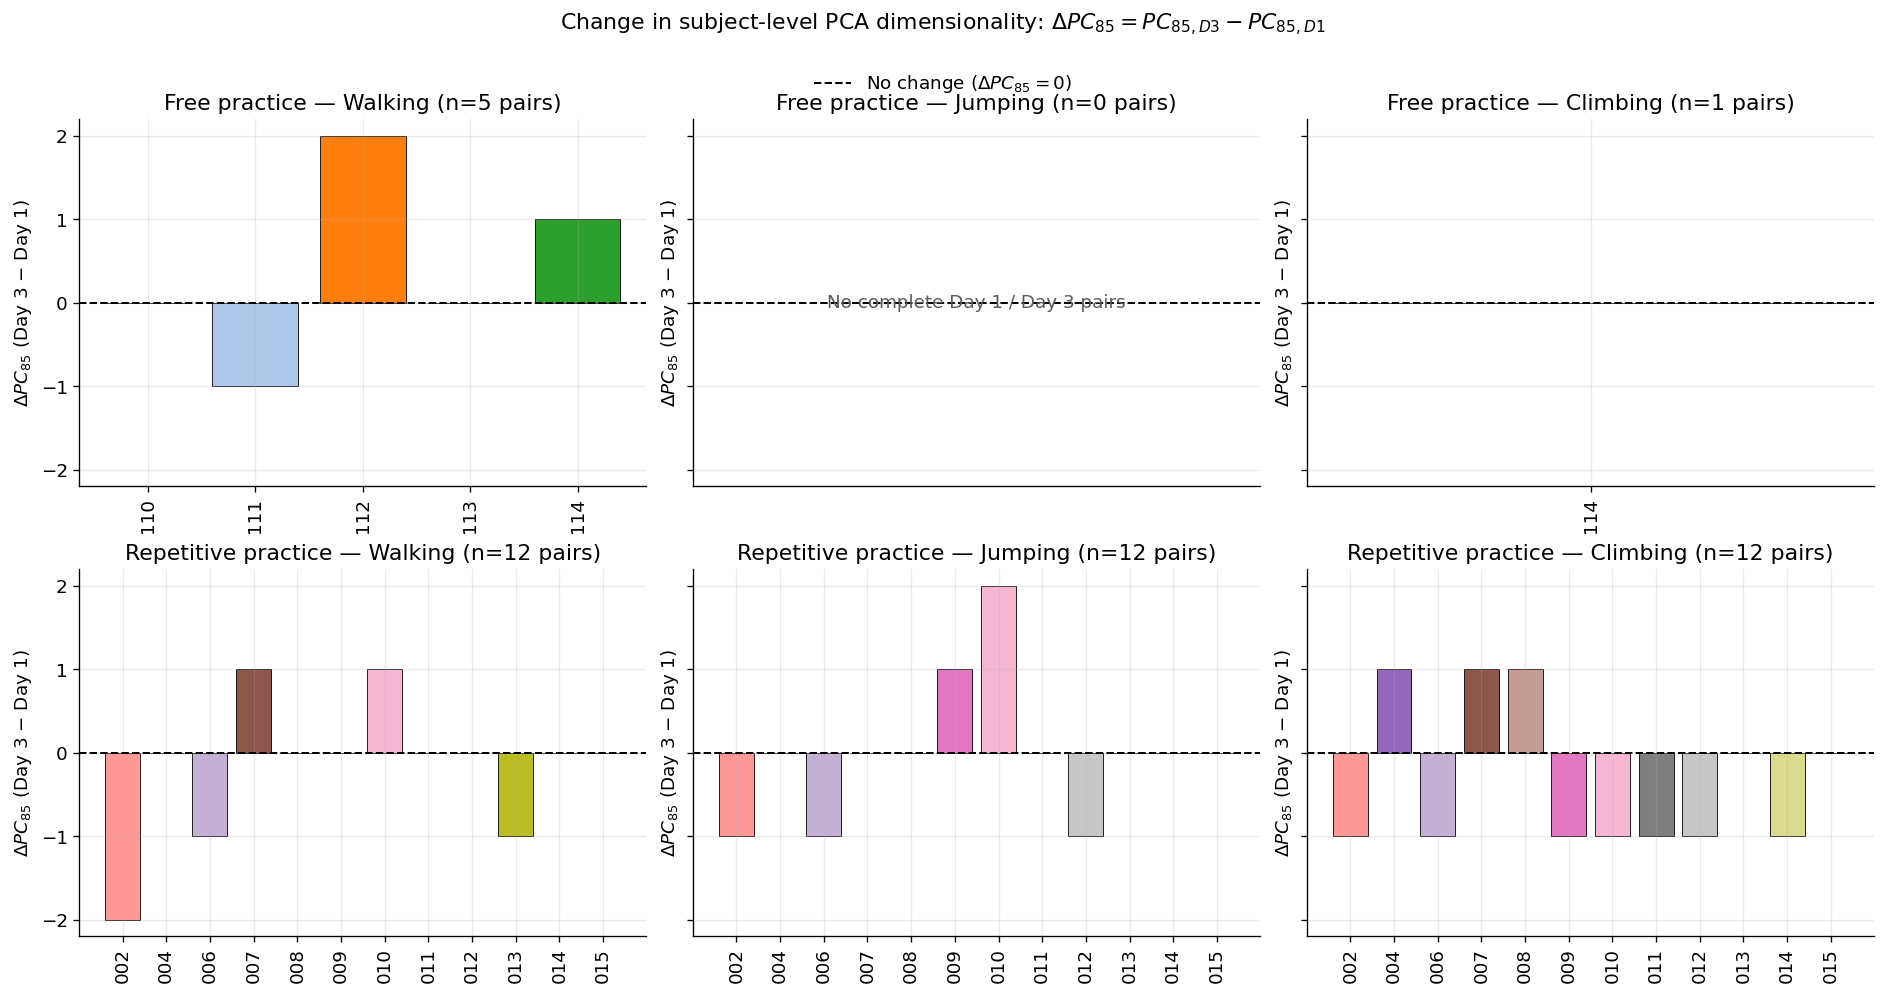

In [14]:
def plot_subject_pca_cumulative(results):
    fig, axes = plt.subplots(2, len(SKILLS), figsize=(5.2 * len(SKILLS), 8.0), sharey=True, constrained_layout=True, squeeze=False)
    for row_index, group in enumerate(["free", "repetitive"]):
        for column_index, skill in enumerate(SKILLS):
            ax = axes[row_index, column_index]
            ax.axhline(PCA_PARAMS["variance_threshold"], color="0.25", linestyle=":", linewidth=1.3)
            for subject in PCA_PARAMS["subjects_by_group"][group]:
                for day in DAYS:
                    key = f"{group}__subject{subject}__day{day}__{skill}"; result = results.get(key)
                    if result is None: continue
                    cumulative = result["cumulative"]; n = min(len(cumulative), PCA_PARAMS["max_plot_pcs"])
                    ax.plot(np.arange(1, n + 1), cumulative[:n], color=get_subject_color(subject, group),
                            linestyle=DAY_LINESTYLES[day], linewidth=1.25, alpha=0.75)
            ax.set(title=f"{GROUP_LABELS[group]} — {SKILL_LABELS[skill]}", xlabel="Number of principal components",
                   xlim=(1, PCA_PARAMS["max_plot_pcs"]), ylim=(0, 1.02))
            ax.set_ylabel("Cumulative explained variance")
    handles = [Line2D([0],[0], color="black", linestyle=DAY_LINESTYLES[day], label=f"Day {day}") for day in DAYS]
    handles.append(Line2D([0],[0], color="0.25", linestyle=":", label="85% threshold"))
    fig.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, 1.035), ncol=3, frameon=False)
    fig.suptitle("Subject-level PCA cumulative explained variance", y=1.085)
    saved = save_figure(fig, OUTPUT_DIRS["pca"]["report"], "subject_level_pca_v1_cumulative_variance_by_subject_day")
    return fig, pca_summary_df.copy(), saved


def plot_subject_pca_paired_counts(paired):
    fig, axes = plt.subplots(2, len(SKILLS), figsize=(5.0 * len(SKILLS), 7.5), sharey=True, constrained_layout=True, squeeze=False)
    for row_index, group in enumerate(["free", "repetitive"]):
        for column_index, skill in enumerate(SKILLS):
            ax = axes[row_index, column_index]; condition = paired[(paired.group == group) & (paired.skill == skill)]
            if condition.empty:
                ax.text(0.5, 0.5, "No complete Day 1 / Day 3 pairs", ha="center", va="center",
                        transform=ax.transAxes, color="0.35")
            for row in condition.itertuples():
                color = get_subject_color(row.subject, group)
                ax.plot([1, 2], [row.day1_n_components_85, row.day3_n_components_85], color=color, marker="o", linewidth=1.5)
            ax.set_xticks([1,2], ["Day 1", "Day 3"]); ax.set_xlim(0.8,2.2)
            ax.set_title(f"{GROUP_LABELS[group]} — {SKILL_LABELS[skill]} (n={len(condition)} pairs)")
            ax.set_ylabel("PCs required for 85% variance"); ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    handles = [Line2D([0], [0], color="black", marker="o", linewidth=1.5,
                      label="Within-subject Day 1–Day 3 pair")]
    fig.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, 1.035), frameon=False)
    fig.suptitle("Paired subject-level PCA: Day 1 versus Day 3", y=1.085)
    saved = save_figure(fig, OUTPUT_DIRS["pca"]["report"], "subject_level_pca_v1_paired_pc85_day1_vs_day3")
    return fig, paired.copy(), saved


def plot_subject_pca_pc85_delta(paired):
    fig, axes = plt.subplots(2, len(SKILLS), figsize=(5.2 * len(SKILLS), 7.5), sharey=True, constrained_layout=True, squeeze=False)
    for row_index, group in enumerate(["free", "repetitive"]):
        for column_index, skill in enumerate(SKILLS):
            ax = axes[row_index, column_index]; condition = paired[(paired.group == group) & (paired.skill == skill)].copy()
            if condition.empty:
                ax.text(0.5, 0.5, "No complete Day 1 / Day 3 pairs", ha="center", va="center",
                        transform=ax.transAxes, color="0.35")
            x = np.arange(len(condition)); colors = [get_subject_color(subject, group) for subject in condition.subject]
            ax.bar(x, condition.delta_n_components_85_day3_minus_day1, color=colors, edgecolor="black", linewidth=0.5)
            ax.axhline(0, color="black", linestyle="--", linewidth=1.2)
            ax.set_xticks(x, condition.subject, rotation=90); ax.yaxis.set_major_locator(MaxNLocator(integer=True))
            ax.set_title(f"{GROUP_LABELS[group]} — {SKILL_LABELS[skill]} (n={len(condition)} pairs)")
            ax.set_ylabel(r"$\Delta PC_{85}$ (Day 3 − Day 1)")
    handles = [Line2D([0], [0], color="black", linestyle="--", linewidth=1.2,
                      label=r"No change ($\Delta PC_{85}=0$)")]
    fig.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, 1.035), frameon=False)
    fig.suptitle(r"Change in subject-level PCA dimensionality: $\Delta PC_{85}=PC_{85,D3}-PC_{85,D1}$", y=1.085)
    saved = save_figure(fig, OUTPUT_DIRS["pca"]["report"], "subject_level_pca_v1_delta_pc85_day3_minus_day1")
    return fig, paired.copy(), saved


pca_cumulative_fig, pca_cumulative_plot_df, pca_cumulative_paths = plot_subject_pca_cumulative(pca_results); plt.show()
pca_paired_fig, pca_paired_plot_df, pca_paired_paths = plot_subject_pca_paired_counts(pca_paired_df); plt.show()
pca_delta_fig, pca_delta_plot_df, pca_delta_paths = plot_subject_pca_pc85_delta(pca_paired_df); plt.show()

### Saved outputs

In [15]:
print("PCA outputs:")
for key, value in OUTPUT_DIRS["pca"].items(): print(f"  {key}: {value}")

PCA outputs:
  root: D:\noamgonen\GitHub\gorilla_tag_\img\labeled_data_analysis\pca
  cache: D:\noamgonen\GitHub\gorilla_tag_\img\labeled_data_analysis\pca\cache
  tables: D:\noamgonen\GitHub\gorilla_tag_\img\labeled_data_analysis\pca\tables
  qc: D:\noamgonen\GitHub\gorilla_tag_\img\labeled_data_analysis\pca\figures\qc
  report: D:\noamgonen\GitHub\gorilla_tag_\img\labeled_data_analysis\pca\figures\report


## 4. Movement smoothness: Normalized Integrated Jerk

### Purpose, data, and comparison

Smoothness is computed for every complete 120-frame positive repetitive-practice window. For each configured body point, the three XYZ coordinates are differentiated numerically three times with `numpy.gradient` at 60 Hz. Path length is the sum of Euclidean 3D steps. The existing dimensionless definition is

$$\mathrm{NIJ}=\frac{T^5}{L^2}\int_0^T \|\mathbf{j}(t)\|^2\,dt,$$

with $T=(n-1)\,dt$, $dt=1/60$ s, and $L$ the 3D path length. At least seven finite samples and nonzero duration/path length are required. The window-level `nij_mean` is the arithmetic mean across body points with finite NIJ.

Window distributions are QC only: windows are not independent participants. Report comparisons first take the median within subject × skill × day × selected part, then retain complete Day 1 start / Day 3 end subject pairs. No statistical test is run.

### Parameters

In [16]:
SMOOTHNESS_PARAMS = {
    "sampling_frequency_hz": FS_HZ, "dt": DT, "required_window_frames": 120,
    "minimum_finite_samples": 7, "points": tuple(SMOOTHNESS_POINTS),
    "skills": tuple(SKILLS), "days": tuple(DAYS), "day_part_map": {1: "s", 3: "e"},
    "subject_aggregation": "median", "extreme_quantile": 0.995,
}
SMOOTHNESS_PARAMS

{'sampling_frequency_hz': 60.0,
 'dt': 0.016666666666666666,
 'required_window_frames': 120,
 'minimum_finite_samples': 7,
 'points': ('root',
  'head',
  'l_shoulder',
  'r_shoulder',
  'l_up_arm',
  'r_up_arm',
  'l_low_arm',
  'r_low_arm',
  'l_hand',
  'r_hand',
  'torso_1',
  'torso_2',
  'torso_3',
  'torso_4',
  'torso_5',
  'torso_6',
  'torso_7'),
 'skills': ('walk', 'jump', 'climb'),
 'days': (1, 3),
 'day_part_map': {1: 's', 3: 'e'},
 'subject_aggregation': 'median',
 'extreme_quantile': 0.995}

### Load or compute results

In [17]:
def normalized_integrated_jerk(xyz, dt=DT, minimum_samples=7):
    """Return NIJ for one point's XYZ trajectory; unit of analysis is one window."""
    xyz = np.asarray(xyz, dtype=float)
    xyz = xyz[np.isfinite(xyz).all(axis=1)]
    if len(xyz) < minimum_samples: return np.nan
    velocity = np.gradient(xyz, dt, axis=0)
    acceleration = np.gradient(velocity, dt, axis=0)
    jerk = np.gradient(acceleration, dt, axis=0)
    integral = float(np.sum(jerk ** 2) * dt)
    duration = (len(xyz) - 1) * dt
    path_length = float(np.linalg.norm(np.diff(xyz, axis=0), axis=1).sum())
    if duration <= 1e-9 or path_length <= 1e-9: return np.nan
    return (duration ** 5 / path_length ** 2) * integral


def compute_window_smoothness(segment, parameters):
    values, output = [], {}
    for point in parameters["points"]:
        columns = [f"{point}.{axis}" for axis in "xyz"]
        if any(column not in segment for column in columns):
            value = np.nan
        else:
            value = normalized_integrated_jerk(segment[columns].apply(pd.to_numeric, errors="coerce").to_numpy(),
                                               parameters["dt"], parameters["minimum_finite_samples"])
        output[f"nij_{point}"] = value
        if np.isfinite(value): values.append(value)
    output["nij_mean"] = float(np.mean(values)) if values else np.nan
    output["n_points_with_finite_nij"] = len(values)
    return output


def compute_smoothness(rep_df, parameters):
    rows, qc_rows, skipped = [], [], []
    selected = rep_df[rep_df.skill.isin(parameters["skills"]) & rep_df.day.astype(int).isin(parameters["days"])].copy()
    file_cache = {}
    for _, row in selected.iterrows():
        segment, diagnostic = load_segment("repetitive", row, file_cache=file_cache)
        base = {"group": "repetitive", "subject": row.subject_str, "skill": row.skill, "day": int(row.day),
                "part": normalize_part_code(row.part), "segment": int(row.segment), "window_id": int(row.window_id),
                "source_file": row.source_file, "file": diagnostic["file"], "requested_frames": int(row.length)}
        loaded_frames = 0 if segment is None else len(segment)
        qc = {**base, "loaded_frames": loaded_frames, "complete_120_frames": loaded_frames == parameters["required_window_frames"],
              "truncated": diagnostic.get("truncated", False), "error": diagnostic.get("error", "")}
        if segment is None:
            qc_rows.append(qc); skipped.append({**base, "error": diagnostic["error"]}); continue
        if loaded_frames != parameters["required_window_frames"]:
            qc["error"] = "not_complete_120_frame_window"; qc_rows.append(qc); skipped.append({**base, "error": qc["error"]}); continue
        metrics = compute_window_smoothness(segment, parameters)
        rows.append({**base, "n_frames": loaded_frames, **metrics})
        qc.update({"nij_mean": metrics["nij_mean"], "finite_nij": np.isfinite(metrics["nij_mean"]),
                   "n_points_with_finite_nij": metrics["n_points_with_finite_nij"]})
        qc_rows.append(qc)
    values = pd.DataFrame(rows); qc = pd.DataFrame(qc_rows); skipped_df = pd.DataFrame(skipped)
    if len(values):
        finite = values.nij_mean[np.isfinite(values.nij_mean)]
        threshold = finite.quantile(parameters["extreme_quantile"]) if len(finite) else np.nan
        values["extreme_value_q995"] = values.nij_mean.ge(threshold) if np.isfinite(threshold) else False
    return values, qc, skipped_df


def load_or_build_smoothness(rep_df, parameters=None):
    parameters = SMOOTHNESS_PARAMS if parameters is None else parameters
    out = OUTPUT_DIRS["smoothness"]; cache = out["cache"] / f"{ANALYSIS_VERSION}_window_nij.pkl"
    manifest = out["cache"] / f"{ANALYSIS_VERSION}_manifest.json"
    inputs = [*REPETITIVE_WINDOW_FILES.values(), *referenced_position_paths(rep_df, "repetitive")]
    signature, payload = cache_signature("smoothness", parameters, inputs)
    if not FORCE_RECOMPUTE["smoothness"] and cache.exists() and cache_is_valid(manifest, signature):
        print(f"Loaded smoothness cache: {cache}"); return pd.read_pickle(cache)
    result = compute_smoothness(rep_df, parameters); atomic_pickle_dump(result, cache)
    for name, frame in zip(["window_nij", "window_qc", "skipped_rows"], result):
        frame.to_csv(out["tables"] / f"{ANALYSIS_VERSION}_{name}.csv", index=False)
    write_manifest(manifest, "smoothness", signature, payload, [cache])
    print(f"Computed smoothness cache: {cache}"); return result


smoothness_df, smoothness_qc_df, smoothness_skipped_df = load_or_build_smoothness(repetitive_labeled_df)
display(smoothness_df.head())
display(smoothness_qc_df.groupby(["skill", "day", "part", "complete_120_frames"], dropna=False).size().reset_index(name="n_windows"))

Loaded smoothness cache: D:\noamgonen\GitHub\gorilla_tag_\img\labeled_data_analysis\smoothness\cache\labeled_data_v2_window_nij.pkl


,group,subject,skill,day,part,segment,window_id,source_file,file,requested_frames,...,nij_torso_1,nij_torso_2,nij_torso_3,nij_torso_4,nij_torso_5,nij_torso_6,nij_torso_7,nij_mean,n_points_with_finite_nij,extreme_value_q995
0,repetitive,002,walk,1,s,0,0,002-1-s-w,002-1-s-w_pos_aligned.csv,120,...,1.576858e+06,3.453102e+06,2.509391e+06,2.177142e+06,3.070201e+06,7.949194e+06,2.078387e+07,6.141320e+07,16,True
1,repetitive,002,walk,1,s,1,1,002-1-s-w,002-1-s-w_pos_aligned.csv,120,...,5.481812e+05,1.651098e+06,1.205146e+06,1.001369e+06,8.326498e+05,7.780037e+05,9.308152e+05,7.475728e+05,16,False
2,repetitive,002,walk,1,s,2,2,002-1-s-w,002-1-s-w_pos_aligned.csv,120,...,5.818350e+05,1.901485e+06,1.573279e+06,1.365811e+06,1.147043e+06,1.046345e+06,1.158423e+06,9.055337e+05,16,False
3,repetitive,002,walk,1,s,3,3,002-1-s-w,002-1-s-w_pos_aligned.csv,120,...,7.105389e+05,2.308986e+06,1.815206e+06,1.451995e+06,1.185278e+06,1.108202e+06,1.230189e+06,9.674947e+05,16,False
4,repetitive,002,walk,1,s,4,4,002-1-s-w,002-1-s-w_pos_aligned.csv,120,...,9.345360e+05,2.759954e+06,2.028956e+06,1.542513e+06,1.221631e+06,1.103536e+06,1.206075e+06,1.046055e+06,16,False


,skill,day,part,complete_120_frames,n_windows
0,climb,1,e,False,121
1,climb,1,e,True,931
2,climb,1,m,False,59
3,climb,1,m,True,915
4,climb,1,s,False,59
5,climb,1,s,True,743
6,climb,3,e,False,22
7,climb,3,e,True,1212
8,climb,3,m,False,20
9,climb,3,m,True,1181


### Quality-control outputs

The left panels show complete-window NIJ distributions on a log scale; each point is one window. The right panels show complete versus truncated/invalid window counts. Extreme NIJ values are flagged in the saved table at the configured 99.5th percentile but are not removed.

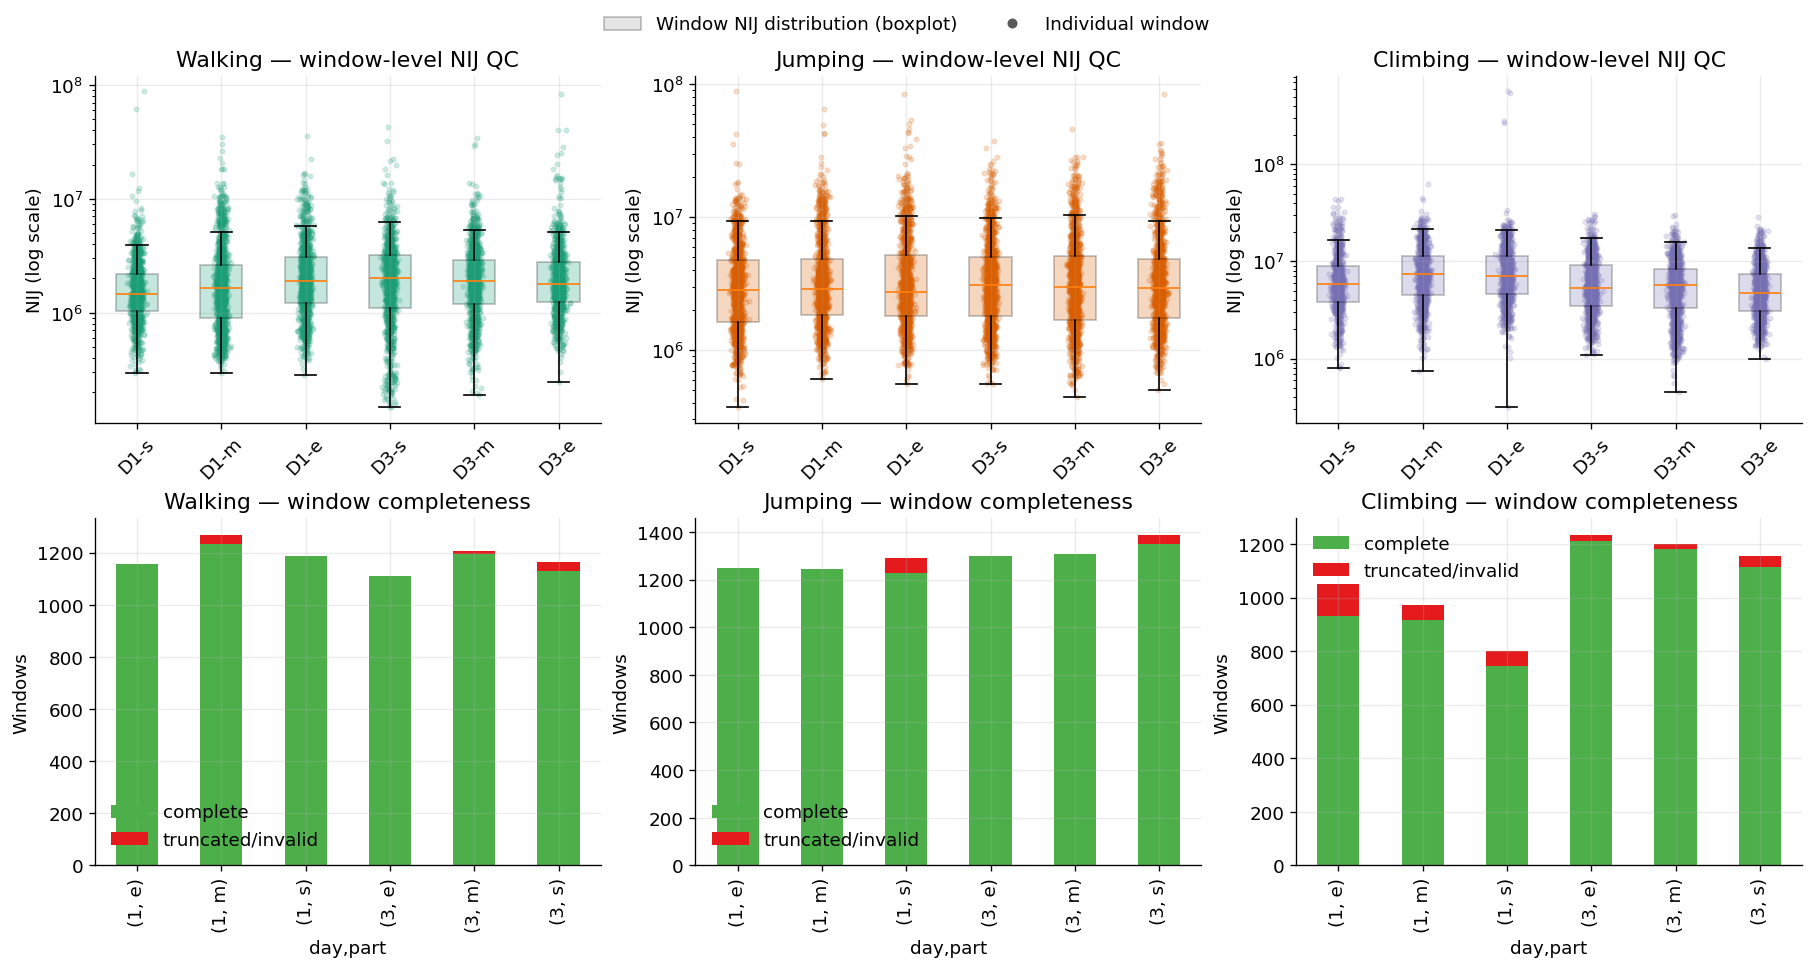

In [18]:
def plot_smoothness_qc(values, qc):
    fig, axes = plt.subplots(2, len(SKILLS), figsize=(5.0 * len(SKILLS), 8), constrained_layout=True)
    rng = np.random.default_rng(RANDOM_SEED)
    distribution_rows = []
    for column, skill in enumerate(SKILLS):
        ax = axes[0, column]; skill_df = values[(values.skill == skill) & values.nij_mean.gt(0)]
        groups, labels = [], []
        for day in DAYS:
            for part in PARTS:
                group = skill_df[(skill_df.day == day) & (skill_df.part == part)]
                if len(group): groups.append(group); labels.append(f"D{day}-{part}")
        if groups:
            box = ax.boxplot([g.nij_mean for g in groups], patch_artist=True, showfliers=False)
            for patch in box["boxes"]: patch.set_facecolor(SKILL_COLORS[skill]); patch.set_alpha(0.25)
            for index, group in enumerate(groups, 1):
                x = rng.normal(index, 0.035, len(group)); ax.scatter(x, group.nij_mean, s=7, color=SKILL_COLORS[skill], alpha=0.18)
                distribution_rows.append(group.assign(plot_x=x))
            ax.set_xticks(range(1, len(labels) + 1), labels, rotation=45)
        ax.set_yscale("log"); ax.set_title(f"{SKILL_LABELS[skill]} — window-level NIJ QC"); ax.set_ylabel("NIJ (log scale)")
        count_ax = axes[1, column]; count_df = qc[qc.skill == skill].copy()
        count_df["status"] = np.where(count_df.complete_120_frames, "complete", "truncated/invalid")
        summary = count_df.groupby(["day", "part", "status"]).size().unstack(fill_value=0)
        summary.plot.bar(ax=count_ax, stacked=True, color=["#4daf4a", "#e41a1c"]); count_ax.set_title(f"{SKILL_LABELS[skill]} — window completeness")
        count_ax.set_ylabel("Windows"); count_ax.legend(frameon=False)
    handles = [
        Patch(facecolor="0.6", edgecolor="black", alpha=0.25, label="Window NIJ distribution (boxplot)"),
        Line2D([0], [0], color="none", marker="o", markerfacecolor="0.35", markeredgecolor="none",
               label="Individual window"),
    ]
    fig.legend(handles=handles, loc="outside upper center", ncol=2, frameon=False)
    saved = save_figure(fig, OUTPUT_DIRS["smoothness"]["qc"], "smoothness_window_distributions_and_completeness_qc", pdf=False)
    plot_df = pd.concat(distribution_rows, ignore_index=True) if distribution_rows else pd.DataFrame()
    counts = values.groupby(["subject", "skill", "day", "part"], as_index=False).agg(n_windows=("nij_mean", "size"), n_finite=("nij_mean", lambda x: np.isfinite(x).sum()))
    counts.to_csv(OUTPUT_DIRS["smoothness"]["tables"] / f"{ANALYSIS_VERSION}_subject_window_counts.csv", index=False)
    values[values.extreme_value_q995].to_csv(OUTPUT_DIRS["smoothness"]["tables"] / f"{ANALYSIS_VERSION}_extreme_values_not_removed.csv", index=False)
    return fig, plot_df, counts, saved


smoothness_qc_fig, smoothness_qc_plot_df, smoothness_subject_counts_df, smoothness_qc_paths = plot_smoothness_qc(smoothness_df, smoothness_qc_df)
plt.show()

### Report-ready figures

The scatter uses one point per complete paired subject × skill: X is the subject median for Day 1 start and Y is the median for Day 3 end. Color is subject identity and the dashed X=Y line means no change. Both axes are logarithmic and equal. The change plot uses the same subject-colored point/line for each paired subject; horizontal position represents day/part. Panel titles report the number of complete pairs.

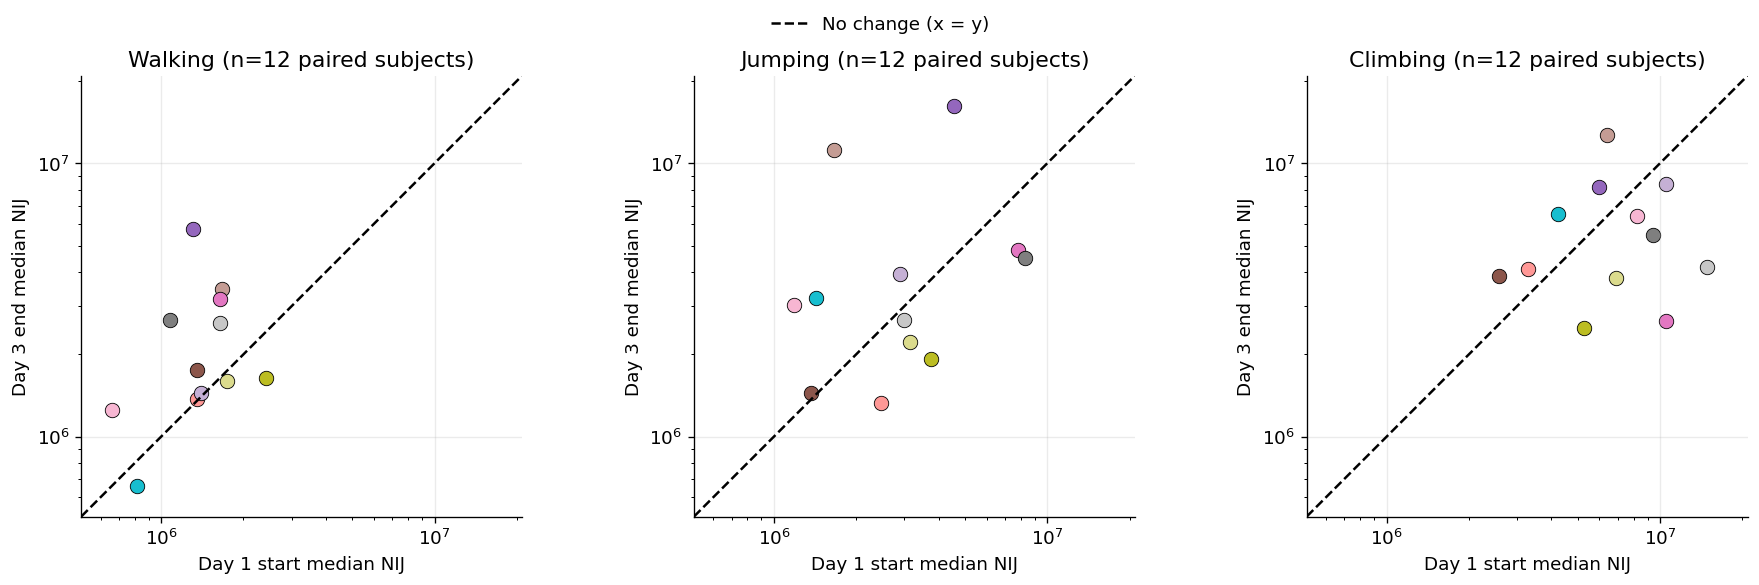

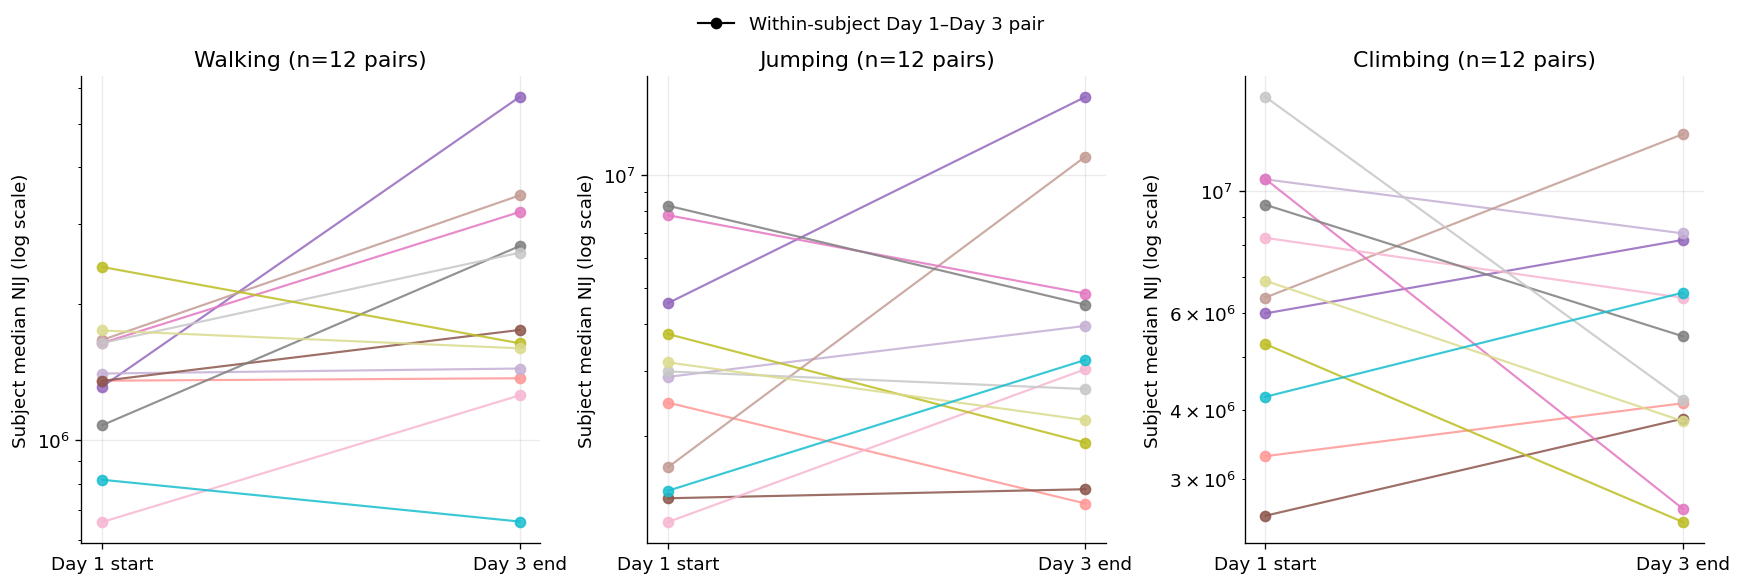

In [19]:
def build_smoothness_paired_table(values, parameters=None):
    parameters = SMOOTHNESS_PARAMS if parameters is None else parameters
    selected = values[np.isfinite(values.nij_mean) & values.nij_mean.gt(0)].copy()
    wanted = {(day, normalize_part_code(part)) for day, part in parameters["day_part_map"].items()}
    selected = selected[selected.apply(lambda row: (int(row.day), normalize_part_code(row.part)) in wanted, axis=1)]
    summary = selected.groupby(["subject", "skill", "day", "part"], as_index=False).agg(median_nij=("nij_mean", "median"), n_windows=("nij_mean", "size"))
    wide = summary.pivot_table(index=["subject", "skill"], columns="day", values="median_nij", aggfunc="first").reset_index()
    if not set(DAYS).issubset(wide.columns): return pd.DataFrame(), summary, pd.DataFrame()
    wide = wide.rename(columns={1: "day1_start_median_nij", 3: "day3_end_median_nij"})
    incomplete = wide[wide[["day1_start_median_nij", "day3_end_median_nij"]].isna().any(axis=1)].copy()
    paired = wide.dropna(subset=["day1_start_median_nij", "day3_end_median_nij"]).copy()
    return paired, summary, incomplete


def plot_smoothness_paired(values):
    paired, summary, incomplete = build_smoothness_paired_table(values)
    paired.to_csv(OUTPUT_DIRS["smoothness"]["tables"] / f"{ANALYSIS_VERSION}_paired_day1start_day3end.csv", index=False)
    incomplete.to_csv(OUTPUT_DIRS["smoothness"]["tables"] / f"{ANALYSIS_VERSION}_dropped_incomplete_pairs.csv", index=False)
    fig_scatter, scatter_axes = plt.subplots(1, len(SKILLS), figsize=(5.1 * len(SKILLS), 4.8), constrained_layout=True)
    limits = equal_limits(paired.day1_start_median_nij, paired.day3_end_median_nij, log_scale=True)
    for ax, skill in zip(scatter_axes, SKILLS):
        frame = paired[paired.skill == skill]
        for row in frame.itertuples():
            ax.scatter(row.day1_start_median_nij, row.day3_end_median_nij, s=75, color=get_subject_color(row.subject), edgecolor="black", linewidth=0.5)
        ax.set_xscale("log"); ax.set_yscale("log")
        if limits:
            ax.plot(limits, limits, "k--", label="No change (x = y)"); ax.set_xlim(limits); ax.set_ylim(limits)
        ax.set_aspect("equal", adjustable="box")
        ax.set(title=f"{SKILL_LABELS[skill]} (n={len(frame)} paired subjects)", xlabel="Day 1 start median NIJ", ylabel="Day 3 end median NIJ")
    scatter_handles = [Line2D([0], [0], color="black", linestyle="--", label="No change (x = y)")]
    fig_scatter.legend(handles=scatter_handles, loc="outside upper center", frameon=False)
    scatter_paths = save_figure(fig_scatter, OUTPUT_DIRS["smoothness"]["report"], "smoothness_paired_day1start_vs_day3end_scatter")
    fig_change, change_axes = plt.subplots(1, len(SKILLS), figsize=(4.8 * len(SKILLS), 4.8), constrained_layout=True)
    for ax, skill in zip(change_axes, SKILLS):
        frame = paired[paired.skill == skill]
        for row in frame.itertuples():
            values_pair = [row.day1_start_median_nij, row.day3_end_median_nij]; color = get_subject_color(row.subject)
            ax.plot([1, 2], values_pair, color=color, marker="o", linewidth=1.3, alpha=0.85)
        ax.set_xticks([1,2], ["Day 1 start", "Day 3 end"]); ax.set_yscale("log")
        ax.set(title=f"{SKILL_LABELS[skill]} (n={len(frame)} pairs)", ylabel="Subject median NIJ (log scale)")
    change_handles = [Line2D([0], [0], color="black", marker="o", linewidth=1.3,
                             label="Within-subject Day 1–Day 3 pair")]
    fig_change.legend(handles=change_handles, loc="outside upper center", frameon=False)
    change_paths = save_figure(fig_change, OUTPUT_DIRS["smoothness"]["report"], "smoothness_paired_subject_change")
    return paired, summary, incomplete, fig_scatter, fig_change, scatter_paths + change_paths


smoothness_paired_df, smoothness_subject_summary_df, smoothness_incomplete_pairs_df, smoothness_scatter_fig, smoothness_change_fig, smoothness_report_paths = plot_smoothness_paired(smoothness_df)
plt.show()

### Saved outputs

In [20]:
print("Smoothness outputs:")
for key, value in OUTPUT_DIRS["smoothness"].items(): print(f"  {key}: {value}")

Smoothness outputs:
  root: D:\noamgonen\GitHub\gorilla_tag_\img\labeled_data_analysis\smoothness
  cache: D:\noamgonen\GitHub\gorilla_tag_\img\labeled_data_analysis\smoothness\cache
  tables: D:\noamgonen\GitHub\gorilla_tag_\img\labeled_data_analysis\smoothness\tables
  qc: D:\noamgonen\GitHub\gorilla_tag_\img\labeled_data_analysis\smoothness\figures\qc
  report: D:\noamgonen\GitHub\gorilla_tag_\img\labeled_data_analysis\smoothness\figures\report


## 5. Movement cycle analysis

### Purpose, data, and comparison

Positive repetitive windows are unioned by exact `source_file`, short gaps are bridged, and continuous movement runs are formed. Within each run, hand Y relative to root is smoothed, peaks or troughs are detected with the existing skill/hand settings, and consecutive events define candidate cycles. Accepted cycles satisfy the existing duration and skill-specific amplitude limits and are linearly resampled to 100 normalized-time points.

For a subject × skill × day × part × hand, the **mean movement cycle** is the pointwise mean across accepted normalized cycles. RMS deviation for cycle $i$ is

$$\mathrm{RMS}_i=\sqrt{\frac{1}{K}\sum_{k=1}^{K}(y_{ik}-\bar y_k)^2},$$

and reported mean RMS deviation is the mean over cycles. Normalized RMS deviation divides it by median cycle amplitude. Median cycle duration is the median event-to-event duration in seconds. Subject-level report comparisons pair Day 1 start with Day 3 end. Overlapping positive windows are never treated as independent continuous runs.

### Parameters

In [21]:
CYCLE_PARAMS = {
    "sampling_frequency_hz": FS_HZ, "max_gap_to_bridge_frames": 15, "min_run_duration_sec": 3.0,
    "normalized_cycle_points": 100, "min_cycles_per_subject_hand": 3, "candidate_diagnostics_version": 1,
    "subjects": tuple(REPETITIVE_SUBJECTS), "skills": tuple(SKILLS), "hands": tuple(HANDS),
    "day_part_map": {1: "s", 3: "e"},
    "detection": {
        "walk": {"event_type_by_hand": {"r_hand": "peaks", "l_hand": "troughs"}, "smooth_window": 9, "smooth_polyorder": 3,
                 "prominence_sd_factor": 0.10, "min_event_distance_sec": 0.20, "min_cycle_duration_sec": 0.50,
                 "max_cycle_duration_sec": 3.10, "min_cycle_amplitude": 10},
        "jump": {"event_type_by_hand": {"r_hand": "peaks", "l_hand": "peaks"}, "smooth_window": 9, "smooth_polyorder": 3,
                 "prominence_sd_factor": 0.10, "min_event_distance_sec": 0.20, "min_cycle_duration_sec": 0.40,
                 "max_cycle_duration_sec": 1.50, "min_cycle_amplitude": None},
        "climb": {"event_type_by_hand": {"r_hand": "peaks", "l_hand": "peaks"}, "smooth_window": 9, "smooth_polyorder": 3,
                  "prominence_sd_factor": 0.10, "min_event_distance_sec": 0.20, "min_cycle_duration_sec": 0.40,
                  "max_cycle_duration_sec": 1.70, "min_cycle_amplitude": None},
    },
}
CYCLE_PARAMS

{'sampling_frequency_hz': 60.0,
 'max_gap_to_bridge_frames': 15,
 'min_run_duration_sec': 3.0,
 'normalized_cycle_points': 100,
 'min_cycles_per_subject_hand': 3,
 'candidate_diagnostics_version': 1,
 'subjects': ('002',
  '004',
  '006',
  '007',
  '008',
  '009',
  '010',
  '011',
  '012',
  '013',
  '014',
  '015'),
 'skills': ('walk', 'jump', 'climb'),
 'hands': ('r_hand', 'l_hand'),
 'day_part_map': {1: 's', 3: 'e'},
 'detection': {'walk': {'event_type_by_hand': {'r_hand': 'peaks',
    'l_hand': 'troughs'},
   'smooth_window': 9,
   'smooth_polyorder': 3,
   'prominence_sd_factor': 0.1,
   'min_event_distance_sec': 0.2,
   'min_cycle_duration_sec': 0.5,
   'max_cycle_duration_sec': 3.1,
   'min_cycle_amplitude': 10},
  'jump': {'event_type_by_hand': {'r_hand': 'peaks', 'l_hand': 'peaks'},
   'smooth_window': 9,
   'smooth_polyorder': 3,
   'prominence_sd_factor': 0.1,
   'min_event_distance_sec': 0.2,
   'min_cycle_duration_sec': 0.4,
   'max_cycle_duration_sec': 1.5,
   'min_cycl

### Load or compute results

In [22]:
def compute_hand_y_relative_to_root(frame, hand):
    required = [f"{hand}.y", "root.y"]
    missing = [column for column in required if column not in frame]
    if missing: raise ValueError(f"Missing columns: {missing}")
    return (pd.to_numeric(frame[required[0]], errors="coerce") - pd.to_numeric(frame[required[1]], errors="coerce")).to_numpy(dtype=float)


def smooth_signal(values, window_length, polyorder):
    values = np.asarray(values, dtype=float)
    if len(values) < 5: return values.copy()
    window_length = int(window_length) + (int(window_length) % 2 == 0)
    maximum = len(values) if len(values) % 2 else len(values) - 1
    window_length = min(window_length, maximum)
    if window_length <= polyorder or window_length < 5: return values.copy()
    return savgol_filter(values, window_length, polyorder)


def extract_cycles_from_signal(raw, skill, hand, parameters):
    config = parameters["detection"][skill]; fps = parameters["sampling_frequency_hz"]
    smooth = smooth_signal(raw, config["smooth_window"], config["smooth_polyorder"])
    event_type = config["event_type_by_hand"][hand]
    prominence = config["prominence_sd_factor"] * np.nanstd(smooth)
    distance = max(1, round(config["min_event_distance_sec"] * fps))
    events, _ = find_peaks(smooth if event_type == "peaks" else -smooth, distance=distance, prominence=prominence)
    rejected = {"too_short": 0, "too_long": 0, "nan": 0, "low_amplitude": 0, "resample_failed": 0}
    cycles, candidates = [], []
    for cycle_id, (start, end) in enumerate(zip(events[:-1], events[1:]), 1):
        frames = int(end - start); duration = frames / fps
        candidate = {"cycle_id_in_run": cycle_id, "start_idx_in_run": int(start), "end_idx_in_run": int(end),
                     "duration_frames": frames, "duration_sec": duration, "rejection_reason": "accepted"}
        if duration < config["min_cycle_duration_sec"]:
            rejected["too_short"] += 1; candidate["rejection_reason"] = "too_short"; candidates.append(candidate); continue
        if duration > config["max_cycle_duration_sec"]:
            rejected["too_long"] += 1; candidate["rejection_reason"] = "too_long"; candidates.append(candidate); continue
        raw_cycle, smooth_cycle = raw[start:end + 1], smooth[start:end + 1]
        if not np.isfinite(smooth_cycle).all():
            rejected["nan"] += 1; candidate["rejection_reason"] = "nan"; candidates.append(candidate); continue
        amplitude = float(np.ptp(smooth_cycle))
        candidate["amplitude"] = amplitude
        if config["min_cycle_amplitude"] is not None and amplitude < config["min_cycle_amplitude"]:
            rejected["low_amplitude"] += 1; candidate["rejection_reason"] = "low_amplitude"; candidates.append(candidate); continue
        normalized = np.interp(np.linspace(0, 1, parameters["normalized_cycle_points"]), np.linspace(0, 1, len(smooth_cycle)), smooth_cycle)
        if not np.isfinite(normalized).all():
            rejected["resample_failed"] += 1; candidate["rejection_reason"] = "resample_failed"; candidates.append(candidate); continue
        candidates.append(candidate)
        cycles.append({"cycle_id_in_run": cycle_id, "start_idx_in_run": int(start), "end_idx_in_run": int(end),
                       "duration_frames": frames, "duration_sec": duration, "amplitude": amplitude,
                       "event_type": event_type, "y_cycle_raw": raw_cycle, "y_cycle_smooth": smooth_cycle, "y_cycle_norm": normalized})
    return cycles, candidates, smooth, events, prominence, rejected


def extract_cycles_from_runs(runs, parameters):
    cycles, candidates, diagnostics, skipped = [], [], [], []
    file_cache = {}
    for run in runs.itertuples():
        try:
            frame = load_position_file(run.path, file_cache).iloc[run.run_start:run.run_end].copy()
        except Exception as exc:
            skipped.append({"subject": run.subject, "skill": run.skill, "day": run.day, "part": run.part, "file": run.file, "error": str(exc)}); continue
        for hand in parameters["hands"]:
            try:
                raw = compute_hand_y_relative_to_root(frame, hand)
                extracted, candidate_records, smooth, events, prominence, rejected = extract_cycles_from_signal(raw, run.skill, hand, parameters)
                error = ""
            except Exception as exc:
                extracted, candidate_records, smooth, events, prominence, rejected = [], [], np.array([]), np.array([]), np.nan, {}
                error = str(exc); skipped.append({"subject": run.subject, "skill": run.skill, "day": run.day, "part": run.part, "file": run.file, "hand": hand, "error": error})
            diagnostic = {"subject": run.subject, "day": run.day, "part": run.part, "skill": run.skill, "file": run.file,
                          "movement_run_id": run.movement_run_id, "hand": hand, "n_events": len(events), "n_cycles": len(extracted),
                          "candidate_cycles": max(0, len(events)-1), "used_prominence": prominence, "error": error,
                          **{f"rejected_{key}": value for key, value in rejected.items()}}
            diagnostics.append(diagnostic)
            for candidate in candidate_records:
                candidates.append({"subject": run.subject, "day": int(run.day), "part": run.part, "skill": run.skill, "file": run.file,
                                   "movement_run_id": int(run.movement_run_id), "hand": hand, **candidate})
            for cycle in extracted:
                cycles.append({"subject": run.subject, "day": int(run.day), "part": run.part, "skill": run.skill, "file": run.file,
                               "path": run.path, "movement_run_id": int(run.movement_run_id), "run_start": int(run.run_start),
                               "run_end": int(run.run_end), "hand": hand,
                               "start_idx_in_file": int(run.run_start + cycle["start_idx_in_run"]),
                               "end_idx_in_file": int(run.run_start + cycle["end_idx_in_run"]), **cycle})
    return pd.DataFrame(cycles), pd.DataFrame(candidates), pd.DataFrame(diagnostics), pd.DataFrame(skipped)


def summarize_subject_cycles(cycles, parameters):
    summaries, means = [], []
    if cycles.empty: return pd.DataFrame(), pd.DataFrame()
    for keys, group in cycles.groupby(["subject", "day", "skill", "part", "hand"]):
        if len(group) < parameters["min_cycles_per_subject_hand"]: continue
        matrix = np.vstack(group.y_cycle_norm); mean = np.nanmean(matrix, axis=0)
        sd = np.nanstd(matrix, axis=0, ddof=1) if len(matrix) > 1 else np.zeros(matrix.shape[1])
        rms_per_cycle = np.sqrt(np.nanmean((matrix - mean) ** 2, axis=1)); mean_rms = float(np.nanmean(rms_per_cycle))
        median_amplitude = float(group.amplitude.median())
        base = dict(zip(["subject", "day", "skill", "part", "hand"], keys))
        summaries.append({**base, "n_cycles": len(group), "n_movement_runs_with_cycles": group.movement_run_id.nunique(),
                          "median_duration_sec": float(group.duration_sec.median()), "mean_duration_sec": float(group.duration_sec.mean()),
                          "median_amplitude": median_amplitude, "mean_amplitude": float(group.amplitude.mean()),
                          "mean_rms_deviation": mean_rms,
                          "normalized_rms_deviation": mean_rms / median_amplitude if median_amplitude > 1e-9 else np.nan})
        means.append({**base, "n_cycles": len(group), "mean_cycle": mean, "sd_cycle": sd,
                      "sem_cycle": sd / np.sqrt(len(group)), "normalized_time": np.linspace(0, 100, matrix.shape[1])})
    return pd.DataFrame(summaries), pd.DataFrame(means)


def expected_cycle_grid(parameters):
    return pd.DataFrame([{"subject": subject, "skill": skill, "day": day, "part": normalize_part_code(part), "hand": hand}
                         for subject in parameters["subjects"] for skill in parameters["skills"]
                         for day, part in parameters["day_part_map"].items() for hand in parameters["hands"]])


def missing_cycle_report(cycles, means, parameters):
    grid = expected_cycle_grid(parameters)
    counts = cycles.groupby(["subject", "skill", "day", "part", "hand"]).size().reset_index(name="raw_n_cycles") if len(cycles) else grid.iloc[:0].assign(raw_n_cycles=pd.Series(dtype=int))
    present = means[["subject", "skill", "day", "part", "hand", "n_cycles"]] if len(means) else grid.iloc[:0].assign(n_cycles=pd.Series(dtype=float))
    report = grid.merge(counts, how="left").merge(present, how="left"); report.raw_n_cycles = report.raw_n_cycles.fillna(0).astype(int)
    report["has_subject_mean_cycle"] = report.n_cycles.notna()
    report["missing_reason"] = np.where(report.has_subject_mean_cycle, "has_mean_cycle",
                                        np.where(report.raw_n_cycles.eq(0), "no_cycles_extracted", "fewer_than_min_cycles"))
    return report


def cycle_delta_table(summary, parameters):
    ids = ["subject", "skill", "hand"]
    metrics = ["normalized_rms_deviation", "mean_rms_deviation", "median_duration_sec", "median_amplitude", "n_cycles"]
    frames = []
    for day, part in parameters["day_part_map"].items():
        frame = summary[(summary.day.astype(int) == day) & (summary.part.map(normalize_part_code) == normalize_part_code(part))][ids + metrics].copy()
        frames.append(frame.rename(columns={metric: f"{metric}_day{day}_{normalize_part_code(part)}" for metric in metrics}))
    wide = frames[0].merge(frames[1], on=ids, how="outer")
    for metric in metrics:
        left, right = f"{metric}_day1_s", f"{metric}_day3_e"
        wide[f"delta_{metric}_day3minusday1"] = wide[right] - wide[left]
    return wide


def compute_cycle_analysis(rep_df, parameters):
    runs, run_qc, run_skipped = build_runs_from_positive_windows(rep_df, parameters)
    cycles, candidates, diagnostics, cycle_skipped = extract_cycles_from_runs(runs, parameters)
    summary, means = summarize_subject_cycles(cycles, parameters)
    missing = missing_cycle_report(cycles, means, parameters)
    deltas = cycle_delta_table(summary, parameters)
    skipped = pd.concat([run_skipped, cycle_skipped], ignore_index=True, sort=False)
    return {"runs": runs, "run_qc": run_qc, "cycles": cycles, "candidates": candidates, "diagnostics": diagnostics, "subject_summary": summary,
            "subject_means": means, "missing": missing, "deltas": deltas, "skipped": skipped}


def save_cycle_outputs(result, out):
    array_columns = ["y_cycle_raw", "y_cycle_smooth", "y_cycle_norm"]
    metadata = result["cycles"].drop(columns=array_columns, errors="ignore")
    metadata.to_csv(out["tables"] / f"{ANALYSIS_VERSION}_cycle_metadata.csv", index=False)
    for key in ["runs", "run_qc", "candidates", "diagnostics", "subject_summary", "missing", "deltas", "skipped"]:
        result[key].to_csv(out["tables"] / f"{ANALYSIS_VERSION}_{key}.csv", index=False)
    cycle_arrays = np.vstack(result["cycles"].y_cycle_norm) if len(result["cycles"]) else np.empty((0, CYCLE_PARAMS["normalized_cycle_points"]))
    mean_arrays = np.vstack(result["subject_means"].mean_cycle) if len(result["subject_means"]) else np.empty((0, CYCLE_PARAMS["normalized_cycle_points"]))
    atomic_npz(out["cache"] / f"{ANALYSIS_VERSION}_normalized_cycle_arrays.npz", normalized_cycles=cycle_arrays, subject_mean_cycles=mean_arrays)


def load_or_build_cycles(rep_df, parameters=None):
    parameters = CYCLE_PARAMS if parameters is None else parameters
    out = OUTPUT_DIRS["cycles"]; cache = out["cache"] / f"{ANALYSIS_VERSION}_cycle_bundle.pkl"
    manifest = out["cache"] / f"{ANALYSIS_VERSION}_manifest.json"
    selected = rep_df[rep_df.subject_str.isin([normalize_repetitive_subject(subject) for subject in parameters["subjects"]])]
    inputs = [*REPETITIVE_WINDOW_FILES.values(), *referenced_position_paths(selected, "repetitive")]
    signature, payload = cache_signature("cycles", parameters, inputs)
    if not FORCE_RECOMPUTE["cycles"] and cache.exists() and cache_is_valid(manifest, signature):
        print(f"Loaded cycle cache: {cache}"); return pd.read_pickle(cache)
    result = compute_cycle_analysis(rep_df, parameters); atomic_pickle_dump(result, cache); save_cycle_outputs(result, out)
    write_manifest(manifest, "cycles", signature, payload, [cache, out["cache"] / f"{ANALYSIS_VERSION}_normalized_cycle_arrays.npz"])
    print(f"Computed cycle cache: {cache}"); return result


cycle_results = load_or_build_cycles(repetitive_labeled_df)
runs_df = cycle_results["runs"]; run_qc_df = cycle_results["run_qc"]; cycles_df = cycle_results["cycles"]; candidate_cycles_df = cycle_results["candidates"]
cycle_diagnostics_df = cycle_results["diagnostics"]; subject_cycle_summary_df = cycle_results["subject_summary"]
subject_mean_cycles_df = cycle_results["subject_means"]; missing_mean_cycle_report_df = cycle_results["missing"]
subject_cycle_delta_df = cycle_results["deltas"]
display(subject_cycle_summary_df.head())
display(missing_mean_cycle_report_df.groupby(["skill", "day", "part", "hand", "missing_reason"]).size().reset_index(name="n_conditions"))

Loaded cycle cache: D:\noamgonen\GitHub\gorilla_tag_\img\labeled_data_analysis\cycles\cache\labeled_data_v2_cycle_bundle.pkl


,subject,day,skill,part,hand,n_cycles,n_movement_runs_with_cycles,median_duration_sec,mean_duration_sec,median_amplitude,mean_amplitude,mean_rms_deviation,normalized_rms_deviation
0,002,1,climb,s,l_hand,100,11,0.991667,1.022500,54.140255,49.044291,10.662964,0.196951
1,002,1,climb,s,r_hand,103,11,1.000000,1.048706,50.980368,51.703214,9.177516,0.180021
2,002,1,jump,s,l_hand,92,15,0.933333,0.899094,51.462827,52.236758,6.884342,0.133773
3,002,1,jump,s,r_hand,89,15,0.916667,0.915918,65.759534,65.619974,6.094471,0.092678
4,002,1,walk,s,l_hand,96,11,1.016667,1.010938,46.240092,47.100998,5.346004,0.115614


,skill,day,part,hand,missing_reason,n_conditions
0,climb,1,s,l_hand,has_mean_cycle,12
1,climb,1,s,r_hand,has_mean_cycle,12
2,climb,3,e,l_hand,has_mean_cycle,12
3,climb,3,e,r_hand,has_mean_cycle,12
4,jump,1,s,l_hand,has_mean_cycle,12
5,jump,1,s,r_hand,has_mean_cycle,12
6,jump,3,e,l_hand,has_mean_cycle,12
7,jump,3,e,r_hand,has_mean_cycle,12
8,walk,1,s,l_hand,has_mean_cycle,12
9,walk,1,s,r_hand,has_mean_cycle,12


### Quality-control outputs

Coverage panels summarize positive-window unions and merged runs. Detection panels distinguish candidate, accepted, and rejected cycles. The candidate-duration histograms include every detected candidate and identify accepted cycles and each rejection reason; dashed lines mark the skill-specific minimum and maximum duration thresholds. Duration/amplitude points are accepted cycles (not independent participants). Representative signal panels show one raw/smoothed run with detected events. The next panel shows accepted cycles on their original time scale, before temporal normalization, and the final panel shows the same cycles normalized to 100 points together with their mean. Missing-condition tables explicitly warn when fewer than three cycles prevent a subject mean.

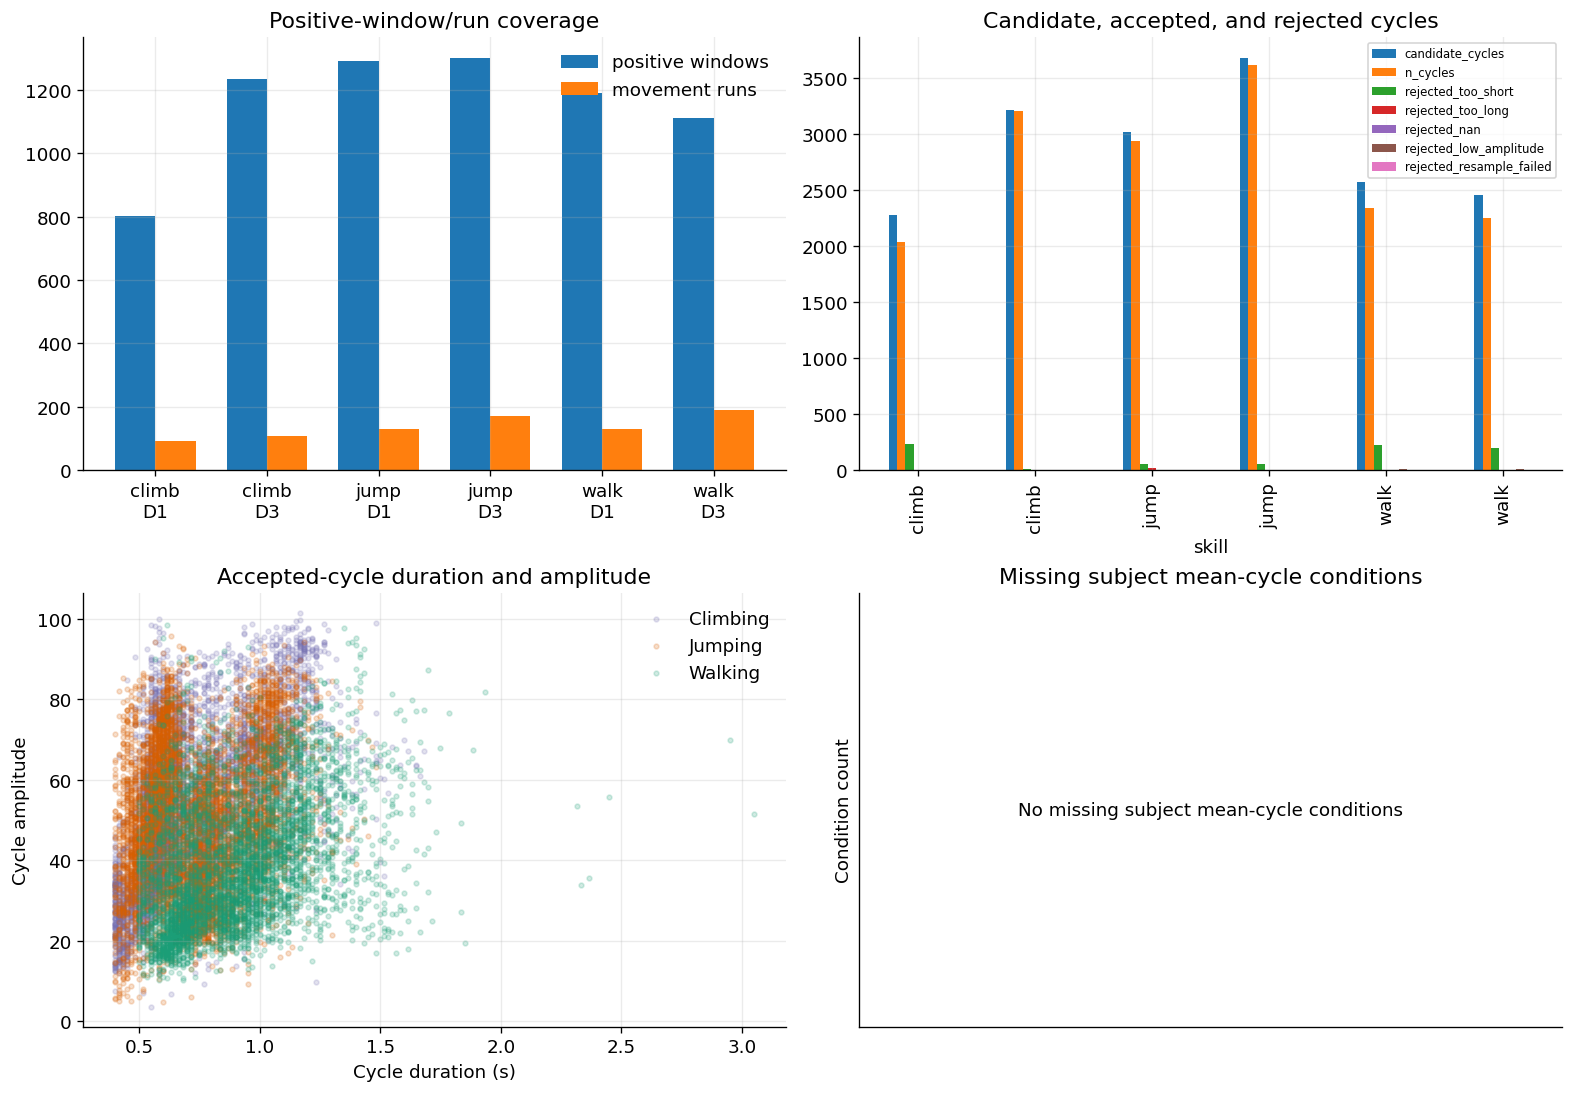

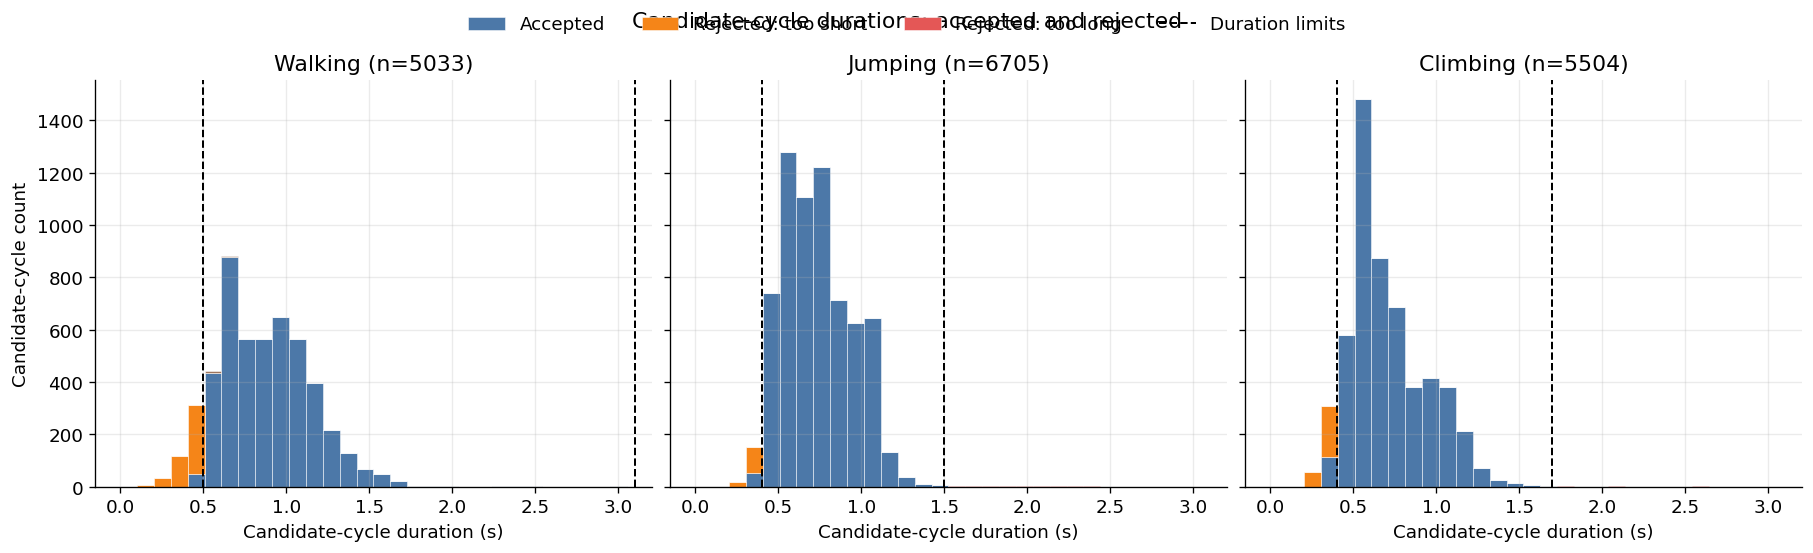

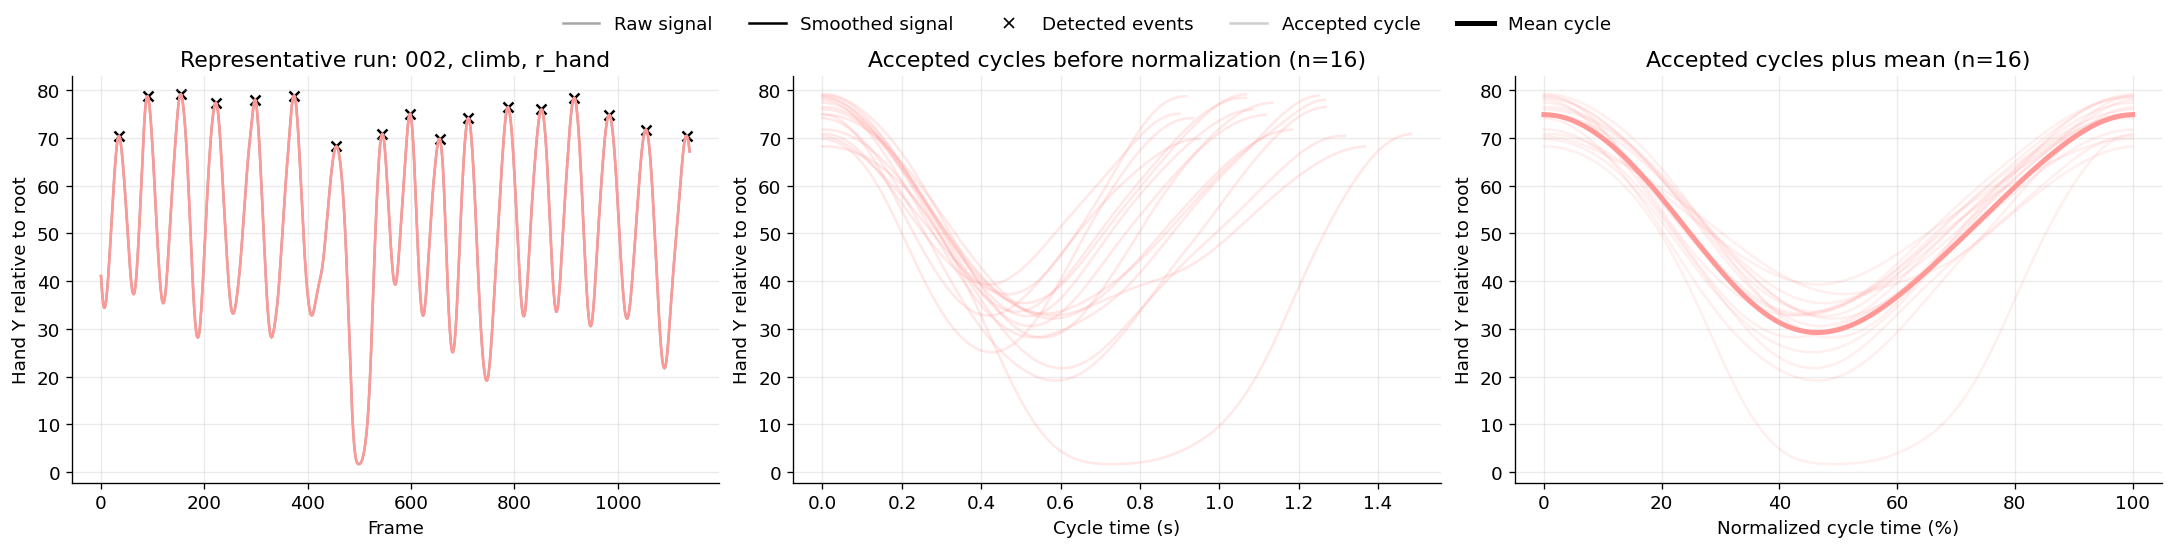

In [23]:
def plot_cycle_qc(result):
    runs = result["runs"]
    run_qc = result["run_qc"]
    diagnostics = result["diagnostics"]
    cycles = result["cycles"]
    missing = result["missing"]

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(13, 9),
        constrained_layout=True,
    )

    # Positive-window and movement-run coverage
    coverage = (
        run_qc.groupby(["skill", "day"], as_index=False)
        .agg(
            positive_windows=("n_positive_windows", "sum"),
            movement_runs=("n_movement_runs", "sum"),
        )
    )

    x = np.arange(len(coverage))
    axes[0, 0].bar(
        x - 0.18,
        coverage.positive_windows,
        0.36,
        label="positive windows",
    )
    axes[0, 0].bar(
        x + 0.18,
        coverage.movement_runs,
        0.36,
        label="movement runs",
    )
    axes[0, 0].set_xticks(
        x,
        [
            f"{skill}\nD{day}"
            for skill, day in coverage[["skill", "day"]].itertuples(index=False)
        ],
    )
    axes[0, 0].set_title("Positive-window/run coverage")
    axes[0, 0].legend(frameon=False)

    # Candidate, accepted, and rejected cycles
    rejection_columns = [
        column
        for column in diagnostics.columns
        if column.startswith("rejected_")
    ]

    detection_columns = [
        "candidate_cycles",
        "n_cycles",
        *rejection_columns,
    ]

    detection = (
        diagnostics.groupby(["skill", "day"])[detection_columns]
        .sum()
        .reset_index()
    )

    detection.plot(
        x="skill",
        y=detection_columns,
        kind="bar",
        ax=axes[0, 1],
    )
    axes[0, 1].set_title("Candidate, accepted, and rejected cycles")
    axes[0, 1].legend(fontsize=7)

    # Accepted-cycle duration and amplitude
    if not cycles.empty:
        for skill, frame in cycles.groupby("skill"):
            axes[1, 0].scatter(
                frame.duration_sec,
                frame.amplitude,
                s=8,
                alpha=0.2,
                color=SKILL_COLORS[skill],
                label=SKILL_LABELS[skill],
            )

        axes[1, 0].legend(frameon=False)
    else:
        axes[1, 0].text(
            0.5,
            0.5,
            "No accepted cycles",
            ha="center",
            va="center",
            transform=axes[1, 0].transAxes,
        )

    axes[1, 0].set(
        xlabel="Cycle duration (s)",
        ylabel="Cycle amplitude",
        title="Accepted-cycle duration and amplitude",
    )

    # Conditions without a valid subject mean cycle
    missing_conditions = missing.loc[
        ~missing["has_subject_mean_cycle"]
    ].copy()

    missing_summary = (
        missing_conditions.groupby(["skill", "missing_reason"])
        .size()
        .unstack(fill_value=0)
    )

    missing_ax = axes[1, 1]

    if missing_summary.empty:
        missing_ax.text(
            0.5,
            0.5,
            "No missing subject mean-cycle conditions",
            ha="center",
            va="center",
            transform=missing_ax.transAxes,
        )
        missing_ax.set_xticks([])
        missing_ax.set_yticks([])
    else:
        missing_summary.plot.bar(
            stacked=True,
            ax=missing_ax,
        )

    missing_ax.set_title("Missing subject mean-cycle conditions")
    missing_ax.set_ylabel("Condition count")

    saved = save_figure(
        fig,
        OUTPUT_DIRS["cycles"]["qc"],
        "cycle_coverage_detection_missing_qc",
        pdf=False,
    )

    plot_tables = {
        "coverage": coverage,
        "detection": detection,
        "missing": missing_summary.reset_index(),
    }

    return fig, plot_tables, saved


def plot_candidate_duration_histograms(result):
    candidates = result["candidates"]
    skills = list(CYCLE_PARAMS["skills"])

    fig, axes = plt.subplots(
        1,
        len(skills),
        figsize=(15, 4.5),
        sharey=True,
        constrained_layout=True,
    )
    axes = np.atleast_1d(axes)

    reason_order = [
        "accepted",
        "too_short",
        "too_long",
        "nan",
        "low_amplitude",
        "resample_failed",
    ]

    reason_labels = {
        "accepted": "Accepted",
        "too_short": "Rejected: too short",
        "too_long": "Rejected: too long",
        "nan": "Rejected: NaN",
        "low_amplitude": "Rejected: low amplitude",
        "resample_failed": "Rejected: resampling failed",
    }

    reason_colors = {
        "accepted": "#4C78A8",
        "too_short": "#F58518",
        "too_long": "#E45756",
        "nan": "#B279A2",
        "low_amplitude": "#9D755D",
        "resample_failed": "#FF9DA6",
    }

    if candidates.empty:
        for ax, skill in zip(axes, skills):
            ax.text(
                0.5,
                0.5,
                "No candidate cycles",
                ha="center",
                va="center",
                transform=ax.transAxes,
            )
            ax.set_title(SKILL_LABELS[skill])
            ax.set_xlabel("Candidate-cycle duration (s)")

        axes[0].set_ylabel("Candidate-cycle count")
        fig.suptitle("Candidate-cycle durations: accepted and rejected")

        saved = save_figure(
            fig,
            OUTPUT_DIRS["cycles"]["qc"],
            "candidate_cycle_duration_histograms_qc",
            pdf=False,
        )

        return fig, candidates.copy(), saved

    finite_duration = candidates.loc[
        np.isfinite(candidates["duration_sec"])
    ].copy()

    if finite_duration.empty:
        for ax, skill in zip(axes, skills):
            ax.text(
                0.5,
                0.5,
                "No finite candidate-cycle durations",
                ha="center",
                va="center",
                transform=ax.transAxes,
            )
            ax.set_title(SKILL_LABELS[skill])
            ax.set_xlabel("Candidate-cycle duration (s)")

        axes[0].set_ylabel("Candidate-cycle count")
        fig.suptitle("Candidate-cycle durations: accepted and rejected")

        saved = save_figure(
            fig,
            OUTPUT_DIRS["cycles"]["qc"],
            "candidate_cycle_duration_histograms_qc",
            pdf=False,
        )

        return fig, candidates.copy(), saved

    upper = max(
        0.5,
        float(finite_duration["duration_sec"].max()),
    )
    bins = np.linspace(0, upper, 31)

    for ax, skill in zip(axes, skills):
        frame = finite_duration.loc[
            finite_duration["skill"] == skill
        ]

        present = [
            reason
            for reason in reason_order
            if (frame["rejection_reason"] == reason).any()
        ]

        values = [
            frame.loc[
                frame["rejection_reason"] == reason,
                "duration_sec",
            ]
            for reason in present
        ]

        if values:
            ax.hist(
                values,
                bins=bins,
                stacked=True,
                color=[reason_colors[reason] for reason in present],
                label=[reason_labels[reason] for reason in present],
                edgecolor="white",
                linewidth=0.3,
            )

        config = CYCLE_PARAMS["detection"][skill]

        ax.axvline(
            config["min_cycle_duration_sec"],
            color="black",
            linestyle="--",
            linewidth=1.2,
            label="Duration limits",
        )
        ax.axvline(
            config["max_cycle_duration_sec"],
            color="black",
            linestyle="--",
            linewidth=1.2,
        )

        ax.set(
            title=f"{SKILL_LABELS[skill]} (n={len(frame)})",
            xlabel="Candidate-cycle duration (s)",
        )

    axes[0].set_ylabel("Candidate-cycle count")

    handles, labels = axes[-1].get_legend_handles_labels()
    if handles:
        fig.legend(
            handles,
            labels,
            loc="outside upper center",
            ncol=4,
            frameon=False,
        )

    fig.suptitle("Candidate-cycle durations: accepted and rejected")

    saved = save_figure(
        fig,
        OUTPUT_DIRS["cycles"]["qc"],
        "candidate_cycle_duration_histograms_qc",
        pdf=False,
    )

    return fig, candidates.copy(), saved


def plot_representative_cycle_qc(result):
    cycles = result["cycles"]

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(18, 4.5),
        constrained_layout=True,
    )

    if cycles.empty:
        for ax in axes:
            ax.text(
                0.5,
                0.5,
                "No accepted cycles",
                ha="center",
                va="center",
                transform=ax.transAxes,
            )
            ax.set_xticks([])
            ax.set_yticks([])

        fig.suptitle("Representative signal, events, and cycles")

        saved = save_figure(
            fig,
            OUTPUT_DIRS["cycles"]["qc"],
            "representative_signal_events_and_cycles_qc",
            pdf=False,
        )

        return fig, pd.DataFrame(), saved

    first = cycles.iloc[0]

    same_run = cycles.loc[
        (cycles["file"] == first["file"])
        & (cycles["movement_run_id"] == first["movement_run_id"])
        & (cycles["hand"] == first["hand"])
    ].copy()

    frame = load_position_file(first["path"]).iloc[
        int(first["run_start"]):int(first["run_end"])
    ]

    raw = compute_hand_y_relative_to_root(
        frame,
        first["hand"],
    )

    config = CYCLE_PARAMS["detection"][first["skill"]]

    smooth = smooth_signal(
        raw,
        config["smooth_window"],
        config["smooth_polyorder"],
    )

    event_signal = (
        smooth
        if first["event_type"] == "peaks"
        else -smooth
    )

    events, _ = find_peaks(
        event_signal,
        distance=round(
            config["min_event_distance_sec"] * FS_HZ
        ),
        prominence=(
            config["prominence_sd_factor"]
            * np.nanstd(smooth)
        ),
    )

    subject_color = get_subject_color(first["subject"])

    axes[0].plot(
        raw,
        color="0.65",
        label="raw",
    )
    axes[0].plot(
        smooth,
        color=subject_color,
        label="smoothed",
    )
    axes[0].scatter(
        events,
        smooth[events],
        marker="x",
        color="black",
        label="events",
    )
    axes[0].set(
        title=(
            f"Representative run: {first['subject']}, "
            f"{first['skill']}, {first['hand']}"
        ),
        xlabel="Frame",
        ylabel="Hand Y relative to root",
    )
    for curve in same_run["y_cycle_smooth"]:
        cycle_time_sec = np.arange(len(curve)) / FS_HZ
        axes[1].plot(
            cycle_time_sec,
            curve,
            color=subject_color,
            alpha=0.22,
        )

    axes[1].set(
        title=(
            "Accepted cycles before normalization "
            f"(n={len(same_run)})"
        ),
        xlabel="Cycle time (s)",
        ylabel="Hand Y relative to root",
    )

    matrix = np.vstack(
        same_run["y_cycle_norm"].to_numpy()
    )
    normalized_time = np.linspace(
        0,
        100,
        matrix.shape[1],
    )

    for curve in matrix:
        axes[2].plot(
            normalized_time,
            curve,
            color=subject_color,
            alpha=0.15,
        )

    axes[2].plot(
        normalized_time,
        np.mean(matrix, axis=0),
        color=subject_color,
        linewidth=3,
        label="mean",
    )
    axes[2].set(
        title=f"Accepted cycles plus mean (n={len(matrix)})",
        xlabel="Normalized cycle time (%)",
        ylabel="Hand Y relative to root",
    )
    representative_handles = [
        Line2D([0], [0], color="0.65", label="Raw signal"),
        Line2D([0], [0], color="black", label="Smoothed signal"),
        Line2D([0], [0], color="black", marker="x", linestyle="None", label="Detected events"),
        Line2D([0], [0], color="0.45", alpha=0.35, label="Accepted cycle"),
        Line2D([0], [0], color="black", linewidth=3, label="Mean cycle"),
    ]
    fig.legend(handles=representative_handles, loc="outside upper center", ncol=5, frameon=False)

    saved = save_figure(
        fig,
        OUTPUT_DIRS["cycles"]["qc"],
        "representative_signal_events_and_cycles_qc",
        pdf=False,
    )

    plot_data = same_run.drop(
        columns=[
            "y_cycle_raw",
            "y_cycle_smooth",
            "y_cycle_norm",
        ],
        errors="ignore",
    )

    return fig, plot_data, saved


cycle_qc_fig, cycle_qc_plot_tables, cycle_qc_paths = plot_cycle_qc(
    cycle_results
)
plt.show()

candidate_duration_fig, candidate_duration_plot_df, candidate_duration_paths = (
    plot_candidate_duration_histograms(cycle_results)
)
plt.show()

cycle_example_qc_fig, cycle_example_plot_df, cycle_example_qc_paths = (
    plot_representative_cycle_qc(cycle_results)
)
plt.show()

### Report-ready figures

Mean-cycle curves are subject-level means before group aggregation. In the aggregate-only group curves, color represents hand and line style represents day because no individual subject identity remains; shading is ±1 SD across subject means. Single-subject curves use that subject's configured color, with hand/day shown by marker and line style.

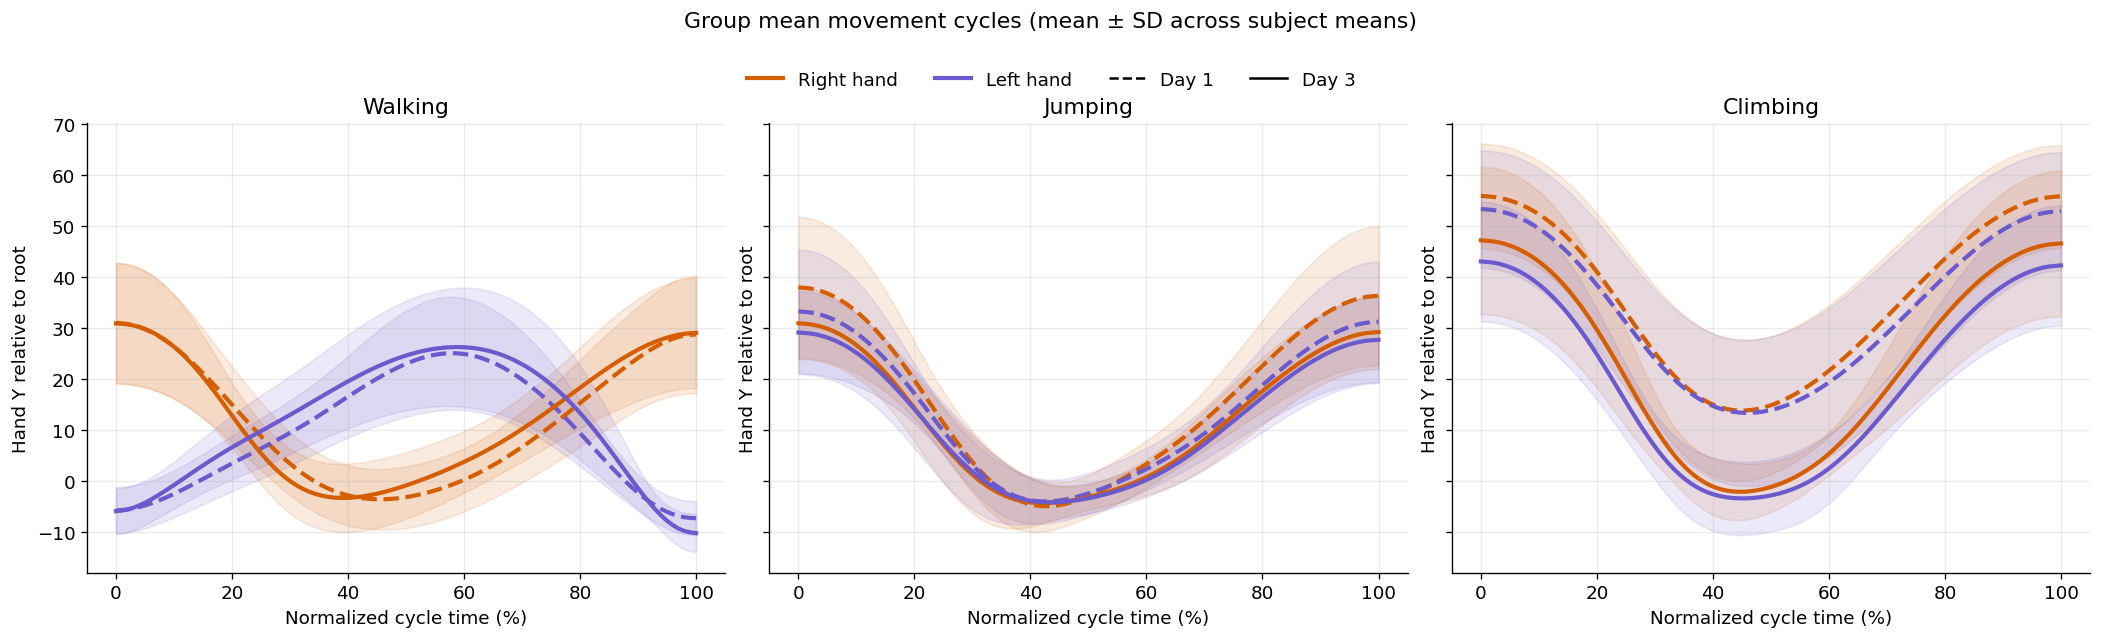

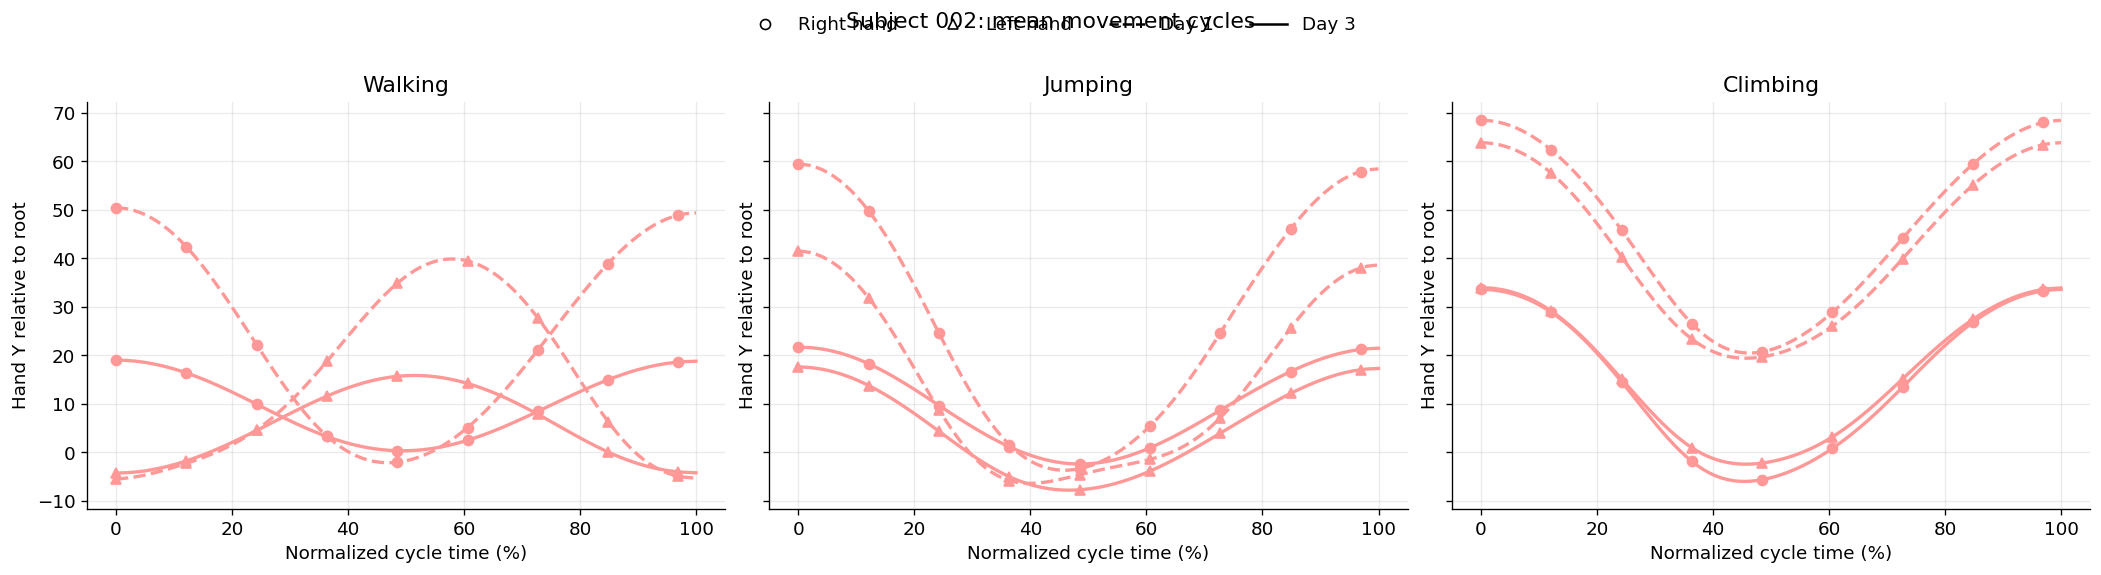

In [24]:
def condition_mean_matrix(means, skill, hand, day, part, subject=None):
    frame = means[(means.skill == skill) & (means.hand == hand) & (means.day.astype(int) == int(day)) &
                  (means.part.map(normalize_part_code) == normalize_part_code(part))].copy()
    if subject is not None: frame = frame[frame.subject.astype(str) == normalize_repetitive_subject(subject)]
    if frame.empty: return frame, None
    return frame, np.vstack(frame.mean_cycle)


def plot_group_mean_cycles(means):
    fig, axes = plt.subplots(1, len(SKILLS), figsize=(5.8 * len(SKILLS), 4.5), sharey=True, constrained_layout=True)
    for ax, skill in zip(axes, SKILLS):
        for day, part in DAY_PART_FOR_FINAL.items():
            for hand in HANDS:
                frame, matrix = condition_mean_matrix(means, skill, hand, day, part)
                if matrix is None: continue
                time = np.asarray(frame.iloc[0].normalized_time); mean = matrix.mean(axis=0); sd = matrix.std(axis=0, ddof=1) if len(matrix)>1 else np.zeros(matrix.shape[1])
                ax.plot(time, mean, color=HAND_COLORS[hand], linestyle=DAY_LINESTYLES[day], linewidth=2.5,
                        label=f"{HAND_LABELS[hand]}, Day {day} (n={len(frame)})")
                ax.fill_between(time, mean-sd, mean+sd, color=HAND_COLORS[hand], alpha=0.12)
        ax.set(title=SKILL_LABELS[skill], xlabel="Normalized cycle time (%)", ylabel="Hand Y relative to root")
    handles = [Line2D([0],[0], color=HAND_COLORS[h], label=HAND_LABELS[h], linewidth=2.5) for h in HANDS]
    handles += [Line2D([0],[0], color="black", linestyle=DAY_LINESTYLES[d], label=f"Day {d}") for d in DAYS]
    fig.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, 1.07), ncol=4, frameon=False)
    fig.suptitle("Group mean movement cycles (mean ± SD across subject means)", y=1.15)
    saved = save_figure(fig, OUTPUT_DIRS["cycles"]["report"], "group_mean_cycles_all_skills_hands_days")
    return fig, means.copy(), saved


def plot_single_subject_cycles(means, subject="002"):
    subject = normalize_repetitive_subject(subject); color = get_subject_color(subject)
    fig, axes = plt.subplots(1, len(SKILLS), figsize=(5.8 * len(SKILLS), 4.5), sharey=True, constrained_layout=True)
    for ax, skill in zip(axes, SKILLS):
        for day, part in DAY_PART_FOR_FINAL.items():
            for hand in HANDS:
                frame, matrix = condition_mean_matrix(means, skill, hand, day, part, subject)
                if matrix is None: continue
                time = np.asarray(frame.iloc[0].normalized_time)
                ax.plot(time, matrix[0], color=color, linestyle=DAY_LINESTYLES[day], marker=HAND_MARKERS[hand], markevery=12,
                        linewidth=2)
        ax.set(title=SKILL_LABELS[skill], xlabel="Normalized cycle time (%)", ylabel="Hand Y relative to root")
    handles = [Line2D([0], [0], color="black", marker=HAND_MARKERS[hand], linestyle="None",
                      markerfacecolor="white", label=HAND_LABELS[hand]) for hand in HANDS]
    handles += [Line2D([0], [0], color="black", linestyle=DAY_LINESTYLES[day], label=DAY_LABELS[day]) for day in DAYS]
    fig.legend(handles=handles, loc="outside upper center", ncol=4, frameon=False)
    fig.suptitle(f"Subject {subject}: mean movement cycles", y=1.03)
    saved = save_figure(fig, OUTPUT_DIRS["cycles"]["report"], f"subject_{subject}_mean_cycles")
    return fig, means[means.subject.astype(str) == subject].copy(), saved


group_cycle_fig, group_cycle_plot_df, group_cycle_paths = plot_group_mean_cycles(subject_mean_cycles_df); plt.show()
single_cycle_fig, single_cycle_plot_df, single_cycle_paths = plot_single_subject_cycles(subject_mean_cycles_df, "002"); plt.show()

The metric boxplots include accepted-cycle count, cycle duration, RMS deviation, and amplitude, using one value per subject × skill × day × hand. Box fill represents hand; overlaid observations and paired Day 1–Day 3 lines use subject color. The saved plotting tables contain identifiers and only the displayed values.

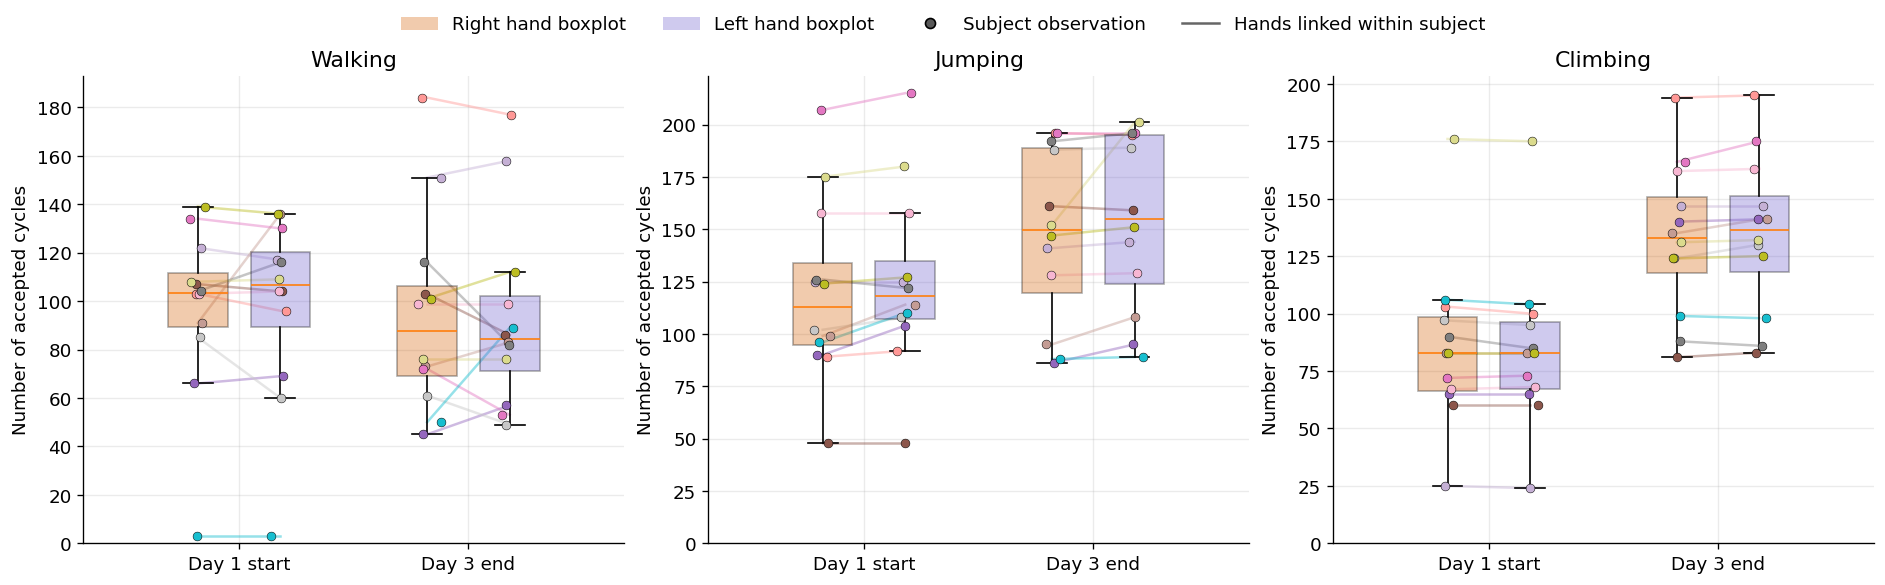

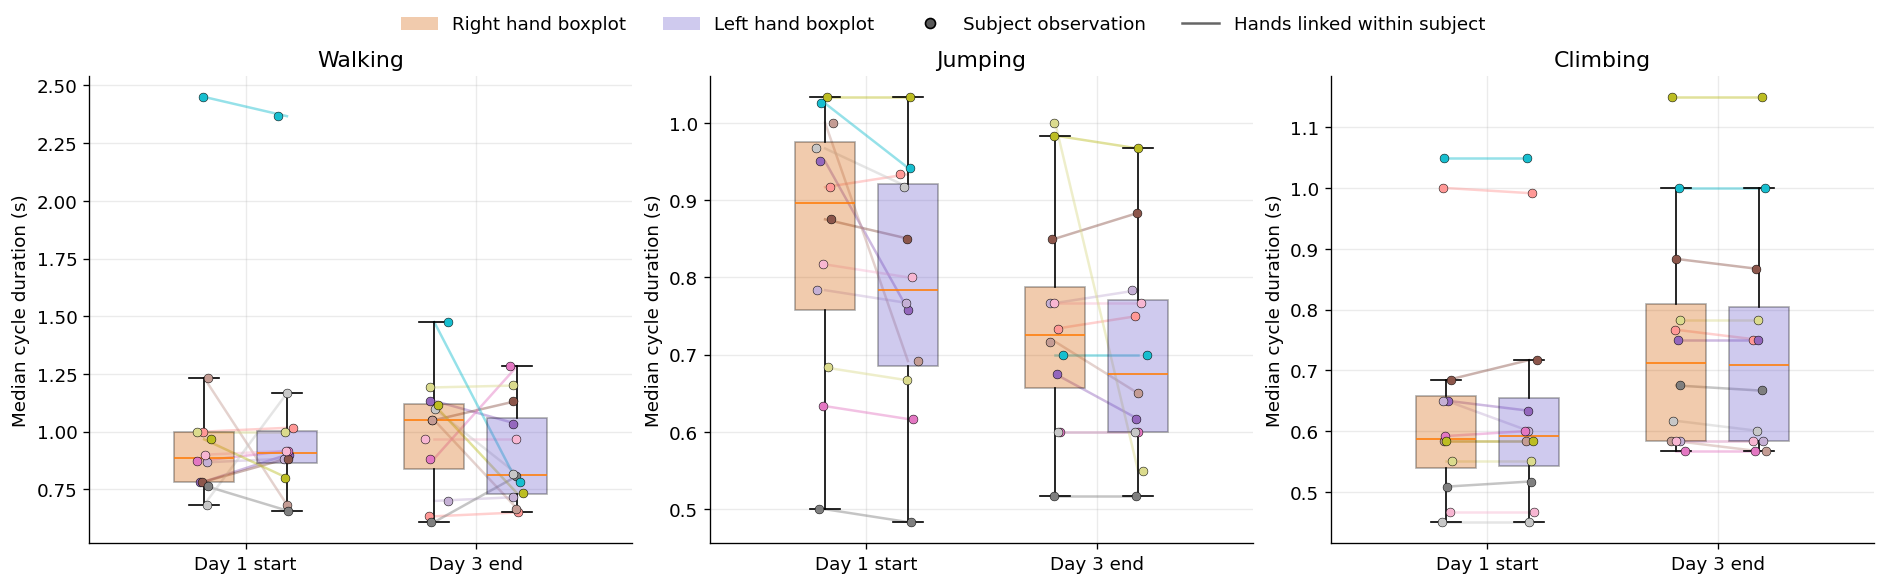

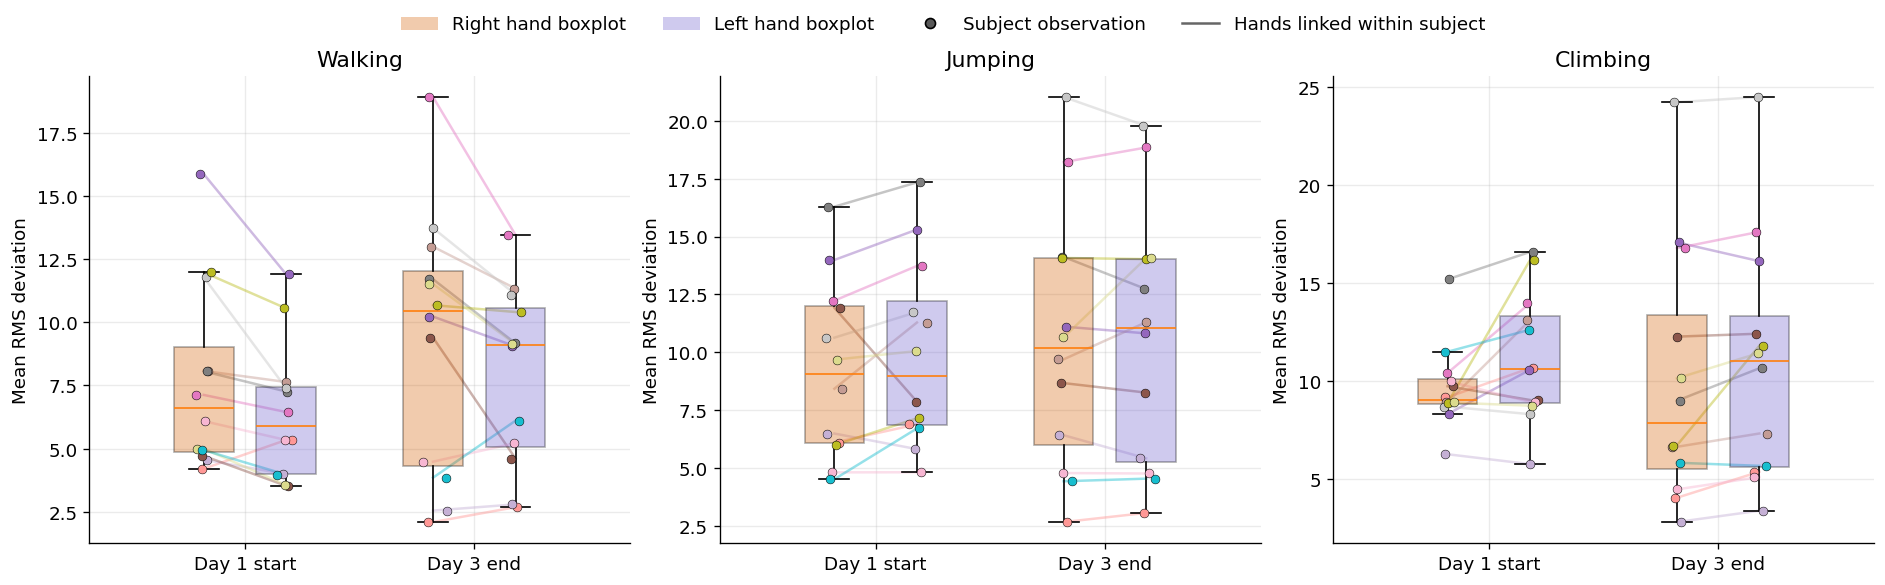

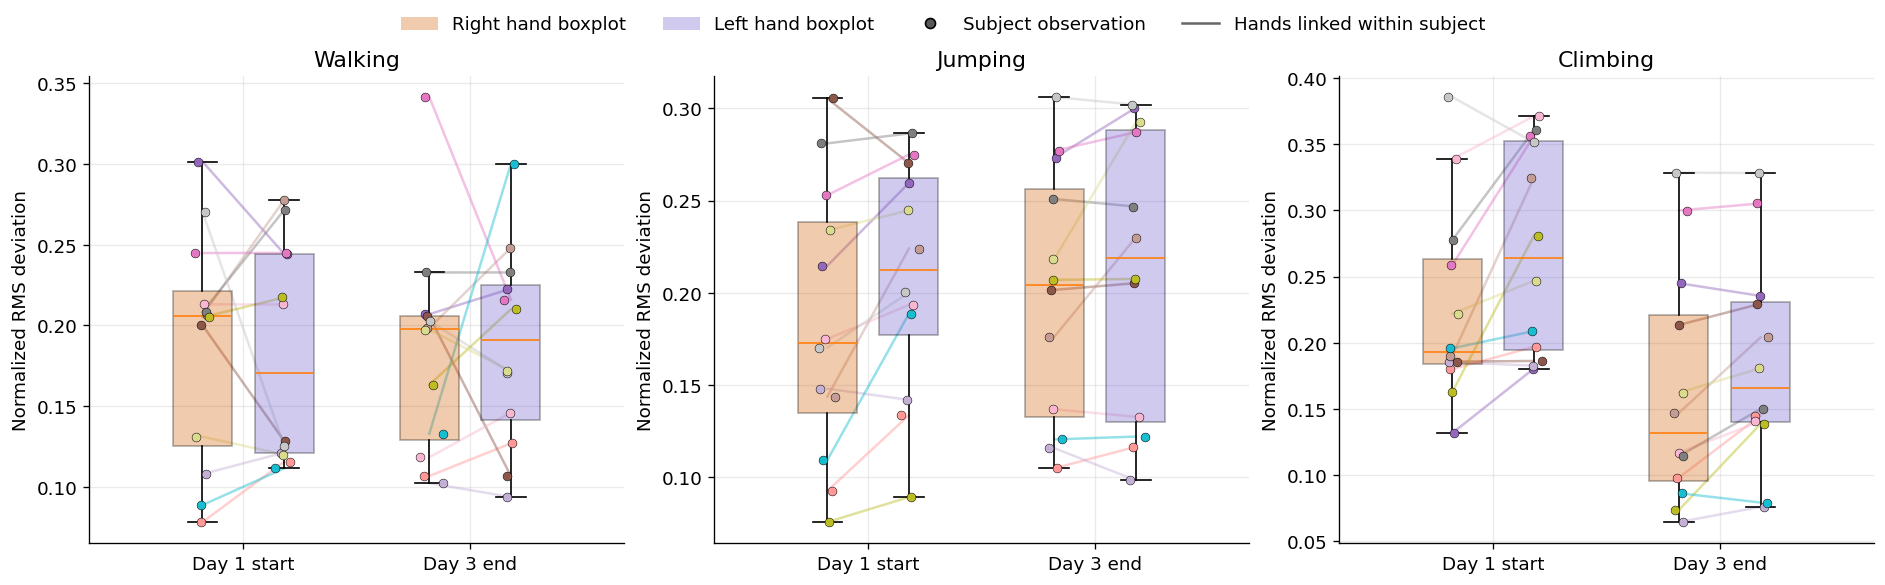

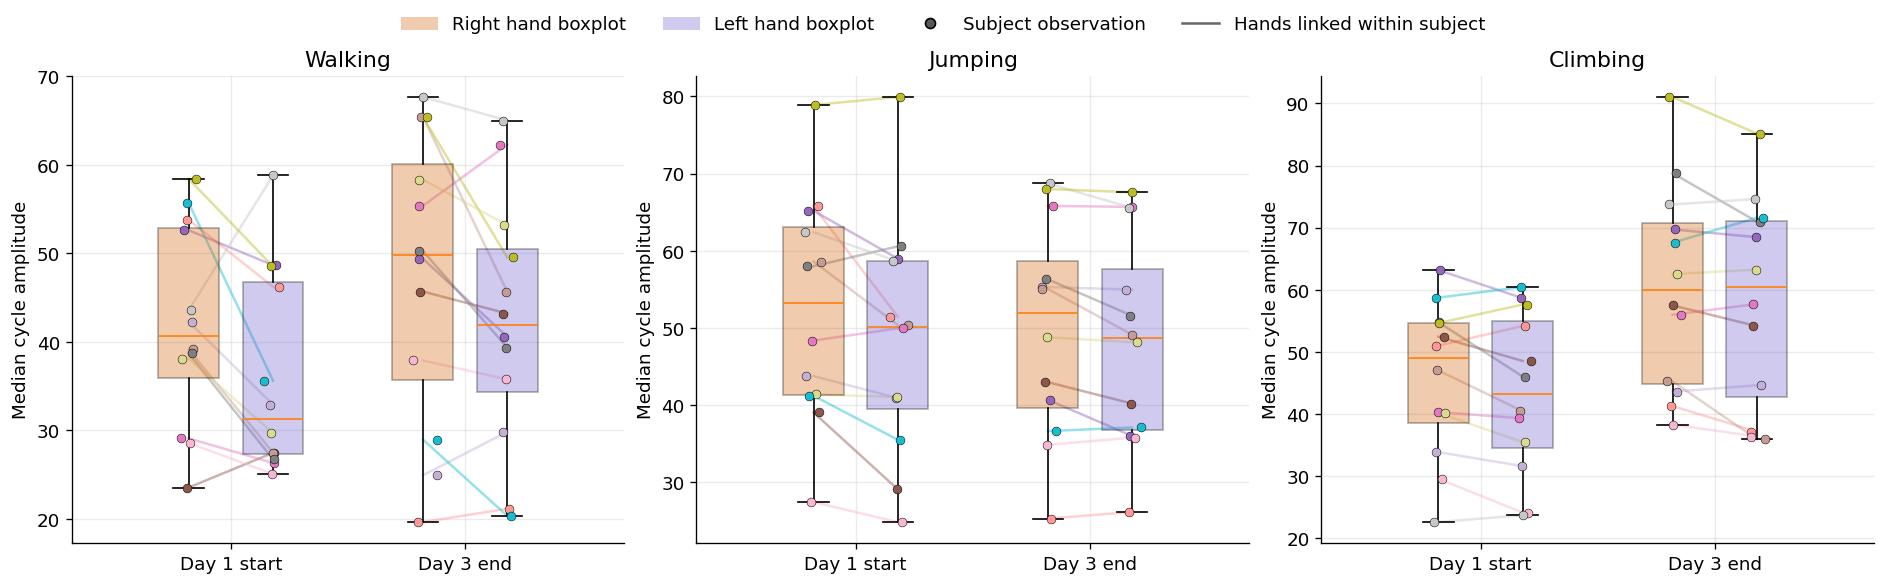

In [25]:
CYCLE_METRIC_LABELS = {
    "n_cycles": "Number of accepted cycles", "median_duration_sec": "Median cycle duration (s)",
    "mean_rms_deviation": "Mean RMS deviation", "normalized_rms_deviation": "Normalized RMS deviation",
    "median_amplitude": "Median cycle amplitude",
}


def selected_cycle_summary(summary):
    return summary[summary.apply(lambda row: (int(row.day), normalize_part_code(row.part)) in {(1,"s"),(3,"e")}, axis=1)].copy()


def cycle_metric_equal_limits(metric, *series):
    if metric != "n_cycles": return equal_limits(*series)
    values = np.concatenate([np.asarray(value, dtype=float).ravel() for value in series])
    values = values[np.isfinite(values)]
    if not len(values): return None
    return 0.0, max(1.0, float(np.ceil(values.max() * 1.08)))


def plot_cycle_metric_distributions(summary, metric):
    frame = selected_cycle_summary(summary); fig, axes = plt.subplots(1, len(SKILLS), figsize=(5.2*len(SKILLS), 4.8), constrained_layout=True)
    rng = np.random.default_rng(RANDOM_SEED)
    for ax, skill in zip(axes, SKILLS):
        skill_df = frame[frame.skill == skill]; positions=[]; data=[]; colors=[]
        for day_index, day in enumerate(DAYS):
            for hand_index, hand in enumerate(HANDS):
                condition = skill_df[(skill_df.day == day) & (skill_df.hand == hand)]; position = day_index + 1 + (-0.18 if hand_index == 0 else 0.18)
                positions.append(position); data.append(condition[metric].dropna()); colors.append(HAND_COLORS[hand])
                for row in condition.dropna(subset=[metric]).itertuples():
                    ax.scatter(position + rng.normal(0,0.018), getattr(row, metric), color=get_subject_color(row.subject), s=28, edgecolor="black", linewidth=0.3, zorder=3)
            for subject, subject_df in skill_df[skill_df.day == day].groupby("subject"):
                hand_values = subject_df.set_index("hand")[metric]
                if all(hand in hand_values for hand in HANDS): ax.plot([day_index+0.82, day_index+1.18], [hand_values[HANDS[0]], hand_values[HANDS[1]]], color=get_subject_color(subject), alpha=0.45)
        box = ax.boxplot(data, positions=positions, widths=0.26, patch_artist=True, showfliers=False)
        for patch,color in zip(box["boxes"], colors): patch.set_facecolor(color); patch.set_alpha(0.32)
        ax.set_xticks([1,2], ["Day 1 start","Day 3 end"]); ax.set(title=SKILL_LABELS[skill], ylabel=CYCLE_METRIC_LABELS[metric])
        if metric == "n_cycles": ax.yaxis.set_major_locator(MaxNLocator(integer=True)); ax.set_ylim(bottom=0)
    handles = [Patch(facecolor=HAND_COLORS[hand], alpha=0.32, label=f"{HAND_LABELS[hand]} boxplot") for hand in HANDS]
    handles += [
        Line2D([0], [0], color="none", marker="o", markerfacecolor="0.35", markeredgecolor="black",
               label="Subject observation"),
        Line2D([0], [0], color="black", alpha=0.6, label="Hands linked within subject"),
    ]
    fig.legend(handles=handles, loc="outside upper center", ncol=4, frameon=False)
    saved = save_figure(fig, OUTPUT_DIRS["cycles"]["report"], f"subject_level_{metric}_distributions")
    plot_path = OUTPUT_DIRS["cycles"]["tables"] / f"{ANALYSIS_VERSION}_{metric}_distribution_plot_data.csv"; frame[["subject","skill","day","part","hand",metric]].to_csv(plot_path,index=False)
    return fig, frame, saved


cycle_metric_distribution_outputs = {}
for cycle_metric in CYCLE_METRIC_LABELS:
    figure, plot_frame, saved_paths = plot_cycle_metric_distributions(subject_cycle_summary_df, cycle_metric); plt.show()
    cycle_metric_distribution_outputs[cycle_metric] = (figure, plot_frame, saved_paths)

In Day 1 versus Day 3 scatterplots, each point is one subject × hand: subject identity is color and hand is marker. The X=Y line means no change; X/Y limits are equal. Lines joining the two hands use the same subject color. Only complete day pairs are displayed. In right-versus-left plots, color is again subject and marker/fill represents day; lines join Day 1 and Day 3 for that subject.

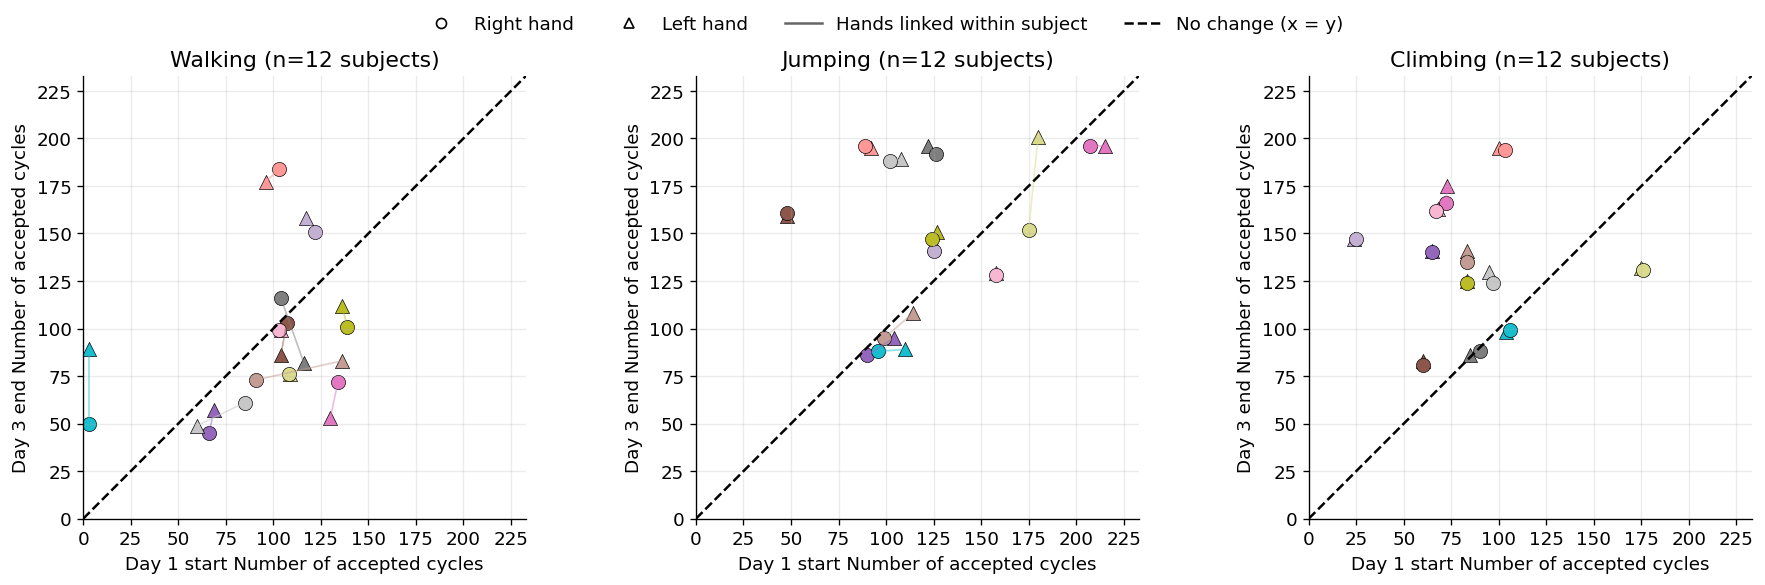

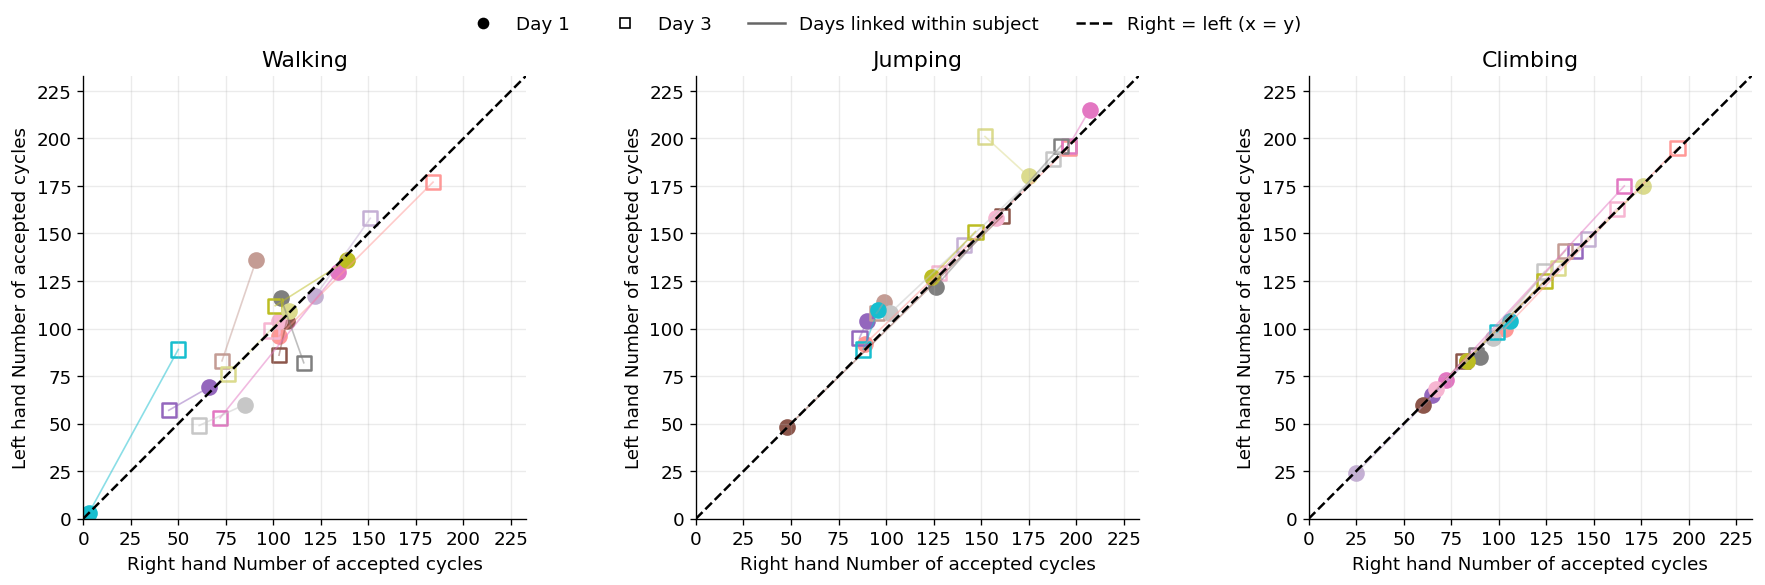

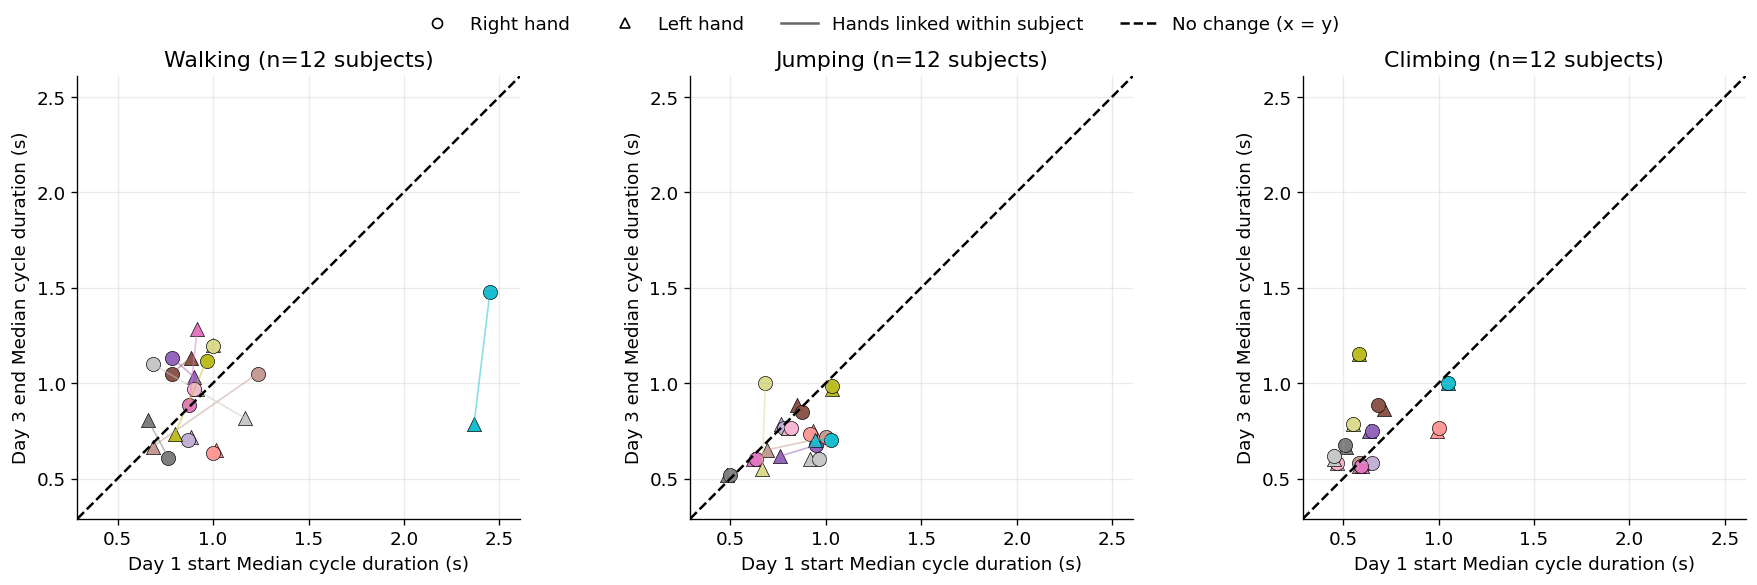

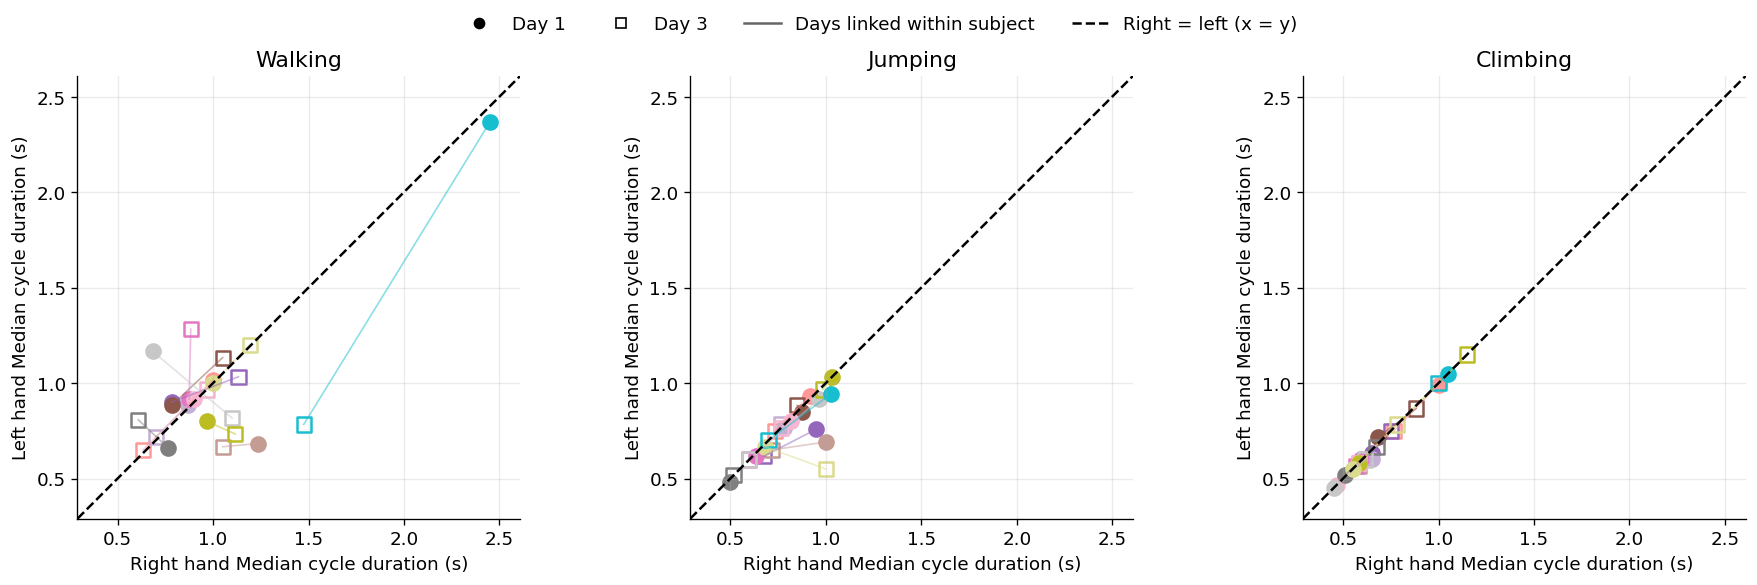

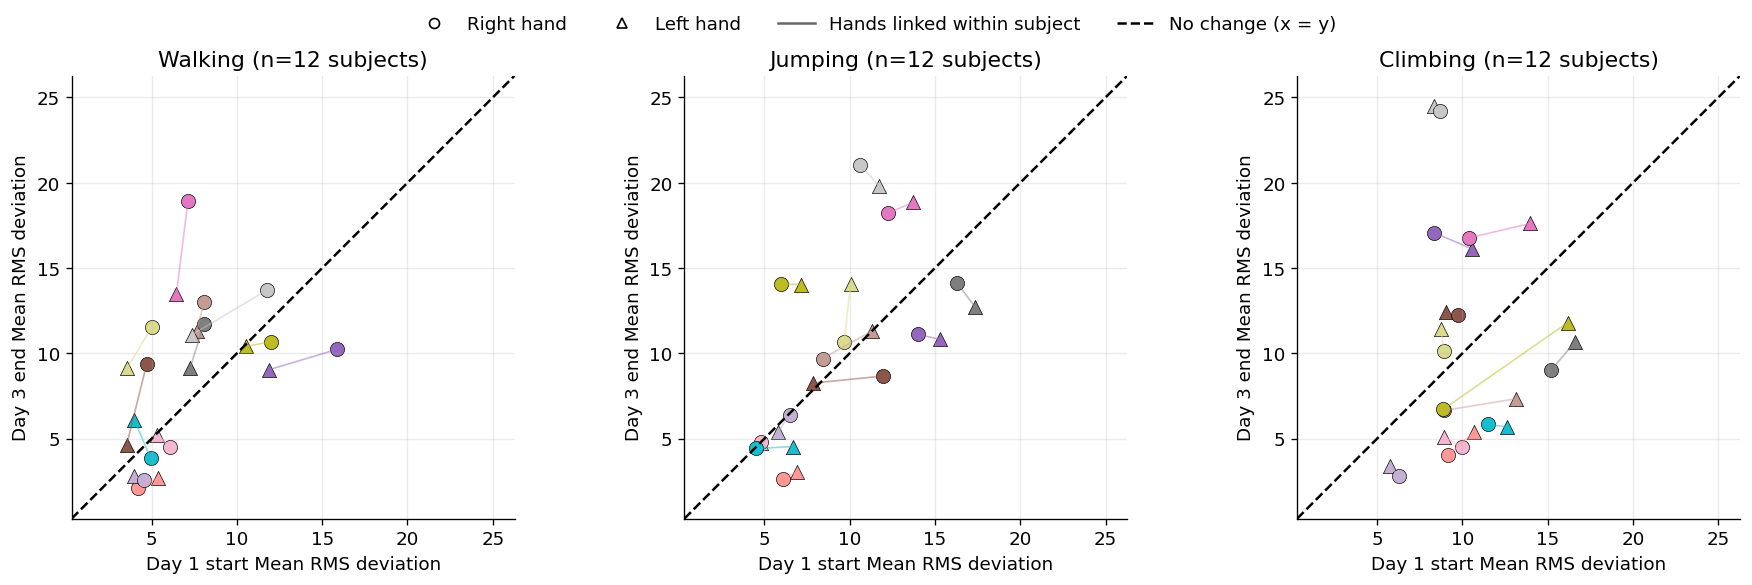

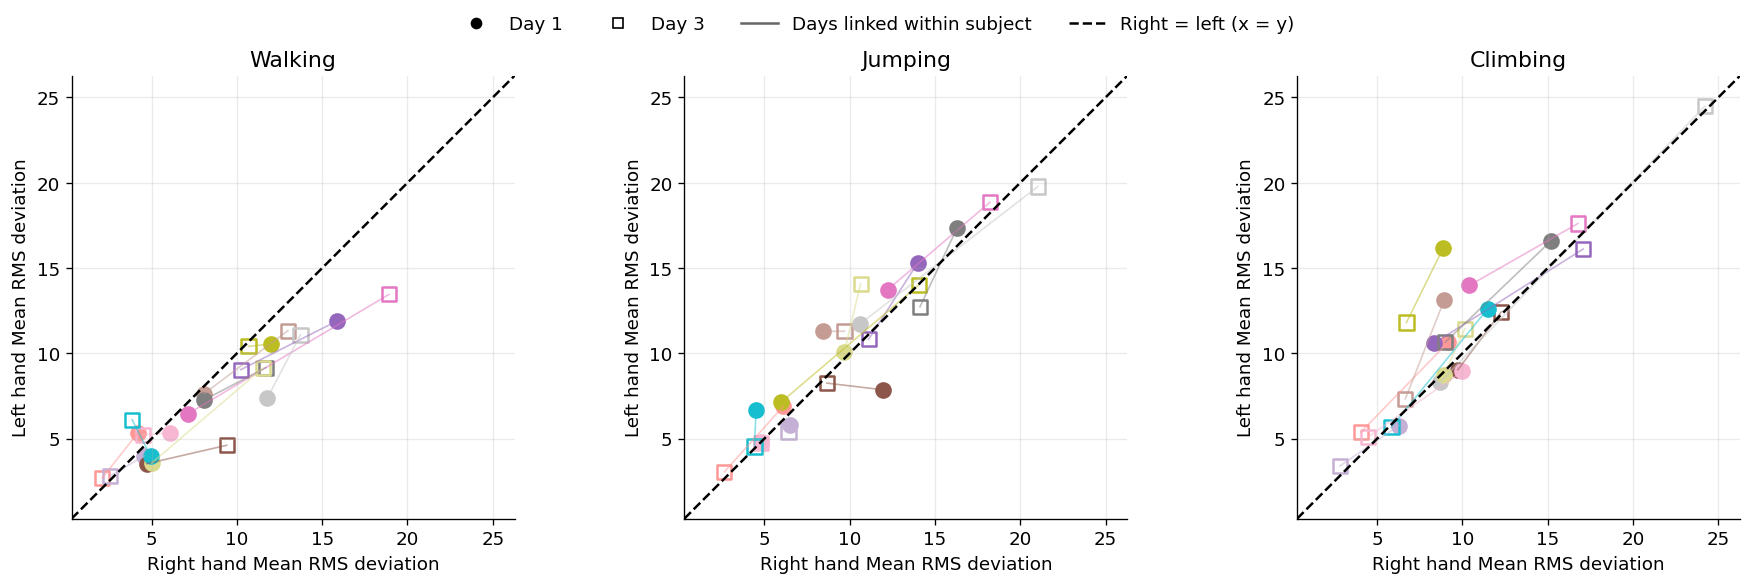

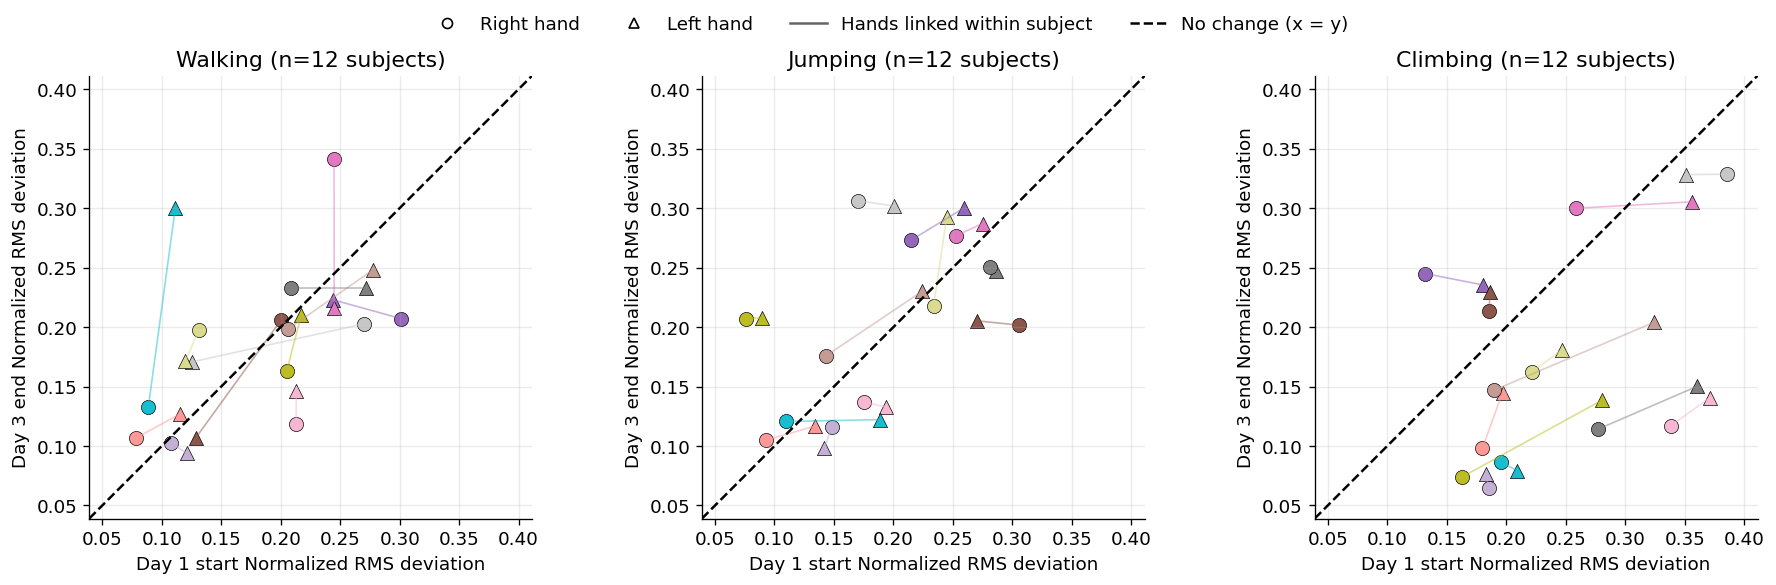

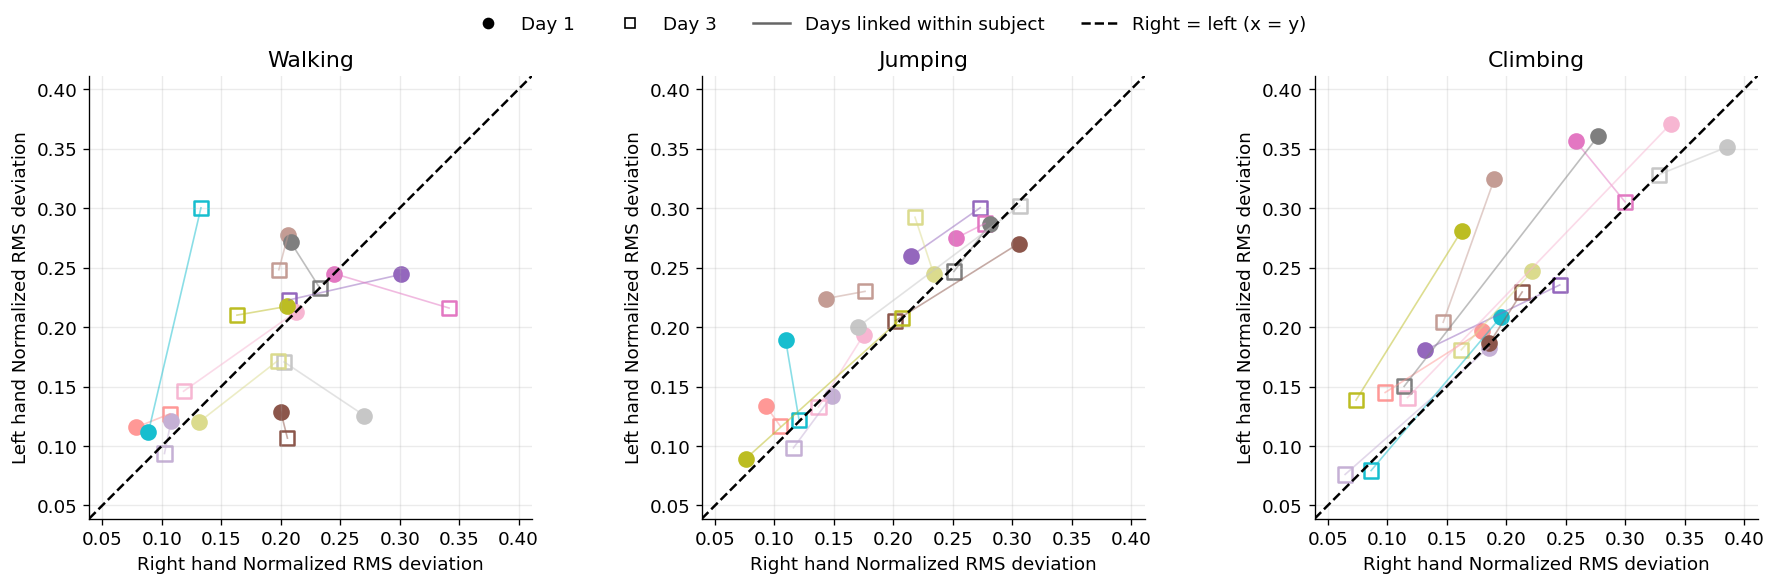

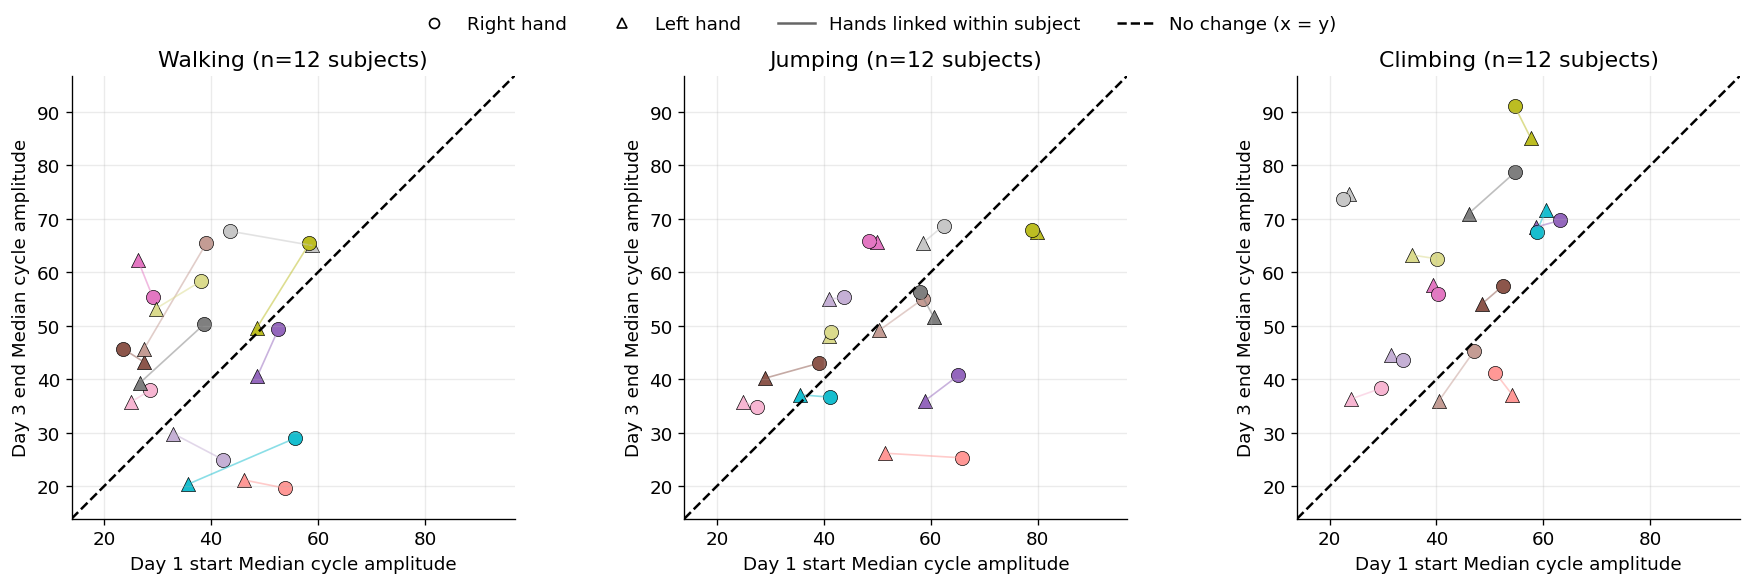

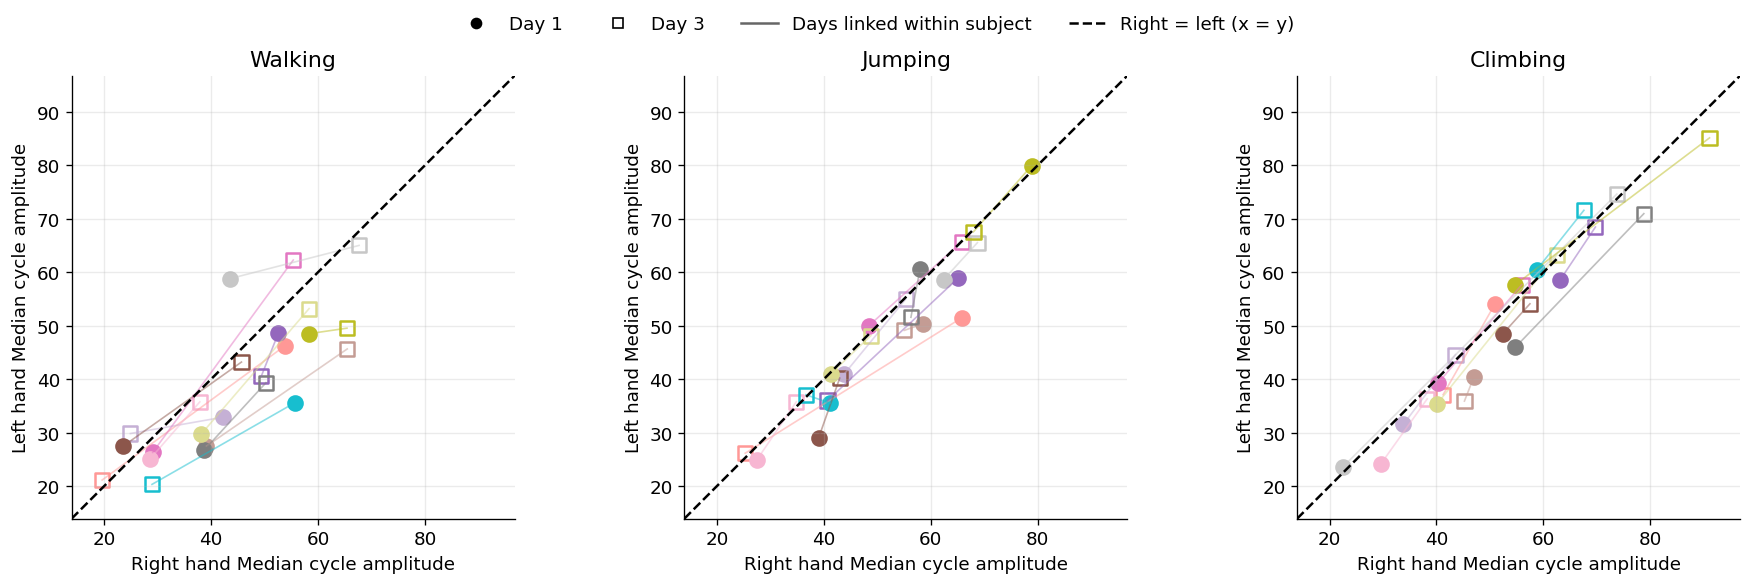

In [26]:
def build_day_paired_metric(summary, metric):
    frame = selected_cycle_summary(summary)
    wide = frame.pivot_table(index=["subject","skill","hand"], columns="day", values=metric, aggfunc="first").reset_index()
    if not set(DAYS).issubset(wide.columns): return pd.DataFrame(), pd.DataFrame()
    wide = wide.rename(columns={1:"day1_value",3:"day3_value"}); incomplete = wide[wide[["day1_value","day3_value"]].isna().any(axis=1)].copy()
    return wide.dropna(subset=["day1_value","day3_value"]), incomplete


def plot_day1_vs_day3_metric(summary, metric):
    paired, incomplete = build_day_paired_metric(summary, metric); limits = cycle_metric_equal_limits(metric, paired.day1_value, paired.day3_value)
    fig, axes = plt.subplots(1,len(SKILLS),figsize=(5.1*len(SKILLS),4.8),constrained_layout=True)
    for ax,skill in zip(axes,SKILLS):
        skill_df=paired[paired.skill==skill]
        for subject,subject_df in skill_df.groupby("subject"):
            color=get_subject_color(subject); ordered=subject_df.set_index("hand").reindex(HANDS).dropna(subset=["day1_value","day3_value"])
            if len(ordered)==2: ax.plot(ordered.day1_value,ordered.day3_value,color=color,alpha=0.5,linewidth=1)
            for row in subject_df.itertuples():
                ax.scatter(row.day1_value,row.day3_value,color=color,marker=HAND_MARKERS[row.hand],s=72,edgecolor="black",linewidth=0.4)
        if limits: ax.plot(limits,limits,"k--"); ax.set_xlim(limits); ax.set_ylim(limits)
        ax.set_aspect("equal",adjustable="box"); ax.set(title=f"{SKILL_LABELS[skill]} (n={skill_df.subject.nunique()} subjects)",xlabel=f"Day 1 start {CYCLE_METRIC_LABELS[metric]}",ylabel=f"Day 3 end {CYCLE_METRIC_LABELS[metric]}")
        if metric == "n_cycles": ax.xaxis.set_major_locator(MaxNLocator(integer=True)); ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    handles = [Line2D([0], [0], color="black", marker=HAND_MARKERS[hand], linestyle="None",
                      markerfacecolor="white", label=HAND_LABELS[hand]) for hand in HANDS]
    handles += [
        Line2D([0], [0], color="black", alpha=0.6, label="Hands linked within subject"),
        Line2D([0], [0], color="black", linestyle="--", label="No change (x = y)"),
    ]
    fig.legend(handles=handles, loc="outside upper center", ncol=4, frameon=False)
    saved=save_figure(fig,OUTPUT_DIRS["cycles"]["report"],f"day1start_vs_day3end_{metric}_scatter")
    paired.to_csv(OUTPUT_DIRS["cycles"]["tables"] / f"{ANALYSIS_VERSION}_paired_{metric}_day1_day3.csv",index=False)
    incomplete.to_csv(OUTPUT_DIRS["cycles"]["tables"] / f"{ANALYSIS_VERSION}_incomplete_{metric}_day_pairs.csv",index=False)
    return paired,fig,saved


def plot_right_vs_left_metric(summary, metric):
    frame=selected_cycle_summary(summary); wide=frame.pivot_table(index=["subject","skill","day"],columns="hand",values=metric,aggfunc="first").reset_index().dropna(subset=HANDS)
    limits=cycle_metric_equal_limits(metric,wide.r_hand,wide.l_hand); fig,axes=plt.subplots(1,len(SKILLS),figsize=(5.1*len(SKILLS),4.8),constrained_layout=True)
    for ax,skill in zip(axes,SKILLS):
        skill_df=wide[wide.skill==skill]
        for subject,subject_df in skill_df.groupby("subject"):
            color=get_subject_color(subject); ordered=subject_df.set_index("day").reindex(DAYS).dropna(subset=HANDS)
            if len(ordered)==2: ax.plot(ordered.r_hand,ordered.l_hand,color=color,alpha=0.5,linewidth=1)
            for row in subject_df.itertuples(): ax.scatter(row.r_hand,row.l_hand,marker=DAY_MARKERS[int(row.day)],s=72,facecolors=color if int(row.day)==1 else "none",edgecolors=color,linewidth=1.5)
        if limits: ax.plot(limits,limits,"k--"); ax.set_xlim(limits); ax.set_ylim(limits)
        ax.set_aspect("equal",adjustable="box"); ax.set(title=SKILL_LABELS[skill],xlabel=f"Right hand {CYCLE_METRIC_LABELS[metric]}",ylabel=f"Left hand {CYCLE_METRIC_LABELS[metric]}")
        if metric == "n_cycles": ax.xaxis.set_major_locator(MaxNLocator(integer=True)); ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    handles = [
        Line2D([0], [0], color="black", marker=DAY_MARKERS[1], linestyle="None", markerfacecolor="black", label=DAY_LABELS[1]),
        Line2D([0], [0], color="black", marker=DAY_MARKERS[3], linestyle="None", markerfacecolor="white", label=DAY_LABELS[3]),
        Line2D([0], [0], color="black", alpha=0.6, label="Days linked within subject"),
        Line2D([0], [0], color="black", linestyle="--", label="Right = left (x = y)"),
    ]
    fig.legend(handles=handles, loc="outside upper center", ncol=4, frameon=False)
    saved=save_figure(fig,OUTPUT_DIRS["cycles"]["report"],f"right_vs_left_{metric}_scatter")
    wide.to_csv(OUTPUT_DIRS["cycles"]["tables"] / f"{ANALYSIS_VERSION}_paired_hands_{metric}.csv",index=False)
    return wide,fig,saved


cycle_day_scatter_outputs={}; cycle_hand_scatter_outputs={}
for cycle_metric in CYCLE_METRIC_LABELS:
    paired,figure,saved=plot_day1_vs_day3_metric(subject_cycle_summary_df,cycle_metric); plt.show(); cycle_day_scatter_outputs[cycle_metric]=(paired,figure,saved)
    paired_hands,figure,saved=plot_right_vs_left_metric(subject_cycle_summary_df,cycle_metric); plt.show(); cycle_hand_scatter_outputs[cycle_metric]=(paired_hands,figure,saved)

The trajectory-overlay figures show merged movement runs plus mean 3D hand cycles reconstructed from the accepted cycle boundaries. The configured single subject uses its stable subject color for run trajectories; right/left overlays use distinct marker/line styles. Top-down uses X–Z and 3D uses X–Z–Y.

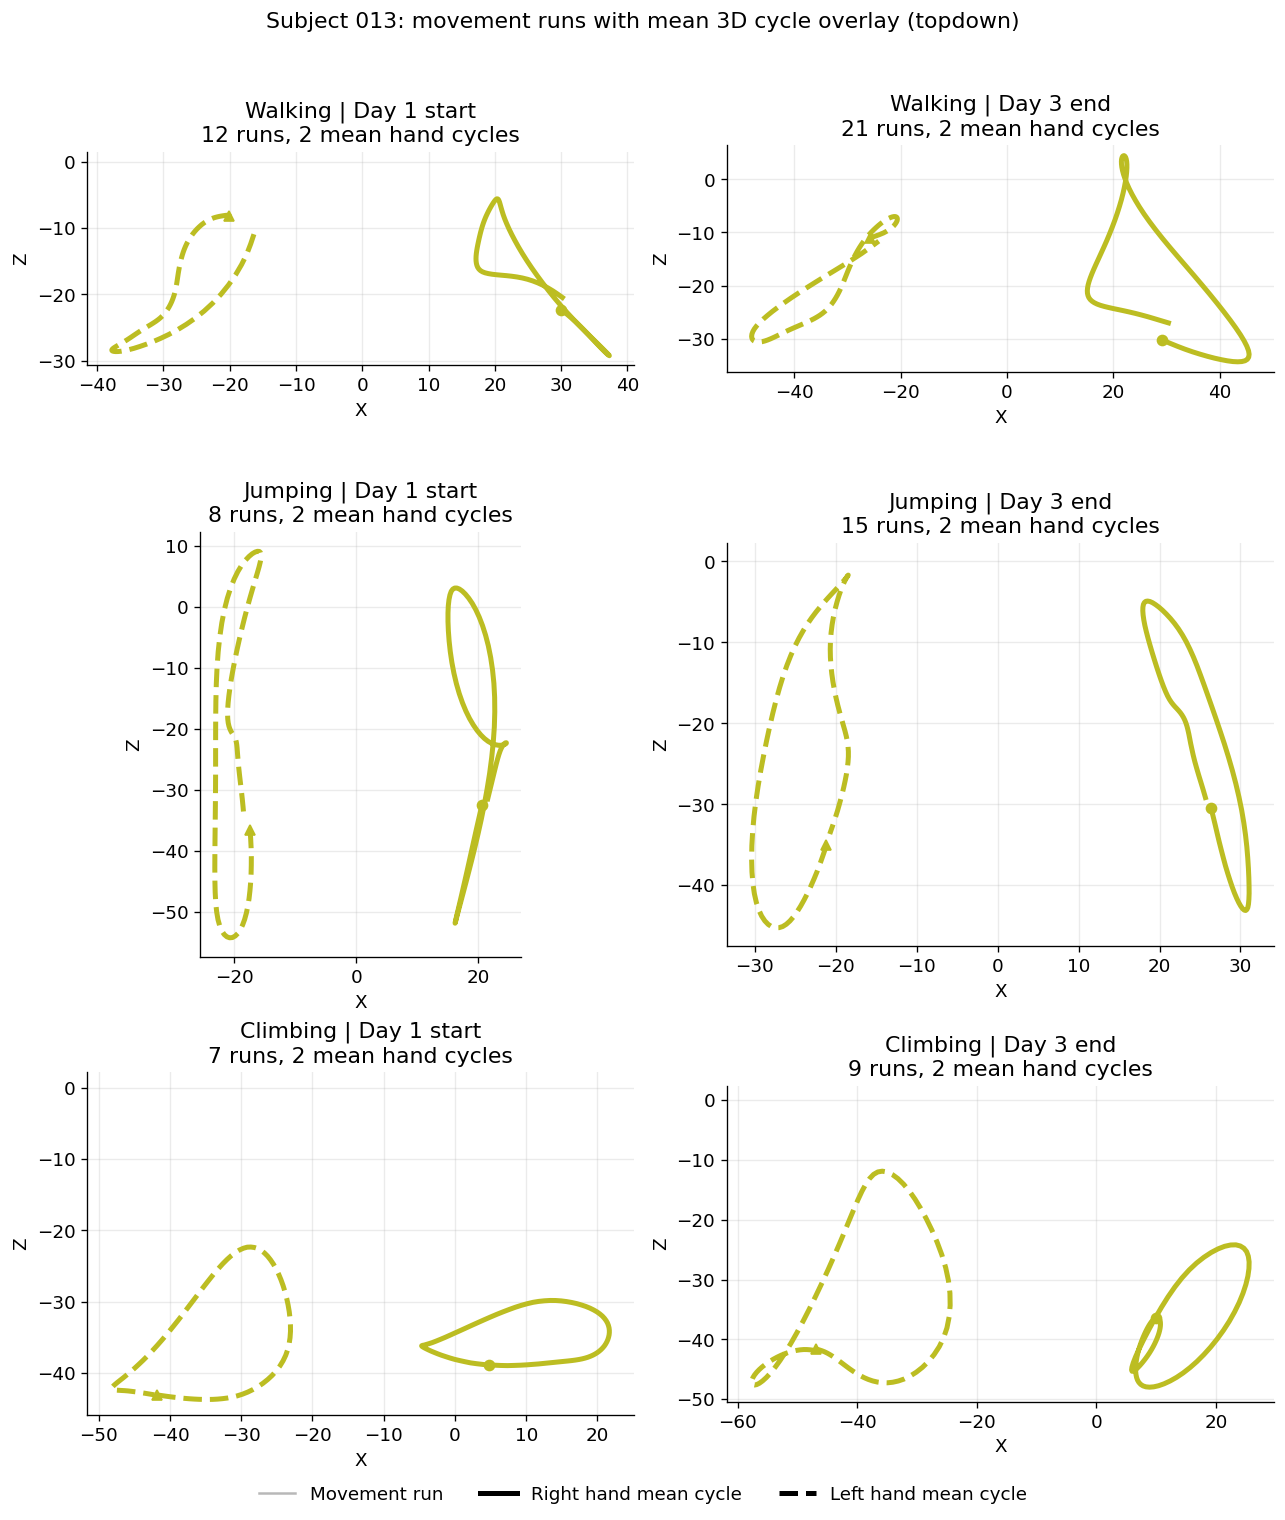

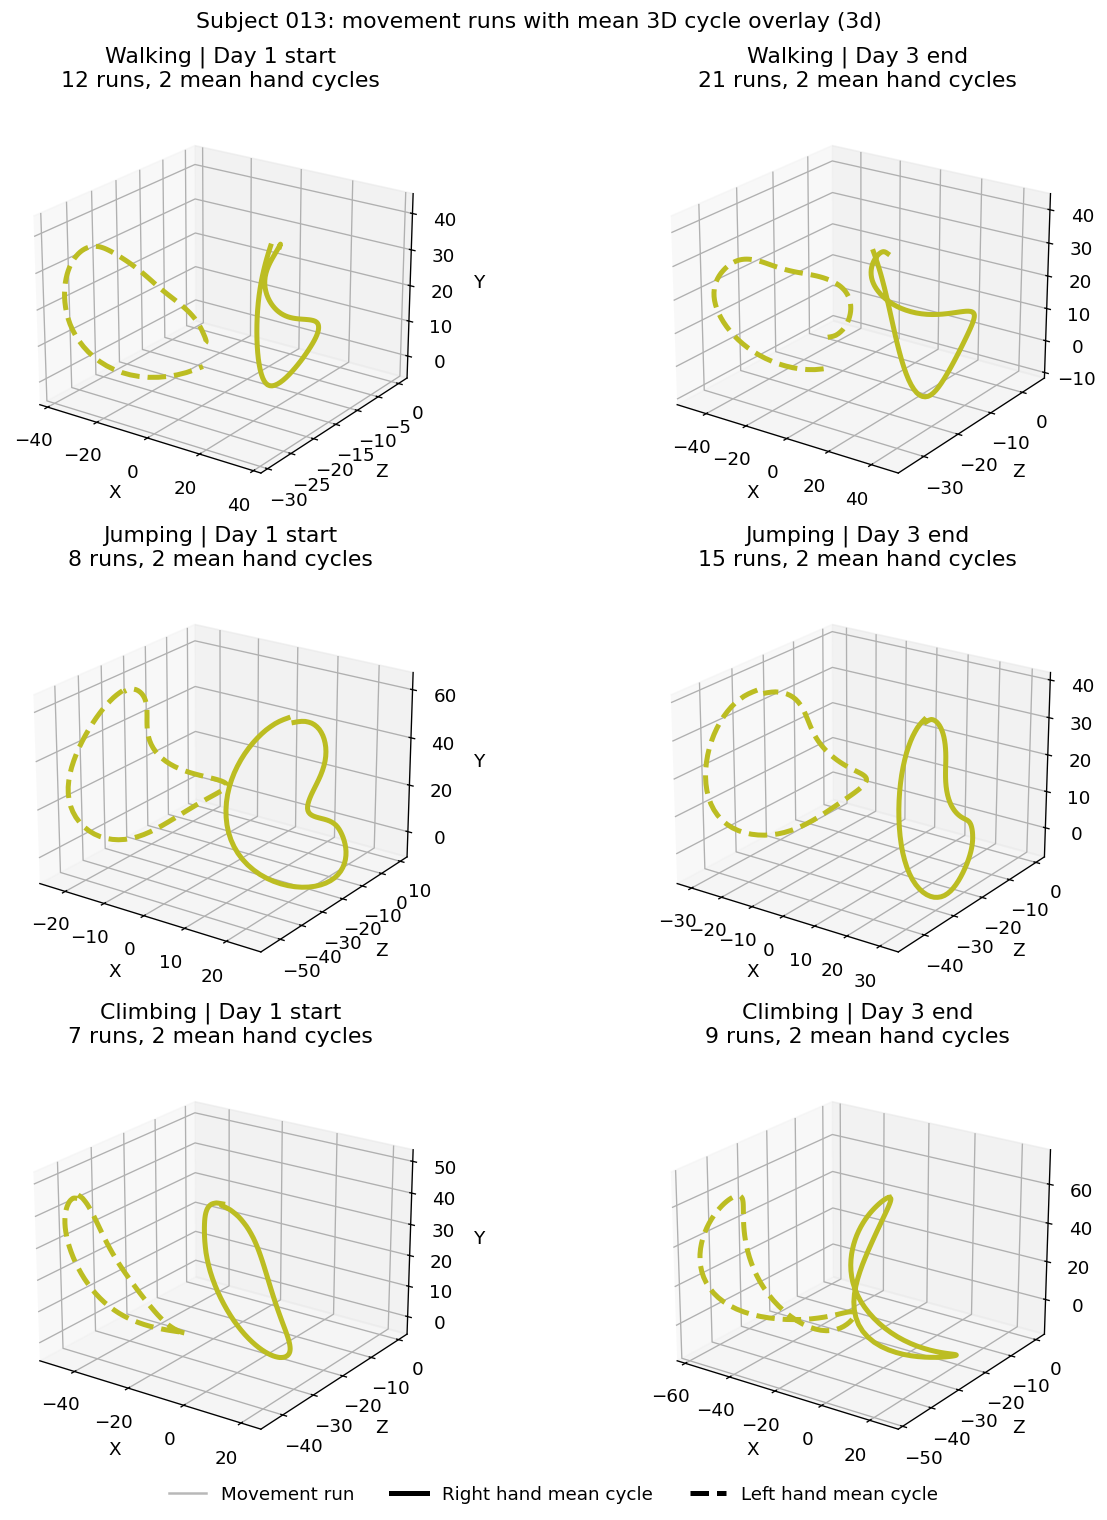

In [27]:
def mean_3d_cycle(cycles, subject, skill, day, part, hand, root_relative, n_points=100):
    condition=cycles[(cycles.subject.astype(str)==normalize_repetitive_subject(subject))&(cycles.skill==skill)&(cycles.day==day)&(cycles.part.map(normalize_part_code)==normalize_part_code(part))&(cycles.hand==hand)]
    arrays=[]; file_cache={}
    for row in condition.itertuples():
        frame=load_position_file(row.path,file_cache).iloc[row.start_idx_in_file:row.end_idx_in_file+1]
        needed=[f"{hand}.{axis}" for axis in "xyz"]+[f"root.{axis}" for axis in "xyz"]
        if any(column not in frame for column in needed): continue
        hand_xyz=frame[[f"{hand}.{axis}" for axis in "xyz"]].apply(pd.to_numeric,errors="coerce").to_numpy()
        root_xyz=frame[[f"root.{axis}" for axis in "xyz"]].apply(pd.to_numeric,errors="coerce").to_numpy()
        xyz=hand_xyz-root_xyz if root_relative else hand_xyz
        if not np.isfinite(xyz).all() or len(xyz)<2: continue
        arrays.append(np.column_stack([np.interp(np.linspace(0,1,n_points),np.linspace(0,1,len(xyz)),xyz[:,axis]) for axis in range(3)]))
    return None if len(arrays)<2 else np.mean(np.stack(arrays),axis=0)


def plot_cycle_trajectory_overlay(runs,cycles,subject="002",view="topdown",root_relative=False):
    subject=normalize_repetitive_subject(subject); color=get_subject_color(subject); day_items=list(DAY_PART_FOR_FINAL.items())
    if view=="3d": fig=plt.figure(figsize=(5.3*len(day_items),4.1*len(SKILLS)),constrained_layout=True); axes=np.empty((len(SKILLS),len(day_items)),object)
    else: fig,axes=plt.subplots(len(SKILLS),len(day_items),figsize=(5.3*len(day_items),4.1*len(SKILLS)),squeeze=False,constrained_layout=True)
    plot_rows=[]; file_cache={}
    for i,skill in enumerate(SKILLS):
        for j,(day,part) in enumerate(day_items):
            ax=fig.add_subplot(len(SKILLS),len(day_items),i*len(day_items)+j+1,projection="3d") if view=="3d" else axes[i,j]
            if view=="3d": axes[i,j]=ax
            condition=runs[(runs.subject.astype(str)==subject)&(runs.skill==skill)&(runs.day==day)&(runs.part.map(normalize_part_code)==normalize_part_code(part))]
            for run in condition.itertuples():
                frame=load_position_file(run.path,file_cache).iloc[run.run_start:run.run_end]
                if view=="topdown": ax.plot(frame["root.x"],frame["root.z"],color=color,alpha=0.18)
                else: ax.plot(frame["root.x"],frame["root.z"],frame["root.y"],color=color,alpha=0.18)
            overlays=0
            for hand,style in zip(HANDS,["-","--"]):
                mean=mean_3d_cycle(cycles,subject,skill,day,part,hand,root_relative)
                if mean is None: continue
                if view=="topdown": ax.plot(mean[:,0],mean[:,2],color=color,linestyle=style,linewidth=3,marker=HAND_MARKERS[hand],markevery=[0])
                else: ax.plot(mean[:,0],mean[:,2],mean[:,1],color=color,linestyle=style,linewidth=3)
                overlays+=1
            ax.set(title=f"{SKILL_LABELS[skill]} | Day {day} {PART_LABELS[part]}\n{len(condition)} runs, {overlays} mean hand cycles",xlabel="X",ylabel="Z")
            if view=="topdown": ax.set_aspect("equal",adjustable="box")
            else: ax.set_zlabel("Y"); ax.view_init(elev=22,azim=-55)
            plot_rows.append({"subject":subject,"skill":skill,"day":day,"part":part,"view":view,"n_runs":len(condition),"n_overlays":overlays})
    handles = [Line2D([0], [0], color="0.45", alpha=0.5, label="Movement run")]
    handles += [Line2D([0], [0], color="black", linestyle=style, linewidth=3, label=f"{HAND_LABELS[hand]} mean cycle")
                for hand, style in zip(HANDS, ["-", "--"])]
    fig.legend(handles=handles, loc="outside lower center", ncol=3, frameon=False)
    fig.suptitle(f"Subject {subject}: movement runs with mean 3D cycle overlay ({view})",y=1.02)
    saved=save_figure(fig,OUTPUT_DIRS["cycles"]["report"],f"subject_{subject}_movement_runs_mean_3d_cycle_{view}")
    return pd.DataFrame(plot_rows),fig,saved


cycle_overlay_topdown_df,cycle_overlay_topdown_fig,cycle_overlay_topdown_paths=plot_cycle_trajectory_overlay(runs_df,cycles_df,"013","topdown",False); plt.show()
cycle_overlay_3d_df,cycle_overlay_3d_fig,cycle_overlay_3d_paths=plot_cycle_trajectory_overlay(runs_df,cycles_df,"013","3d",True); plt.show()

### Optional examples

In [28]:
# Expensive/high-volume optional example: create one mean-cycle figure per configured subject.
RUN_ALL_SUBJECT_CYCLE_FIGURES = False
if RUN_ALL_SUBJECT_CYCLE_FIGURES:
    for subject in REPETITIVE_SUBJECTS:
        figure, _, _ = plot_single_subject_cycles(subject_mean_cycles_df, subject)
        plt.close(figure)

### Saved outputs

In [29]:
print("Cycle outputs:")
for key,value in OUTPUT_DIRS["cycles"].items(): print(f"  {key}: {value}")

Cycle outputs:
  root: D:\noamgonen\GitHub\gorilla_tag_\img\labeled_data_analysis\cycles
  cache: D:\noamgonen\GitHub\gorilla_tag_\img\labeled_data_analysis\cycles\cache
  tables: D:\noamgonen\GitHub\gorilla_tag_\img\labeled_data_analysis\cycles\tables
  qc: D:\noamgonen\GitHub\gorilla_tag_\img\labeled_data_analysis\cycles\figures\qc
  report: D:\noamgonen\GitHub\gorilla_tag_\img\labeled_data_analysis\cycles\figures\report


## 6. Optional covariance analysis

### Purpose, data, and comparison

The source measures notebook contained disabled covariance code. It remains disabled by default (`RUN_OPTIONAL_COVARIANCE = False`). If enabled, this independent analysis loads its own aligned frames, z-scores features within each group × day × skill combination, computes feature covariance, and saves its own cache/tables/QC/report figures. It does not use PCA variables.

### Parameters

In [30]:
COVARIANCE_PARAMS = {
    "features": tuple(f"{point}.{axis}" for point in ["torso_2","torso_6","l_shoulder","r_shoulder","l_up_arm","r_up_arm","l_hand","r_hand"] for axis in "xyz"),
    "groups": ("free","repetitive"), "days": tuple(DAYS), "skills": tuple(SKILLS), "enabled": RUN_OPTIONAL_COVARIANCE,
}
COVARIANCE_PARAMS

{'features': ('torso_2.x',
  'torso_2.y',
  'torso_2.z',
  'torso_6.x',
  'torso_6.y',
  'torso_6.z',
  'l_shoulder.x',
  'l_shoulder.y',
  'l_shoulder.z',
  'r_shoulder.x',
  'r_shoulder.y',
  'r_shoulder.z',
  'l_up_arm.x',
  'l_up_arm.y',
  'l_up_arm.z',
  'r_up_arm.x',
  'r_up_arm.y',
  'r_up_arm.z',
  'l_hand.x',
  'l_hand.y',
  'l_hand.z',
  'r_hand.x',
  'r_hand.y',
  'r_hand.z'),
 'groups': ('free', 'repetitive'),
 'days': (1, 3),
 'skills': ('walk', 'jump', 'climb'),
 'enabled': False}

### Load or compute results

In [31]:
def collect_covariance_matrix(label_df, group, skill, day, features):
    """Load this optional analysis's own pooled frame matrix and diagnostics."""
    selected = label_df[(label_df.skill == skill) & (label_df.day.astype(int) == int(day))]
    pieces, contributions, skipped = [], [], []
    file_cache = {}
    for _, row in selected.iterrows():
        segment, diagnostic = load_segment(group, row, columns=features, file_cache=file_cache)
        if segment is None:
            skipped.append(diagnostic); continue
        numeric = segment.apply(pd.to_numeric, errors="coerce")
        finite = np.isfinite(numeric.to_numpy(float)).all(axis=1)
        contributions.append({"group": group, "subject": row.subject_str, "day": day, "skill": skill,
                              "valid_frames": int(finite.sum()), "non_finite_rows_removed": int((~finite).sum())})
        if finite.any(): pieces.append(numeric.loc[finite, features])
    return (pd.concat(pieces, ignore_index=True) if pieces else None,
            pd.DataFrame(contributions), pd.DataFrame(skipped))


def compute_covariance_analysis(free_df,repetitive_df,parameters):
    labels={"free":free_df,"repetitive":repetitive_df}; results={}; qc=[]; skipped=[]
    for group in parameters["groups"]:
        for day in parameters["days"]:
            for skill in parameters["skills"]:
                matrix,contribution,skipped_rows=collect_covariance_matrix(labels[group],group,skill,day,list(parameters["features"]))
                if len(skipped_rows): skipped.append(skipped_rows)
                key=f"{group}__day{day}__{skill}"
                if matrix is None or len(matrix)<2: qc.append({"group":group,"day":day,"skill":skill,"status":"missing"}); continue
                values=matrix.to_numpy(float); sd=values.std(axis=0); sd[sd==0]=1; z=(values-values.mean(axis=0))/sd
                results[key]=np.cov(z,rowvar=False); qc.append({"group":group,"day":day,"skill":skill,"status":"ok","n_frames":len(matrix),"n_features":matrix.shape[1]})
    return results,pd.DataFrame(qc),pd.concat(skipped,ignore_index=True) if skipped else pd.DataFrame()


def load_or_build_covariance(free_df,repetitive_df,parameters=None):
    parameters = COVARIANCE_PARAMS if parameters is None else parameters
    out=OUTPUT_DIRS["covariance"]; cache=out["cache"] / f"{ANALYSIS_VERSION}_covariance.pkl"; manifest=out["cache"] / f"{ANALYSIS_VERSION}_manifest.json"
    inputs=[FREE_LABELS_PATH,*REPETITIVE_WINDOW_FILES.values(),*referenced_position_paths(free_df,"free"),*referenced_position_paths(repetitive_df,"repetitive")]
    signature,payload=cache_signature("covariance",parameters,inputs)
    if not FORCE_RECOMPUTE["covariance"] and cache.exists() and cache_is_valid(manifest,signature): print(f"Loaded covariance cache: {cache}"); return pd.read_pickle(cache)
    result=compute_covariance_analysis(free_df,repetitive_df,parameters); atomic_pickle_dump(result,cache)
    result[1].to_csv(out["tables"] / f"{ANALYSIS_VERSION}_covariance_qc.csv",index=False); result[2].to_csv(out["tables"] / f"{ANALYSIS_VERSION}_skipped_rows.csv",index=False)
    write_manifest(manifest,"covariance",signature,payload,[cache]); print(f"Computed covariance cache: {cache}"); return result


if RUN_OPTIONAL_COVARIANCE:
    covariance_results,covariance_qc_df,covariance_skipped_df=load_or_build_covariance(free_labeled_df,repetitive_labeled_df)
else:
    print("Optional covariance analysis is disabled; set RUN_OPTIONAL_COVARIANCE = True to run it independently.")

Optional covariance analysis is disabled; set RUN_OPTIONAL_COVARIANCE = True to run it independently.


### Quality-control outputs

In [32]:
if RUN_OPTIONAL_COVARIANCE:
    display(covariance_qc_df)

### Report-ready figures

Each optional heatmap is a z-scored feature covariance matrix for one pooled group × day × skill combination. The difference panel is free minus repetitive. These are pooled-frame descriptive matrices, not paired subject comparisons.

In [33]:
def plot_covariance_results(results,parameters=None):
    parameters = COVARIANCE_PARAMS if parameters is None else parameters
    saved=[]
    for day in parameters["days"]:
        for skill in parameters["skills"]:
            free=results.get(f"free__day{day}__{skill}"); repetitive=results.get(f"repetitive__day{day}__{skill}")
            if free is None or repetitive is None: continue
            fig,axes=plt.subplots(1,3,figsize=(15,4.8),constrained_layout=True)
            for ax,matrix,title in zip(axes,[free,repetitive,free-repetitive],["Free","Repetitive","Free − repetitive"]):
                vmax=np.nanmax(np.abs(matrix)); image=ax.imshow(matrix,cmap="coolwarm",vmin=-vmax,vmax=vmax); ax.set_title(title); fig.colorbar(image,ax=ax,fraction=.046)
            fig.suptitle(f"Aligned-position covariance — {SKILL_LABELS[skill]}, Day {day}")
            saved.extend(save_figure(fig,OUTPUT_DIRS["covariance"]["report"],f"covariance_{skill}_day{day}")); plt.show()
    return saved


if RUN_OPTIONAL_COVARIANCE:
    covariance_report_paths=plot_covariance_results(covariance_results)

### Saved outputs

In [34]:
print("Covariance outputs:")
for key,value in OUTPUT_DIRS["covariance"].items(): print(f"  {key}: {value}")

Covariance outputs:
  root: D:\noamgonen\GitHub\gorilla_tag_\img\labeled_data_analysis\covariance
  cache: D:\noamgonen\GitHub\gorilla_tag_\img\labeled_data_analysis\covariance\cache
  tables: D:\noamgonen\GitHub\gorilla_tag_\img\labeled_data_analysis\covariance\tables
  qc: D:\noamgonen\GitHub\gorilla_tag_\img\labeled_data_analysis\covariance\figures\qc
  report: D:\noamgonen\GitHub\gorilla_tag_\img\labeled_data_analysis\covariance\figures\report


## 7. Saved-output index and run summary

This section inventories existing outputs without depending on any analysis variable. It can be run after any subset of analyses. The JSON summary records configuration, cache flags, input paths, and files currently present.

In [35]:
def build_saved_output_index():
    rows=[]
    for analysis,mapping in OUTPUT_DIRS.items():
        for output_type,directory in mapping.items():
            if output_type=="root": continue
            for path in sorted(directory.rglob("*")):
                if path.is_file(): rows.append({"analysis":analysis,"output_type":output_type,"path":str(path),"filename":path.name,"bytes":path.stat().st_size})
    return pd.DataFrame(rows)


saved_output_index_df=build_saved_output_index()
index_path=ANALYSIS_ROOT / "tables" / f"{ANALYSIS_VERSION}_saved_output_index.csv"; saved_output_index_df.to_csv(index_path,index=False)
run_summary={"analysis_version":ANALYSIS_VERSION,"created_utc":datetime.now(timezone.utc).isoformat(),"project_root":str(PROJECT_ROOT),
             "inputs":{"free_labels":str(FREE_LABELS_PATH),"repetitive_windows":{k:str(v) for k,v in REPETITIVE_WINDOW_FILES.items()}},
             "force_recompute":FORCE_RECOMPUTE,"optional_covariance_enabled":RUN_OPTIONAL_COVARIANCE,
             "output_directories":{analysis:{key:str(value) for key,value in mapping.items()} for analysis,mapping in OUTPUT_DIRS.items()},
             "n_indexed_outputs":len(saved_output_index_df)}
summary_path=ANALYSIS_ROOT / "tables" / f"{ANALYSIS_VERSION}_run_summary.json"; atomic_json(run_summary,summary_path)
display(saved_output_index_df)
print(f"Saved index: {index_path}")
print(f"Saved run summary: {summary_path}")

,analysis,output_type,path,filename,bytes
0,trajectories,cache,D:\noamgonen\GitHub\gorilla_tag_\img\labeled_d...,labeled_data_v2_manifest.json,7005
1,trajectories,cache,D:\noamgonen\GitHub\gorilla_tag_\img\labeled_d...,labeled_data_v2_trajectory_runs.pkl,7704
2,trajectories,tables,D:\noamgonen\GitHub\gorilla_tag_\img\labeled_d...,labeled_data_v2_run_qc.csv,876
3,trajectories,tables,D:\noamgonen\GitHub\gorilla_tag_\img\labeled_d...,labeled_data_v2_runs.csv,11750
4,trajectories,tables,D:\noamgonen\GitHub\gorilla_tag_\img\labeled_d...,labeled_data_v2_skipped_rows.csv,2
...,...,...,...,...,...
126,cycles,report,D:\noamgonen\GitHub\gorilla_tag_\img\labeled_d...,labeled_data_v2_subject_level_median_duration_...,414042
127,cycles,report,D:\noamgonen\GitHub\gorilla_tag_\img\labeled_d...,labeled_data_v2_subject_level_n_cycles_distrib...,46307
128,cycles,report,D:\noamgonen\GitHub\gorilla_tag_\img\labeled_d...,labeled_data_v2_subject_level_n_cycles_distrib...,380148
129,cycles,report,D:\noamgonen\GitHub\gorilla_tag_\img\labeled_d...,labeled_data_v2_subject_level_normalized_rms_d...,46611


Saved index: D:\noamgonen\GitHub\gorilla_tag_\img\labeled_data_analysis\tables\labeled_data_v2_saved_output_index.csv
Saved run summary: D:\noamgonen\GitHub\gorilla_tag_\img\labeled_data_analysis\tables\labeled_data_v2_run_summary.json


### Verification notes

Static acceptance checks should confirm valid notebook JSON, a complete Outline, unique function definitions, no machine-specific paths, section independence, and versioned non-colliding filenames. Runtime checks are intentionally cache-aware: forcing one analysis changes only its own flag and signature. Plot functions consume loaded analytical outputs and return both figure objects and plotting data. Every configured subject is present exactly once in the saved color table, and subject-level plot code calls `get_subject_color()`.

If aligned raw files are unavailable on another machine, setup/input QC still runs and records missing files; analytical builders save explicit skipped-row reasons rather than silently swallowing failures.